## Notebook Description: Análisis de Aditivos Alimenticios y sus Efectos en la Digestibilidad, Producción de Metano y Amonio.

<p align="justify">
Este cuaderno de Colab tiene como objetivo principal evaluar el impacto de diferentes tratamientos experimentales (aditivos alimenticios) en la digestibilidad de la materia seca verdadera (TDDM, por sus siglas en inglés), la intensidad de metano (CH$_4$), la concentración de amonio (NH$_4^+$) y el pH en un sistema de fermentación. Para ello, se carga un conjunto de datos experimental y se preprocessa, ordenando los tratamientos. La metodología central incluye la definición de una función personalizada en R que realiza análisis estadísticos univariados (ANOVA) para cada variable de interés en función del tratamiento. Esta función incorpora pruebas de normalidad (Shapiro-Wilk), homogeneidad de varianzas (Bartlett) y comparaciones múltiples post-hoc (Tukey HSD), además de generar visualizaciones mediante diagramas de caja con indicación de los grupos estadísticamente diferentes. El análisis se estructura en la evaluación de cuatro lotes (batches) experimentales, así como en una comparación específica de los \textasciicurlleft mejores tratamientos\textasciicurlright seleccionados. Los resultados principales incluyen los valores F y p de las pruebas ANOVA, los resultados de las pruebas de supuestos, los grupos de significancia de Tukey y las representaciones gráficas que permiten identificar los efectos significativos de los aditivos en las variables estudiadas. Finalmente, se presentan tablas con los promedios de las variables clave por tratamiento para cada lote, consolidando los hallazgos experimentales.
</p>

### Tratamientos experimentales

Tratamientos experimentales utilizados para evaluar aditivos alimenticios comerciales bajo diferentes estrategias de inclusión del aditivo.

| Grupo | Tto | Sustrato / Aditivo | Forraje (%) | Forraje (mg) | Concentrado (%) | Concentrado (mg) | Aditivo (cantidad o volumen por jeringa) | Comentario |
|---|---|---|---:|---:|---:|---:|---|---|
| **1 - Controles** | T0 | Premezcla balanceado Control | 0 | 0 | 100 | 500 | N/A | Premezcla Balanceado Control sin aditivo |
| **1 - Controles** | T1 | Pasto kikuyo | 100 | 500 | 0 | 0 | N/A | **Forraje solo** – Control |
| **1 - Controles** | T2 | Pasto kikuyo (70%) + Premezcla Balanceado Control (30%) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada 70:30 forraje:concentrado (Control) |
| **2 - Premezcla con el Aditivo** | T3 | Agolin (Premezcla B) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada**. Usar premezcla preparada en el laboratorio: 75 mg de premezcla control balanceada sin aditivo + 75 mg de premezcla con el respectivo aditivo |
| **2 - Premezcla con el Aditivo** | T4 | Bovaer 10 (Premezcla C) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T5 | Fator P (Premezcla D) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T6 | Anavrin (Premezcla E) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T7 | Monotec 200 (Premezcla F) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T8 | Nutreset (Premezcla G) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T9 | Bovaer 10 + Monotec 200 (Premezcla H) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **1× o dosis recomendada** |
| **2 - Premezcla con el Aditivo** | T10 | Agolin (Premezcla B) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×**. Usar premezcla respectiva a cada aditivo, preparada por Grupo Bios |
| **2 - Premezcla con el Aditivo** | T11 | Bovaer 10 (Premezcla C) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T12 | Fator P (Premezcla D) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T13 | Anavrin (Premezcla E) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T14 | Monotec 200 (Premezcla F) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T15 | Nutreset (Premezcla G) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **2 - Premezcla con el Aditivo** | T16 | Bovaer 10 + Monotec 200 (Premezcla H) | 70 | 350 | 30 | 150 | N/A | Dieta mezclada con aditivo a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T17 | Pasto + Premezcla Balanceado Control + Agolin | 70 | 350 | 30 | 150 | 0.03 mg | Premezcla Balanceado Control sin aditivo. Adicionar el aditivo directamente en la jeringa a **1× o dosis recomendada** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T18 | Pasto + Premezcla Balanceado Control + Bovaer 10 | 70 | 350 | 30 | 150 | 0.375 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T19 | Pasto + Premezcla Balanceado Control + Fator P | 70 | 350 | 30 | 150 | 0.150 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T20 | Pasto + Premezcla Balanceado Control + Anavrin | 70 | 350 | 30 | 150 | 0.075 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T21 | Pasto + Premezcla Balanceado Control + Monotec 200 | 70 | 350 | 30 | 150 | 0.080 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T22 | Pasto + Premezcla Balanceado Control + Nutreset | 70 | 350 | 30 | 150 | 0.750 mg | Aditivo directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T23 | Pasto + Premezcla Balanceado Control + Bovaer 10 + Monotec 200 | 70 | 350 | 30 | 150 | 0.375 mg Bovaer + 0.080 mg Monotec | Aditivos directamente en la jeringa a **1×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T24 | Pasto + Premezcla Balanceado Control + TN-A | 70 | 350 | 30 | 150 | 25 µL | Aditivo líquido directamente en la jeringa |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T25 | Pasto + Premezcla Balanceado Control + TN-B | 70 | 350 | 30 | 150 | 10 µL | Aditivo líquido directamente en la jeringa |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T26 | Pasto + Premezcla Balanceado Control + Agolin | 70 | 350 | 30 | 150 | 0.06 mg | Premezcla Balanceado Control sin aditivo. Adicionar el aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T27 | Pasto + Premezcla Balanceado Control + Bovaer 10 | 70 | 350 | 30 | 150 | 0.75 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T28 | Pasto + Premezcla Balanceado Control + Fator P | 70 | 350 | 30 | 150 | 0.30 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T29 | Pasto + Premezcla Balanceado Control + Anavrin | 70 | 350 | 30 | 150 | 0.15 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T30 | Pasto + Premezcla Balanceado Control + Monotec 200 | 70 | 350 | 30 | 150 | 0.16 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T31 | Pasto + Premezcla Balanceado Control + Nutreset | 70 | 350 | 30 | 150 | 1.5 mg | Aditivo directamente en la jeringa a **2×** |
| **3 - Premezcla sin Aditivo. Aditivo directo en jeringa** | T32 | Pasto + Premezcla Balanceado Control + Bovaer 10 + Monotec 200 | 70 | 350 | 30 | 150 | 0.75 mg Bovaer + 0.16 mg Monotec | Aditivos directamente en la jeringa a **2×** |
| **Controles adicionales** | T33 | Pasto + Premezcla Balanceado Control + Alga Roja | — | — | — | — | 5.0 | El aditivo se agrega a la premezcla en **1%** |
| **Controles adicionales** | T34 | Pasto + Premezcla Balanceado Control + Alga Roja | — | — | — | — | 7.5 | El aditivo se agrega a la premezcla en **1.5%** |
| **Controles adicionales** | T35 | Pasto + Premezcla Balanceado Control + Alga Roja | — | — | — | — | 10 | El aditivo se agrega a la premezcla en **2%** |

**Nota:** Triple no se incluyó en la premezcla porque es una emulsión líquida con compuestos volátiles. Se evaluará directamente en la jeringa en dos concentraciones: **TN-A: 25 µL/jeringa** y **TN-B: 10 µL/jeringa**.

# 1.0 Install packages and import libraries

In [1]:
install.packages(c("dplyr", "ggplot2", "emmeans","agricolae"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘estimability’, ‘mvtnorm’, ‘numDeriv’, ‘AlgDesign’




In [99]:
library(ggplot2)
library(dplyr)
library(agricolae)
library(tibble)

# 2.0 Data load

In [3]:
url_df <- "https://raw.githubusercontent.com/maurope/lmf/main/data/2026_09_11_R_bios_diets_anaylisis_for_alejandra/Additives_Bios_AM.csv"
df <- read.csv(url_df)

In [4]:
head(df)

,X.,Treatment,Additive,Batch,Run,Replication,Syrange_No,Sample_weight_g,DM_Incubated_mg,Digested_feed_mg,⋯,CH4_percentage_in_gas_8h,CH4_percentage_in_gas_24h,CH4_ml_g_DM_incubated_24h,CH4_ml_g_DMD_24h,CH4_g_g_DM_incubated_24h,CH4_g_g_DMD_24h,pH,NH4_ppm,BLANK_24H_promedio_corrida_ppm,Amonio_corregido_ppm
,<int>,<chr>,<chr>,<int>,<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,T0,CTRL_PREM,95,1,1,3,0.5006,447.1,359.9,⋯,14.8,15.0,42.3,52.6,23.5,29.2,7.39,360.7,419.25,-58.55
2,2,T0,CTRL_PREM,95,1,2,4,0.5001,446.6,370.8,⋯,15.9,15.6,46.2,55.7,25.7,30.9,7.29,455.1,419.25,35.85
3,3,T0,CTRL_PREM,95,1,3,5,0.5002,446.7,351.8,⋯,16.0,15.9,42.3,53.7,23.5,29.8,7.21,404.6,419.25,-14.65
4,4,T0,CTRL_PREM,96,2,1,3,0.5003,446.8,330.8,⋯,15.3,15.7,43.5,58.8,24.2,32.6,7.57,357.6,363.40,-5.80
5,5,T0,CTRL_PREM,96,2,2,4,0.5000,446.6,350.9,⋯,16.4,16.0,44.9,57.2,24.9,31.7,7.40,292.2,363.40,-71.20
6,6,T0,CTRL_PREM,96,2,3,5,0.5001,446.6,351.1,⋯,16.4,16.1,44.9,57.1,24.9,31.7,7.43,359.6,363.40,-3.80


In [5]:
df$Treatment <- factor(
  df$Treatment,
  levels = paste0("T", sort(as.numeric(gsub("T", "", unique(df$Treatment)))))
) # Sorting treatments numerically for ordered visualization in box plots

df <- df[order(df$Treatment), ]

# 3.0 Summary

In [6]:
nrow(df)  # number of rows
ncol(df)  # number of columns

[1] 333

[1] 24

In [7]:
names(df) # Columns names

[1] "X."                             "Treatment"                     
 [3] "Additive"                       "Batch"                         
 [5] "Run"                            "Replication"                   
 [7] "Syrange_No"                     "Sample_weight_g"               
 [9] "DM_Incubated_mg"                "Digested_feed_mg"              
[11] "CH4_24h_ml"                     "Gas_ml_g_DM_Incubated_24h"     
[13] "TDDM_percentage"                "Part_Fact"                     
[15] "CH4_percentage_in_gas_8h"       "CH4_percentage_in_gas_24h"     
[17] "CH4_ml_g_DM_incubated_24h"      "CH4_ml_g_DMD_24h"              
[19] "CH4_g_g_DM_incubated_24h"       "CH4_g_g_DMD_24h"               
[21] "pH"                             "NH4_ppm"                       
[23] "BLANK_24H_promedio_corrida_ppm" "Amonio_corregido_ppm"

In [8]:
glimpse(df)

Rows: 333
Columns: 24
$ X.                             <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, …
$ Treatment                      <fct> T0, T0, T0, T0, T0, T0, T0, T0, T0, T1,…
$ Additive                       <chr> "CTRL_PREM", "CTRL_PREM", "CTRL_PREM", …
$ Batch                          <int> 95, 95, 95, 96, 96, 96, 97, 97, 97, 95,…
$ Run                            <int> 1, 1, 1, 2, 2, 2, 3, 3, 3, 1, 1, 1, 2, …
$ Replication                    <int> 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, 2, 3, 1, …
$ Syrange_No                     <int> 3, 4, 5, 3, 4, 5, 3, 4, 5, 6, 7, 8, 6, …
$ Sample_weight_g                <dbl> 0.5006, 0.5001, 0.5002, 0.5003, 0.5000,…
$ DM_Incubated_mg                <dbl> 447.1, 446.6, 446.7, 446.8, 446.6, 446.…
$ Digested_feed_mg               <dbl> 359.9, 370.8, 351.8, 330.8, 350.9, 351.…
$ CH4_24h_ml                     <dbl> 18.9, 20.7, 18.9, 19.5, 20.1, 20.1, 19.…
$ Gas_ml_g_DM_Incubated_24h      <dbl> 282.7, 296.4, 266.2, 277.8, 281.3, 279.…
$ TDDM_percentage 

### Descripción de las variables

La siguiente tabla describe las variables incluidas en el conjunto de datos experimental. El conjunto contiene **333 observaciones y 24 variables**, correspondientes a la identificación experimental, tratamientos, condiciones de incubación, producción de gases, digestibilidad y variables químicas.

| Variable | Tipo de dato | Descripción |
|---|---|---|
| **X** | Integer | Identificador numérico de la observación o registro dentro del conjunto de datos. |
| **Treatment** | Factor | Identificador del tratamiento experimental aplicado (T0–T35). |
| **Additive** | Character | Código del aditivo o condición experimental utilizada en cada tratamiento. |
| **Batch** | Integer | Identificador del lote experimental o batch en el que se realizó la medición. |
| **Run** | Integer | Identificador de la corrida experimental dentro del batch. |
| **Replication** | Integer | Número de réplica experimental dentro de cada corrida. |
| **Syrange_No** | Integer | Número o identificador de la jeringa utilizada para la incubación. |
| **Sample_weight_g** | Double | Peso de la muestra de alimento utilizada para el análisis, expresado en gramos (g). |
| **DM_Incubated_mg** | Double | Cantidad de materia seca (DM, dry matter) incubada, expresada en miligramos (mg). |
| **Digested_feed_mg** | Double | Cantidad de alimento digerido durante la incubación, expresada en miligramos (mg). |
| **CH4_24h_ml** | Double | Volumen de metano (CH₄) producido durante 24 horas de incubación, expresado en mililitros (mL). |
| **Gas_ml_g_DM_Incubated_24h** | Double | Producción de gas total durante 24 horas, normalizada por gramo de materia seca incubada (mL/g DM). |
| **TDDM_percentage** | Double | Digestibilidad verdadera de la materia seca (TDDM, true dry matter digestibility), expresada como porcentaje (%). |
| **Part_Fact** | Double | Factor de partición (partitioning factor), utilizado para relacionar la materia seca digerida con la producción de gas durante la fermentación. |
| **CH4_percentage_in_gas_8h** | Double | Proporción de metano (CH₄) en el gas producido después de 8 horas de incubación, expresada como porcentaje (%). |
| **CH4_percentage_in_gas_24h** | Double | Proporción de metano (CH₄) en el gas producido después de 24 horas de incubación, expresada como porcentaje (%). |
| **CH4_ml_g_DM_incubated_24h** | Double | Producción de metano durante 24 horas normalizada por gramo de materia seca incubada (mL CH₄/g DM incubada). |
| **CH4_ml_g_DMD_24h** | Double | Producción de metano durante 24 horas normalizada por gramo de materia seca digerida (mL CH₄/g DMD). |
| **CH4_g_g_DM_incubated_24h** | Double | Producción de metano durante 24 horas expresada en gramos de CH₄ por gramo de materia seca incubada (g CH₄/g DM incubada). |
| **CH4_g_g_DMD_24h** | Double | Producción de metano durante 24 horas expresada en gramos de CH₄ por gramo de materia seca digerida (g CH₄/g DMD). |
| **pH** | Double | Valor de pH medido en el medio de incubación al finalizar el periodo experimental. |
| **NH4_ppm** | Double | Concentración de amonio (NH₄⁺) medida en la muestra, expresada en partes por millón (ppm). |
| **BLANK_24H_promedio_corrida_ppm** | Double | Concentración promedio de amonio correspondiente al blanco de 24 horas de la corrida experimental, expresada en ppm. |
| **Amonio_corregido_ppm** | Double | Concentración de amonio corregida respecto al valor promedio del blanco de la correspondiente corrida, expresada en ppm. |

**Tipos de datos utilizados:**

- **Integer:** valores numéricos enteros utilizados principalmente para identificadores y réplicas.
- **Factor:** variable categórica con niveles definidos, como los tratamientos experimentales.
- **Character:** variable de texto utilizada para códigos o identificadores.
- **Double:** variable numérica continua utilizada para las mediciones experimentales.

# 4.0 Batch assignment

In [9]:
list_batch_1  <- c("T2", "T3", "T4", "T5", "T6", "T7", "T8", "T9", "T10", "T11", "T12", "T13", "T14", "T15", "T16")
batch_1 <- df %>% dplyr::filter(Treatment %in% list_batch_1)
batch_1$Treatment <- factor(batch_1$Treatment, levels = list_batch_1)


list_batch_2  <- c("T2", "T17", "T18", "T19", "T20", "T21", "T22", "T23", "T24", "T25", "T26", "T27", "T28", "T29", "T30", "T31", "T32")
batch_2 <- df %>% dplyr::filter(Treatment %in% list_batch_2)
batch_2$Treatment <- factor(batch_2$Treatment, levels = list_batch_2)

list_batch_3  <- c("T2", "T17", "T18", "T19", "T20", "T21", "T22", "T23", "T24", "T25")
batch_3 <- df %>% dplyr::filter(Treatment %in% list_batch_3)
batch_3$Treatment <- factor(batch_3$Treatment, levels = list_batch_3)

list_batch_4  <- c("T2", "T26", "T27", "T28", "T29", "T30", "T31", "T32")
batch_4 <- df %>% dplyr::filter(Treatment %in% list_batch_4)
batch_4$Treatment <- factor(batch_4$Treatment, levels = list_batch_4)

# 5.0  Data Analysis

### 5.0.1 FUNCTION CREATION

In [34]:
plot_anova_treatment <- function(
    data,
    variable,
    title = NULL,
    y_label = NULL
) {

  # ----------------------------------------------------------
  # 1. Create formula
  # ----------------------------------------------------------

  formula_model <- as.formula(
    paste(variable, "~ Treatment")
  )


  # ----------------------------------------------------------
  # 2. ANOVA model
  # ----------------------------------------------------------

  model <- lm(
    formula_model,
    data = data
  )

  anova_result <- anova(model)


  # ----------------------------------------------------------
  # 3. F value and p-value
  # ----------------------------------------------------------

  F_value <- anova_result$`F value`[1]

  p_value <- anova_result$`Pr(>F)`[1]


  # ----------------------------------------------------------
  # 4. Shapiro-Wilk test
  # ----------------------------------------------------------

  shapiro_result <- shapiro.test(
    residuals(model)
  )


  # ----------------------------------------------------------
  # 5. Bartlett test
  # ----------------------------------------------------------

  bartlett_result <- bartlett.test(
    formula_model,
    data = data
  )


  # ----------------------------------------------------------
  # 6. Tukey test
  # ----------------------------------------------------------

  tukey_result <- agricolae::HSD.test(
    model,
    "Treatment",
    group = TRUE
  )


  # ----------------------------------------------------------
  # 7. Extract Tukey groups
  # ----------------------------------------------------------

  letters_df <- tukey_result$groups %>%
    tibble::rownames_to_column("Treatment")

  colnames(letters_df)[2] <- "mean"
  colnames(letters_df)[3] <- "letter"


  # ----------------------------------------------------------
  # 8. Sort Tukey groups
  # ----------------------------------------------------------

  letters_df <- letters_df %>%
    dplyr::arrange(
      letter,
      dplyr::desc(mean)
    )


  # ----------------------------------------------------------
  # 9. Add Tukey groups to data
  # ----------------------------------------------------------

  df_plot <- data %>%
    dplyr::left_join(
      letters_df %>%
        dplyr::select(
          Treatment,
          letter
        ),
      by = "Treatment"
    )


  # ----------------------------------------------------------
  # 10. Sort treatments numerically
  # ----------------------------------------------------------

  treatment_order <- paste0(
    "T",
    sort(
      as.numeric(
        sub(
          "T",
          "",
          unique(df_plot$Treatment)
        )
      )
    )
  )

  df_plot$Treatment <- factor(
    df_plot$Treatment,
    levels = treatment_order
  )


  # ----------------------------------------------------------
  # 11. Titles
  # ----------------------------------------------------------

  if (is.null(title)) {
    title <- paste(
      variable,
      "per Treatment"
    )
  }

  if (is.null(y_label)) {
    y_label <- variable
  }


  # ----------------------------------------------------------
  # 12. Create plot
  # ----------------------------------------------------------

  p <- ggplot(
    df_plot,
    aes(
      x = Treatment,
      y = .data[[variable]],
      fill = letter
    )
  ) +

    geom_boxplot(
      outlier.shape = NA,
      alpha = 0.75,
      na.rm = TRUE
    ) +

    geom_jitter(
      width = 0.15,
      alpha = 0.5,
      color = "lightcoral",
      na.rm = TRUE
    ) +

    labs(
      title = title,
      x = "Treatment",
      y = y_label,
      fill = "Statistical group"
    ) +

    annotate(
      "text",
      x = 0.5,
      y = min(
        df_plot[[variable]],
        na.rm = TRUE
      ),
      label = paste0(
        "F = ",
        round(F_value, 2),
        "\np = ",
        format.pval(
          p_value,
          digits = 3,
          eps = 0.001
        )
      ),
      hjust = 0,
      vjust = 0,
      size = 5,
      fontface = "bold"
    ) +

    theme_minimal() +

    theme(
      plot.title = element_text(
        size = 25,
        face = "bold",
        hjust = 0.5
      ),

      axis.title.x = element_text(
        size = 20,
        face = "bold",
        margin = margin(t = 20)
      ),

      axis.title.y = element_text(
        size = 20,
        face = "bold",
        margin = margin(r = 20)
      ),

      axis.text.x = element_text(
        size = 15
      ),

      axis.text.y = element_text(
        size = 15
      ),

      legend.title = element_text(
        size = 15,
        face = "bold"
      ),

      legend.text = element_text(
        size = 14
      )
    )


  # ==========================================================
  # 13. PRINT RESULTS
  # ==========================================================

  cat("\n")
  cat("============================================================\n")
  cat("ANALYSIS:", title, "\n")
  cat("============================================================\n")

  cat("\n--- ANOVA ---\n")
  print(anova_result)

  cat("\n--- F VALUE ---\n")
  print(F_value)

  cat("\n--- P VALUE ---\n")
  print(p_value)

  cat("\n--- SHAPIRO-WILK TEST ---\n")
  print(shapiro_result)

  cat("\n--- BARTLETT TEST ---\n")
  print(bartlett_result)

  cat("\n--- TUKEY GROUPS ---\n")
  print(letters_df)

  cat("\n============================================================\n")
  cat("\n--- BOXPLOT ---\n")
  cat("\n============================================================\n")
  print(p)

  # ----------------------------------------------------------
  # 14. Return all results
  # ----------------------------------------------------------

  return(
    list(
      model = model,
      anova = anova_result,
      F_value = F_value,
      p_value = p_value,
      shapiro = shapiro_result,
      bartlett = bartlett_result,
      tukey = tukey_result,
      tukey_groups = letters_df,
      plot = p
    )
  )
}

## 5.1 TDDM %

### 5.1.1 Batch 1

In [74]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"


ANALYSIS: TDDM (%) per Treatment - Batch 1 

--- ANOVA ---
Analysis of Variance Table

Response: TDDM_percentage
           Df  Sum Sq Mean Sq F value Pr(>F)
Treatment  14  316.69   22.62  1.4111 0.1583
Residuals 119 1907.55   16.03               

--- F VALUE ---
[1] 1.411147

--- P VALUE ---
[1] 0.1582729

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.95065, p-value = 9.894e-05


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  TDDM_percentage by Treatment
Bartlett's K-squared = 11.7, df = 14, p-value = 0.6304


--- TUKEY GROUPS ---
   Treatment     mean letter
1        T13 68.71111      a
2        T11 68.32222      a
3         T4 68.28889      a
4        T16 67.75556      a
5         T5 67.10000      a
6         T2 66.82222      a
7        T10 66.14444      a
8        T14 65.97778      a
9        T12 65.72222      a
10       T15 65.68889      a
11        T8 65.67500      a
12        T3 64.77778      a
13        T7 64

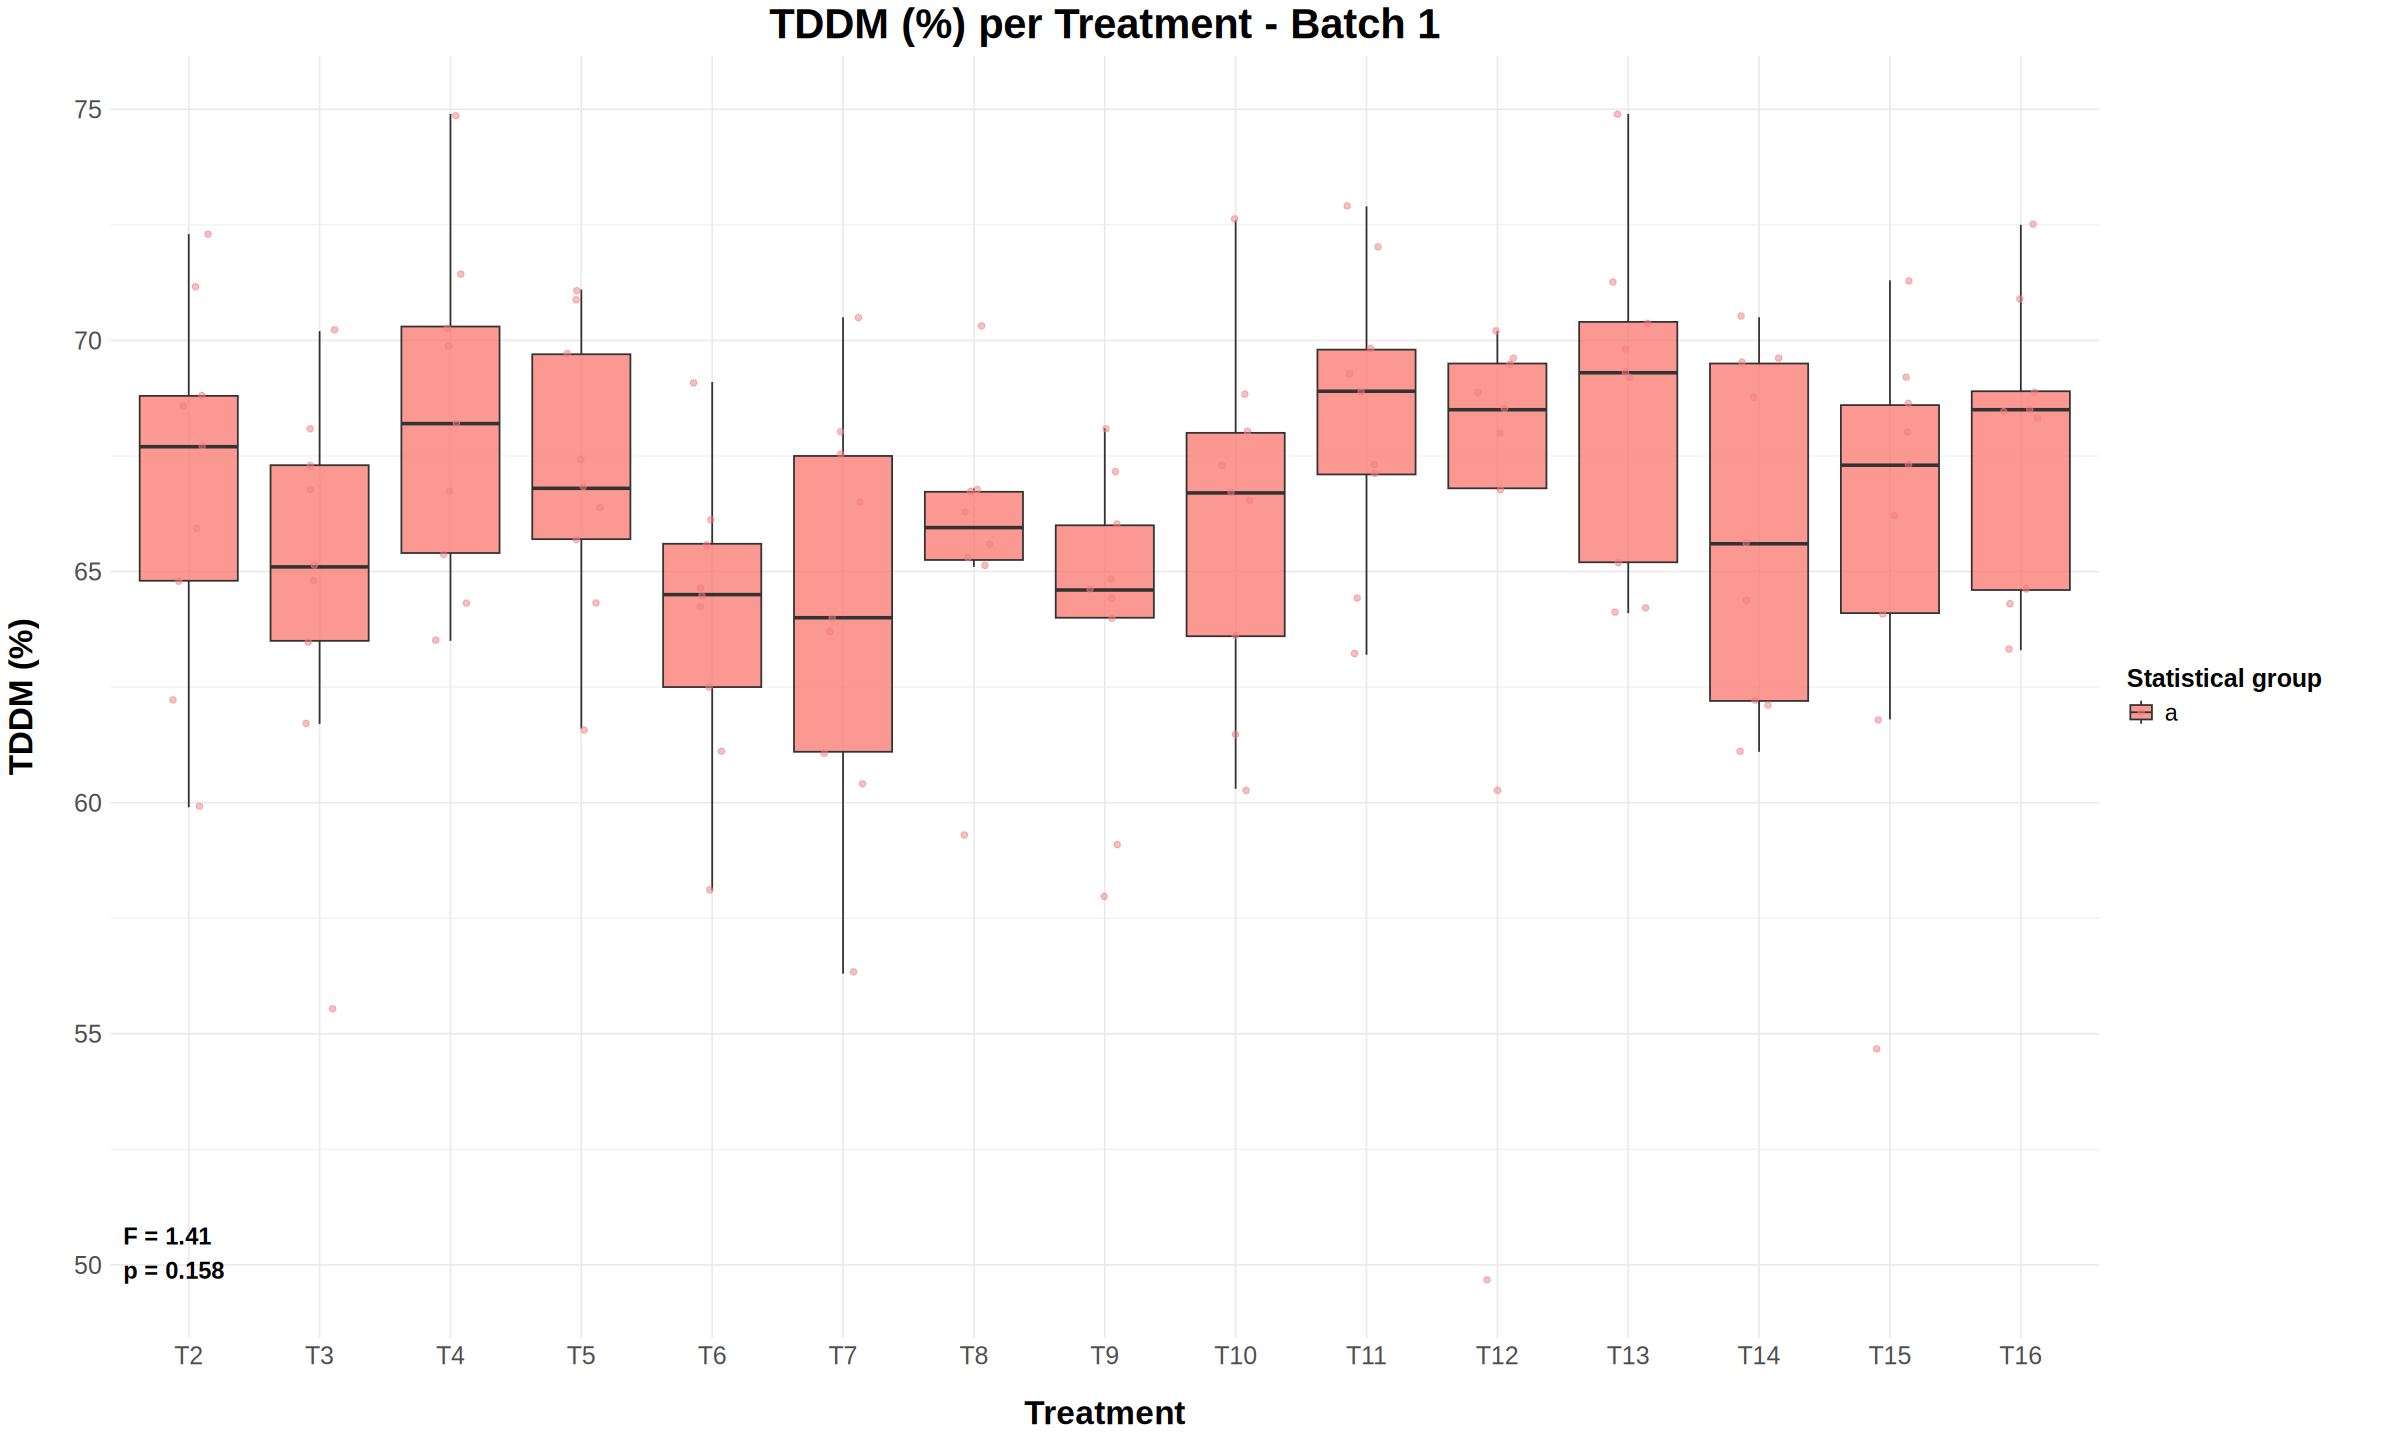

In [35]:
result_batch_1 <- plot_anova_treatment(
  data = batch_1,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Batch 1",
  y_label = "TDDM (%)"
)

### 5.1.2 Batch 2

In [73]:
list_batch_2

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25" "T26" "T27"
[13] "T28" "T29" "T30" "T31" "T32"


ANALYSIS: TDDM (%) per Treatment - Batch 2 

--- ANOVA ---
Analysis of Variance Table

Response: TDDM_percentage
           Df  Sum Sq Mean Sq F value    Pr(>F)    
Treatment  16  451.11 28.1945  3.1925 0.0001212 ***
Residuals 132 1165.76  8.8315                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 3.192486

--- P VALUE ---
[1] 0.0001212288

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.9898, p-value = 0.3535


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  TDDM_percentage by Treatment
Bartlett's K-squared = 24.379, df = 16, p-value = 0.08155


--- TUKEY GROUPS ---
   Treatment     mean letter
1        T20 69.98889      a
2        T24 69.80000     ab
3        T26 69.65556     ab
4        T19 69.27778     ab
5        T25 69.12222    abc
6        T22 68.96667    abc
7        T17 68.62857    abc
8        T18 68.52222    abc
9        T28 68.30000    abc
10       T27

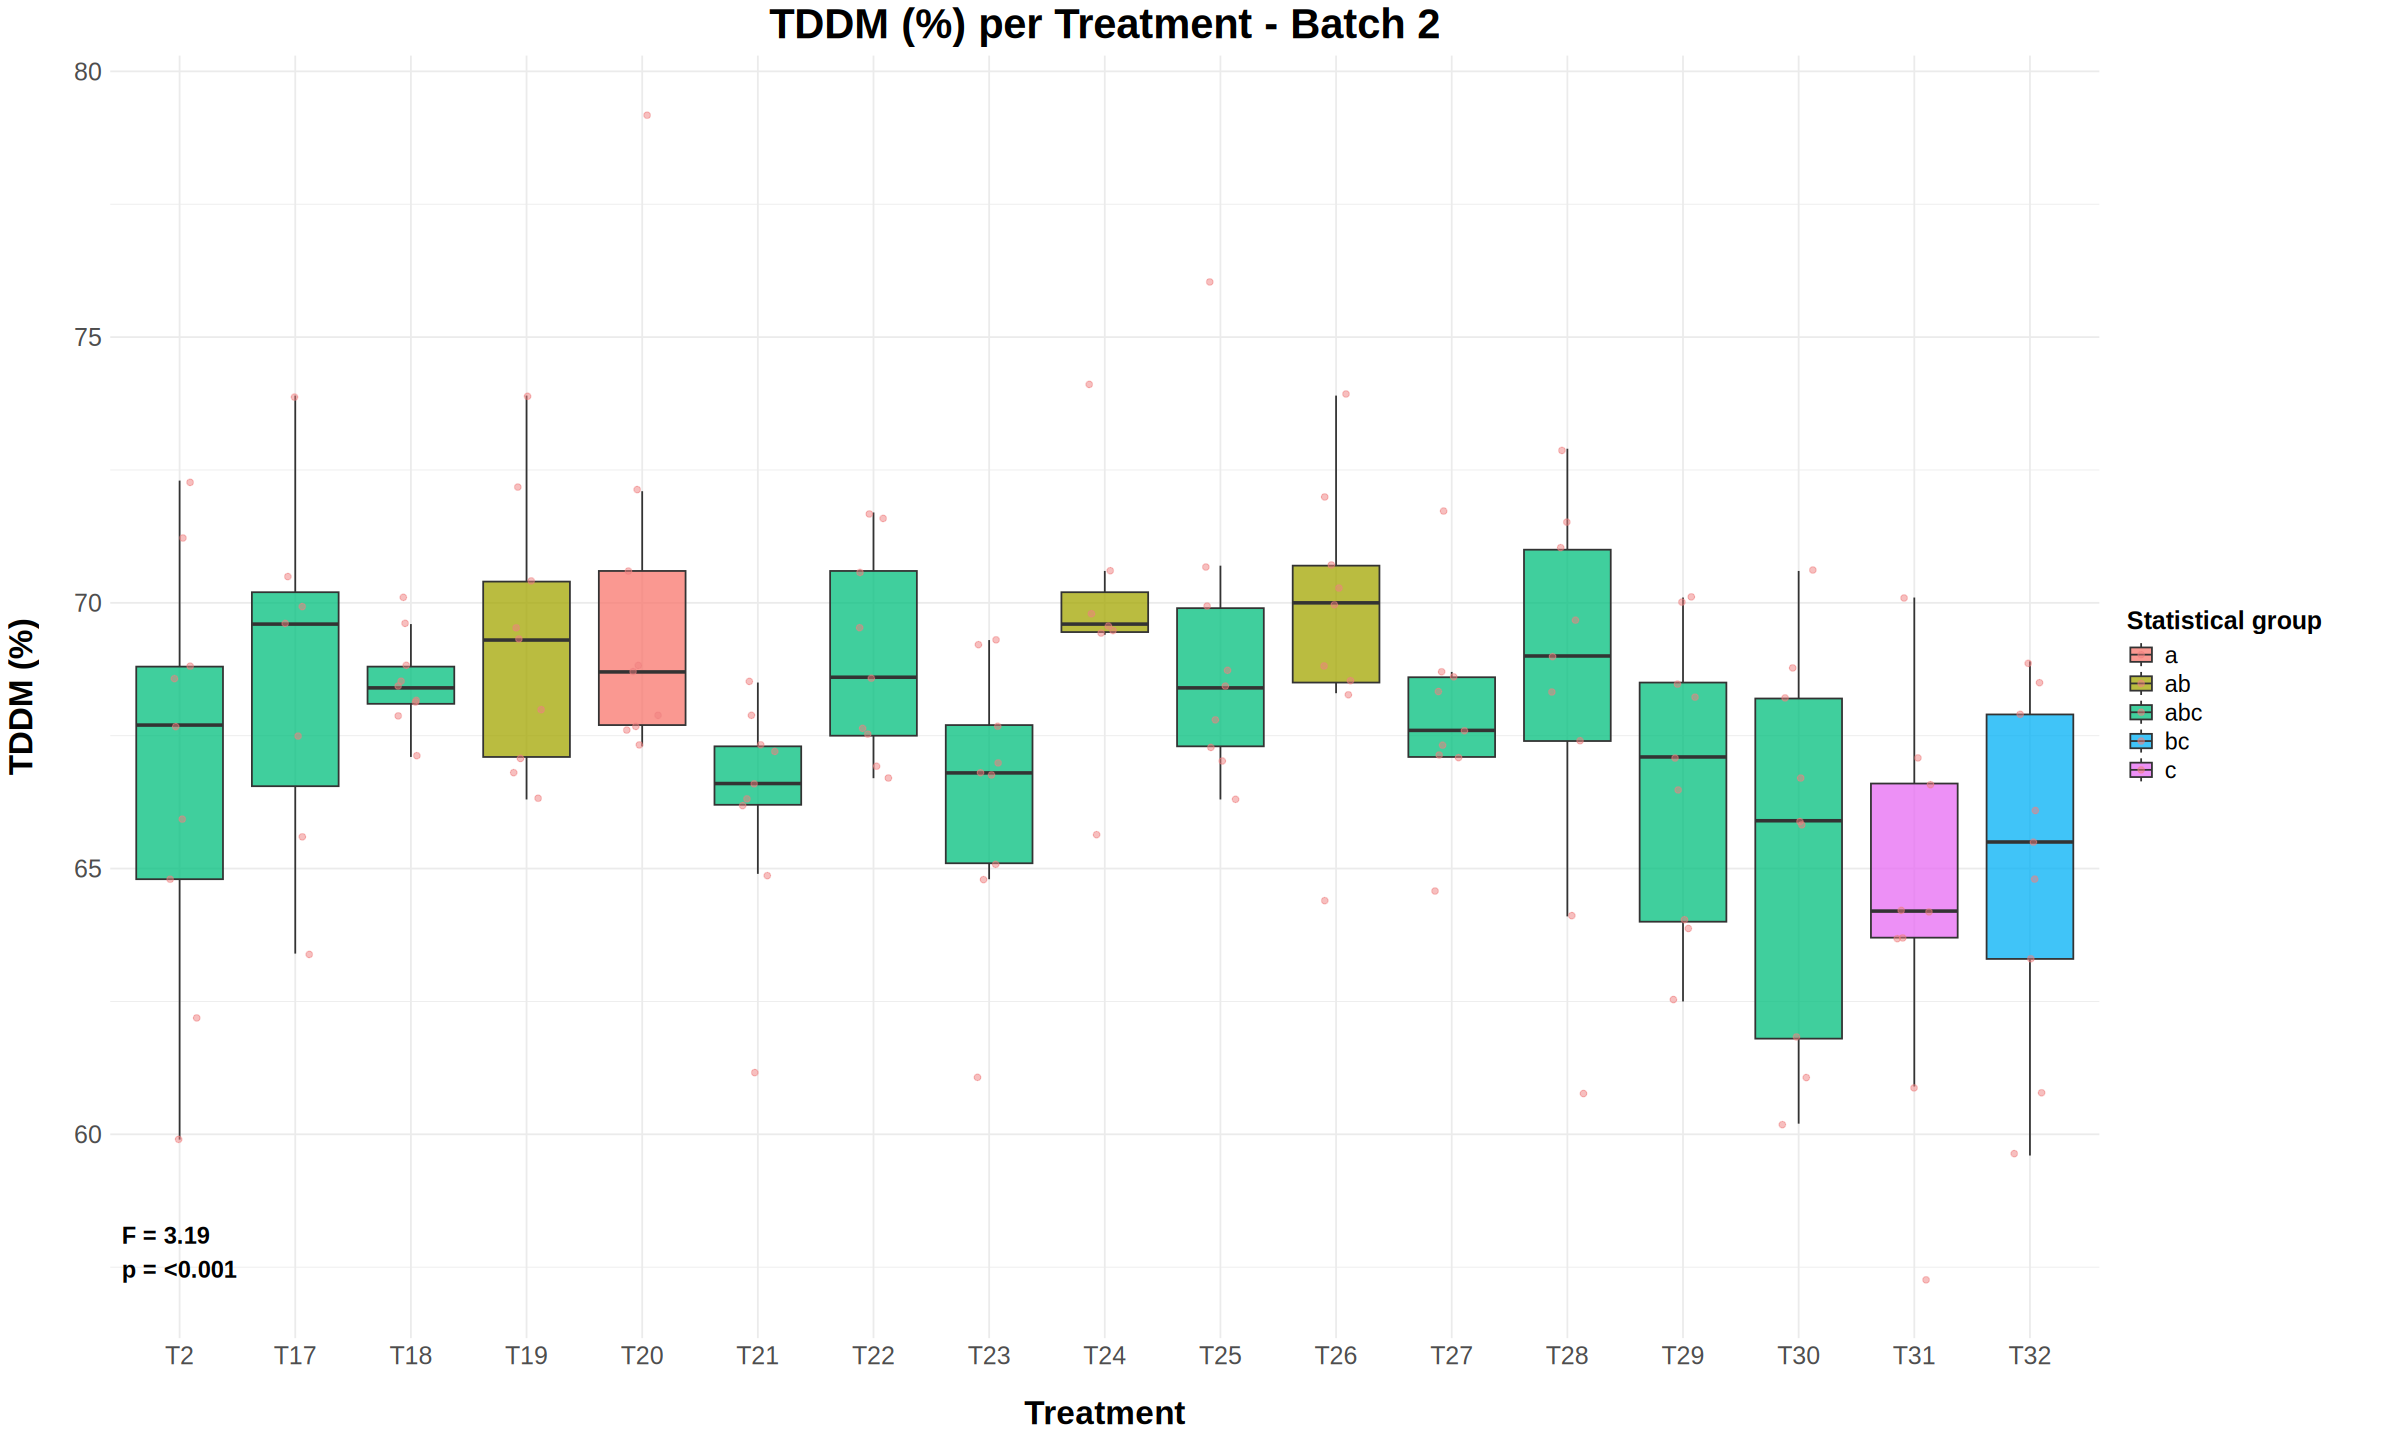

In [91]:
result_batch_2 <- plot_anova_treatment(
  data = batch_2,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Batch 2",
  y_label = "TDDM (%)"
)

### 5.1.3 Batch 3

In [72]:
list_batch_3

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25"


ANALYSIS: TDDM (%) per Treatment - Batch 3 

--- ANOVA ---
Analysis of Variance Table

Response: TDDM_percentage
          Df Sum Sq Mean Sq F value  Pr(>F)  
Treatment  9    151 16.7783  2.1182 0.03794 *
Residuals 76    602  7.9211                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 2.118186

--- P VALUE ---
[1] 0.03794335

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.97271, p-value = 0.06534


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  TDDM_percentage by Treatment
Bartlett's K-squared = 18.405, df = 9, p-value = 0.03075


--- TUKEY GROUPS ---
   Treatment     mean letter
1        T20 69.98889      a
2        T24 69.80000      a
3        T19 69.27778      a
4        T25 69.12222      a
5        T22 68.96667      a
6        T17 68.62857      a
7        T18 68.52222      a
8         T2 66.82222      a
9        T23 66.42222      a
10       T21 66.23333      a




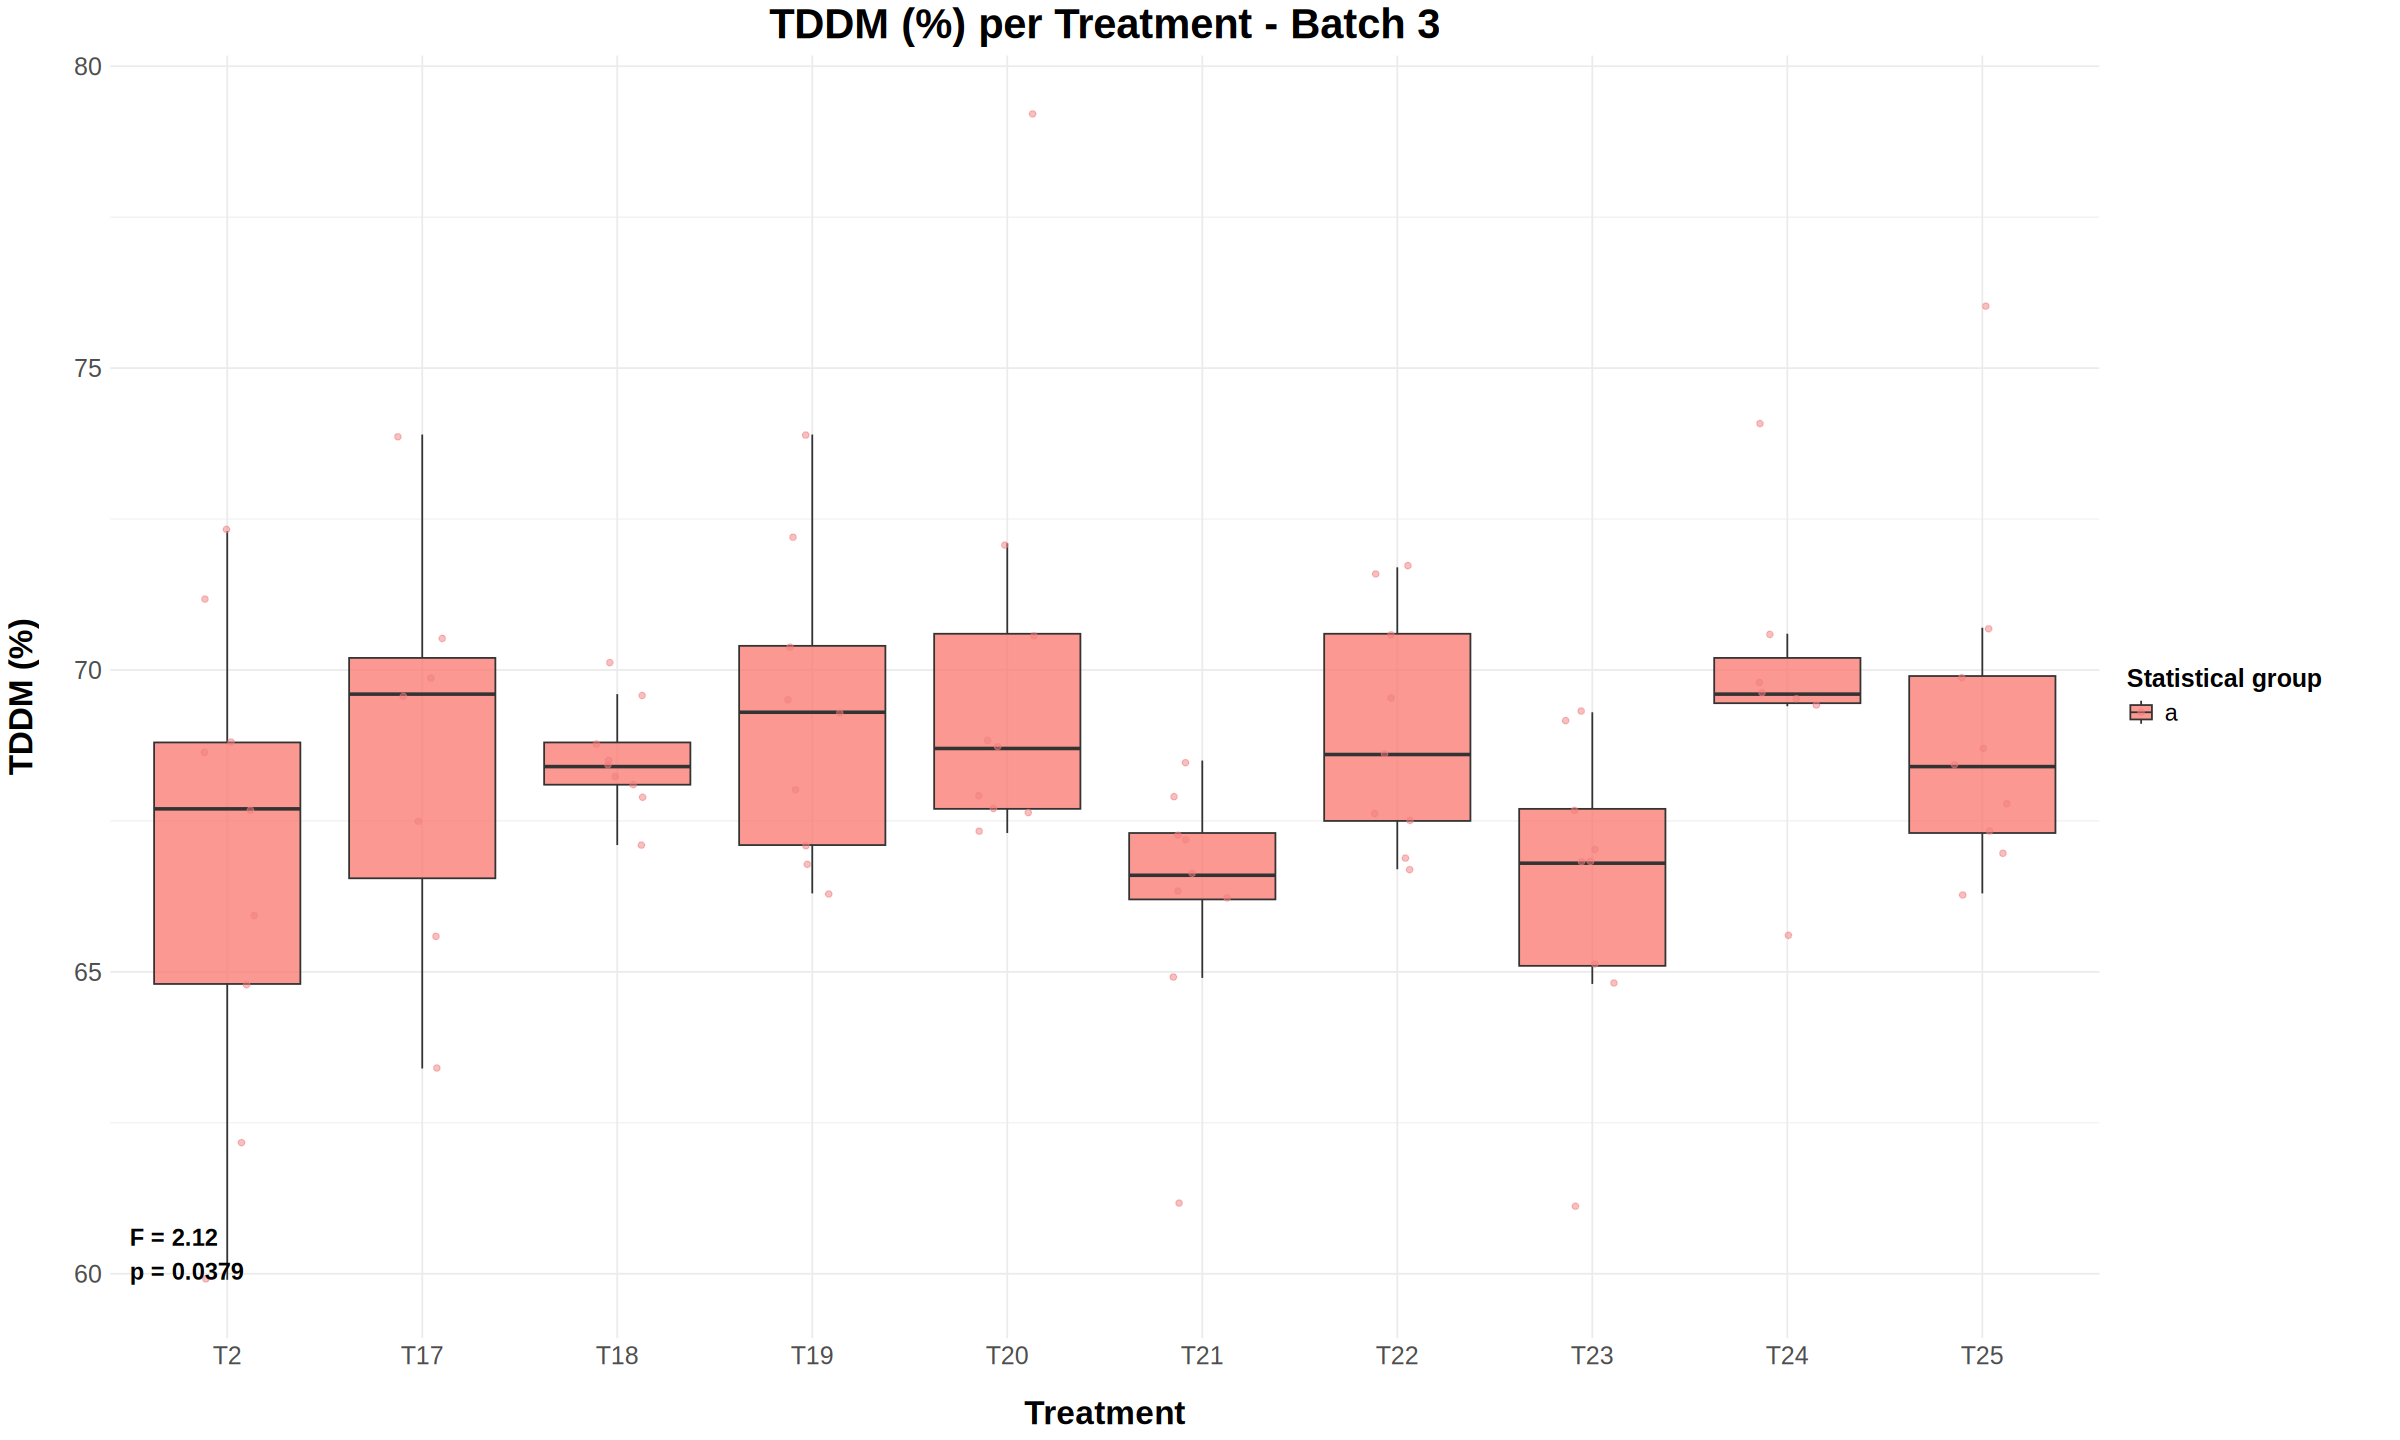

In [92]:
result_batch_3 <- plot_anova_treatment(
  data = batch_3,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Batch 3",
  y_label = "TDDM (%)"
)

### 5.1.4 Batch 4

In [71]:
list_batch_4

[1] "T2"  "T26" "T27" "T28" "T29" "T30" "T31" "T32"


ANALYSIS: TDDM (%) per Treatment - Batch 4 

--- ANOVA ---
Analysis of Variance Table

Response: TDDM_percentage
          Df Sum Sq Mean Sq F value  Pr(>F)  
Treatment  7 209.09  29.870  2.7506 0.01461 *
Residuals 64 694.99  10.859                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 2.750643

--- P VALUE ---
[1] 0.0146101

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.9717, p-value = 0.1041


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  TDDM_percentage by Treatment
Bartlett's K-squared = 5.9198, df = 7, p-value = 0.5491


--- TUKEY GROUPS ---
  Treatment     mean letter
1       T26 69.65556      a
2       T28 68.30000     ab
3       T27 67.88889     ab
4        T2 66.82222     ab
5       T29 66.75556     ab
6       T30 65.45556     ab
7       T32 65.04444     ab
8       T31 64.20000      b


--- BOXPLOT ---



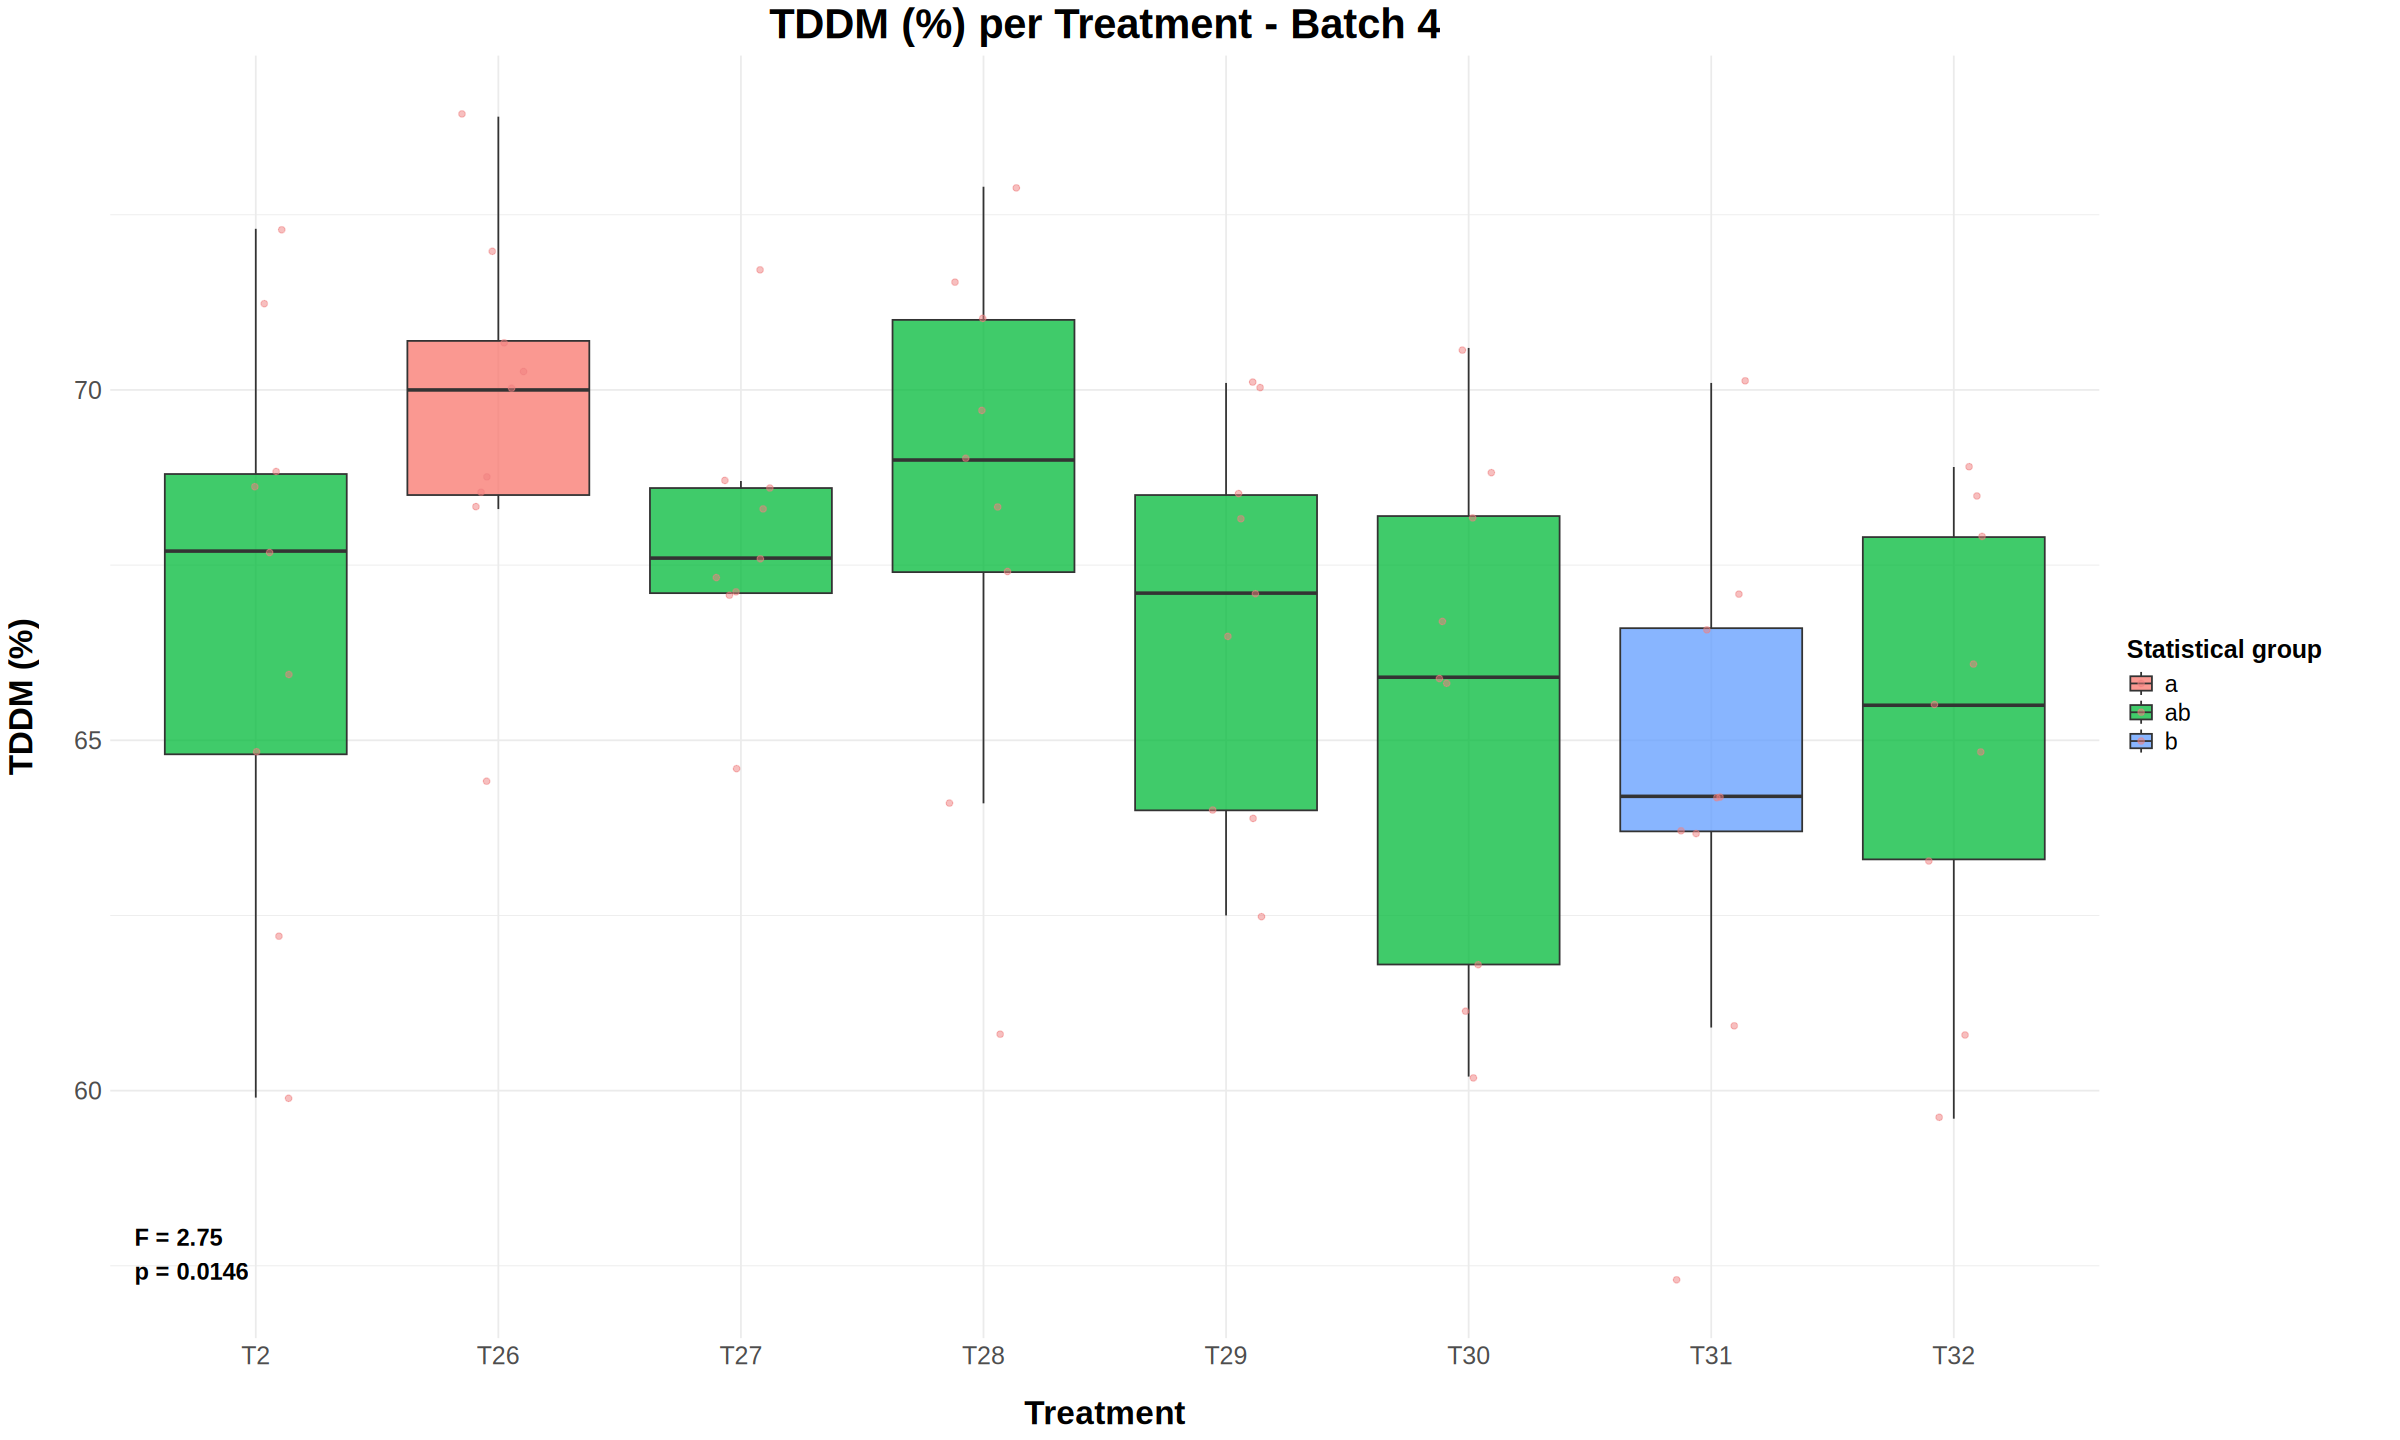

In [93]:
result_batch_4 <- plot_anova_treatment(
  data = batch_4,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Batch 4",
  y_label = "TDDM (%)"
)

## 5.2 Methane Intensity

### 5.2.1 Batch 1

In [70]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"


ANALYSIS: Methane Intensity per Treatment - Batch 1 

--- ANOVA ---
Analysis of Variance Table

Response: CH4_ml_g_DMD_24h
           Df Sum Sq Mean Sq F value   Pr(>F)    
Treatment  14 2435.3 173.951  6.0691 6.24e-09 ***
Residuals 119 3410.8  28.662                     
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 6.069081

--- P VALUE ---
[1] 6.239563e-09

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.96101, p-value = 0.00071


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  CH4_ml_g_DMD_24h by Treatment
Bartlett's K-squared = 25.086, df = 14, p-value = 0.03373


--- TUKEY GROUPS ---
   Treatment     mean letter
1         T6 58.66667      a
2         T7 57.76667      a
3         T3 56.65556      a
4         T2 56.34444      a
5        T12 56.24444      a
6        T15 55.58889      a
7         T5 55.33333      a
8         T8 54.86250      a
9         T9 54.62222      a
10   

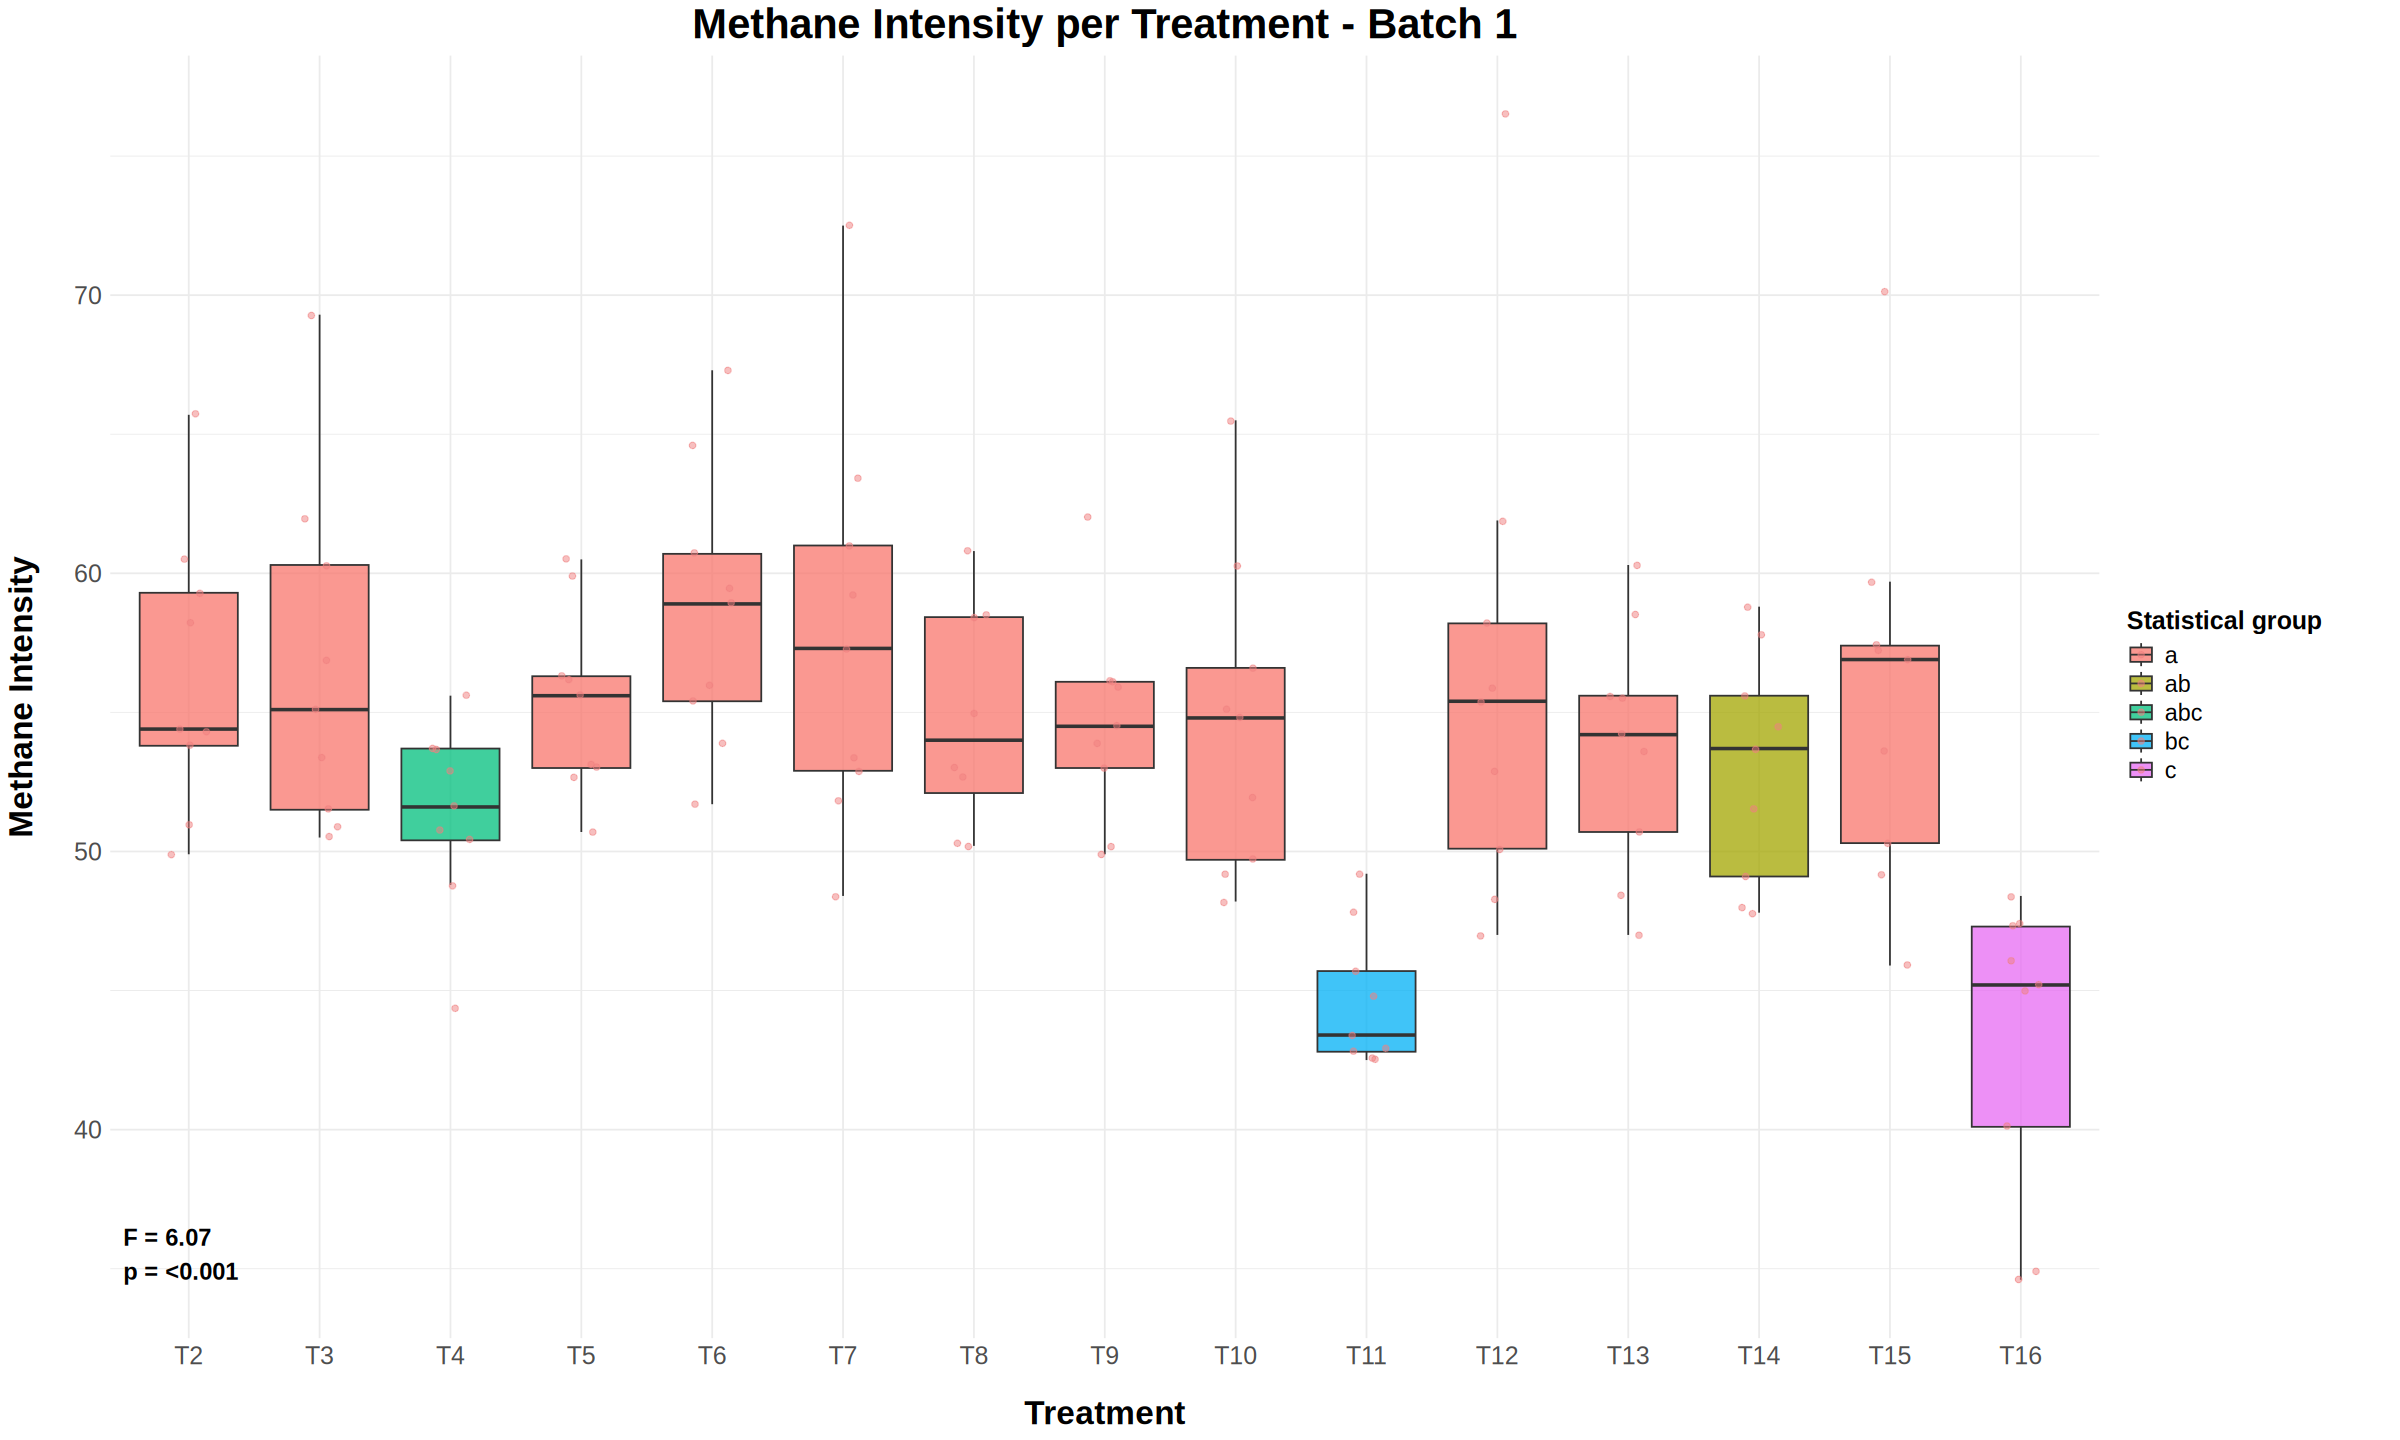

In [37]:
result_batch_1_methane_intensity <- plot_anova_treatment(
  data = batch_1,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Batch 1",
  y_label = "Methane Intensity"
)

### 5.2.2 Batch 2

In [69]:
list_batch_2

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25" "T26" "T27"
[13] "T28" "T29" "T30" "T31" "T32"


ANALYSIS: Methane Intensity per Treatment - Batch 2 

--- ANOVA ---
Analysis of Variance Table

Response: CH4_ml_g_DMD_24h
           Df Sum Sq Mean Sq F value    Pr(>F)    
Treatment  16 8069.5  504.34    13.7 < 2.2e-16 ***
Residuals 132 4859.2   36.81                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 13.70034

--- P VALUE ---
[1] 5.725413e-21

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.98973, p-value = 0.3482


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  CH4_ml_g_DMD_24h by Treatment
Bartlett's K-squared = 43.022, df = 16, p-value = 0.0002773


--- TUKEY GROUPS ---
   Treatment     mean letter
1         T2 56.34444      a
2        T31 53.60000     ab
3        T24 52.15714     ab
4        T29 50.77778     ab
5        T17 49.21429     ab
6        T19 49.06667     ab
7        T26 48.33333     ab
8        T28 48.30000     ab
9        T22 48.20000     ab
1

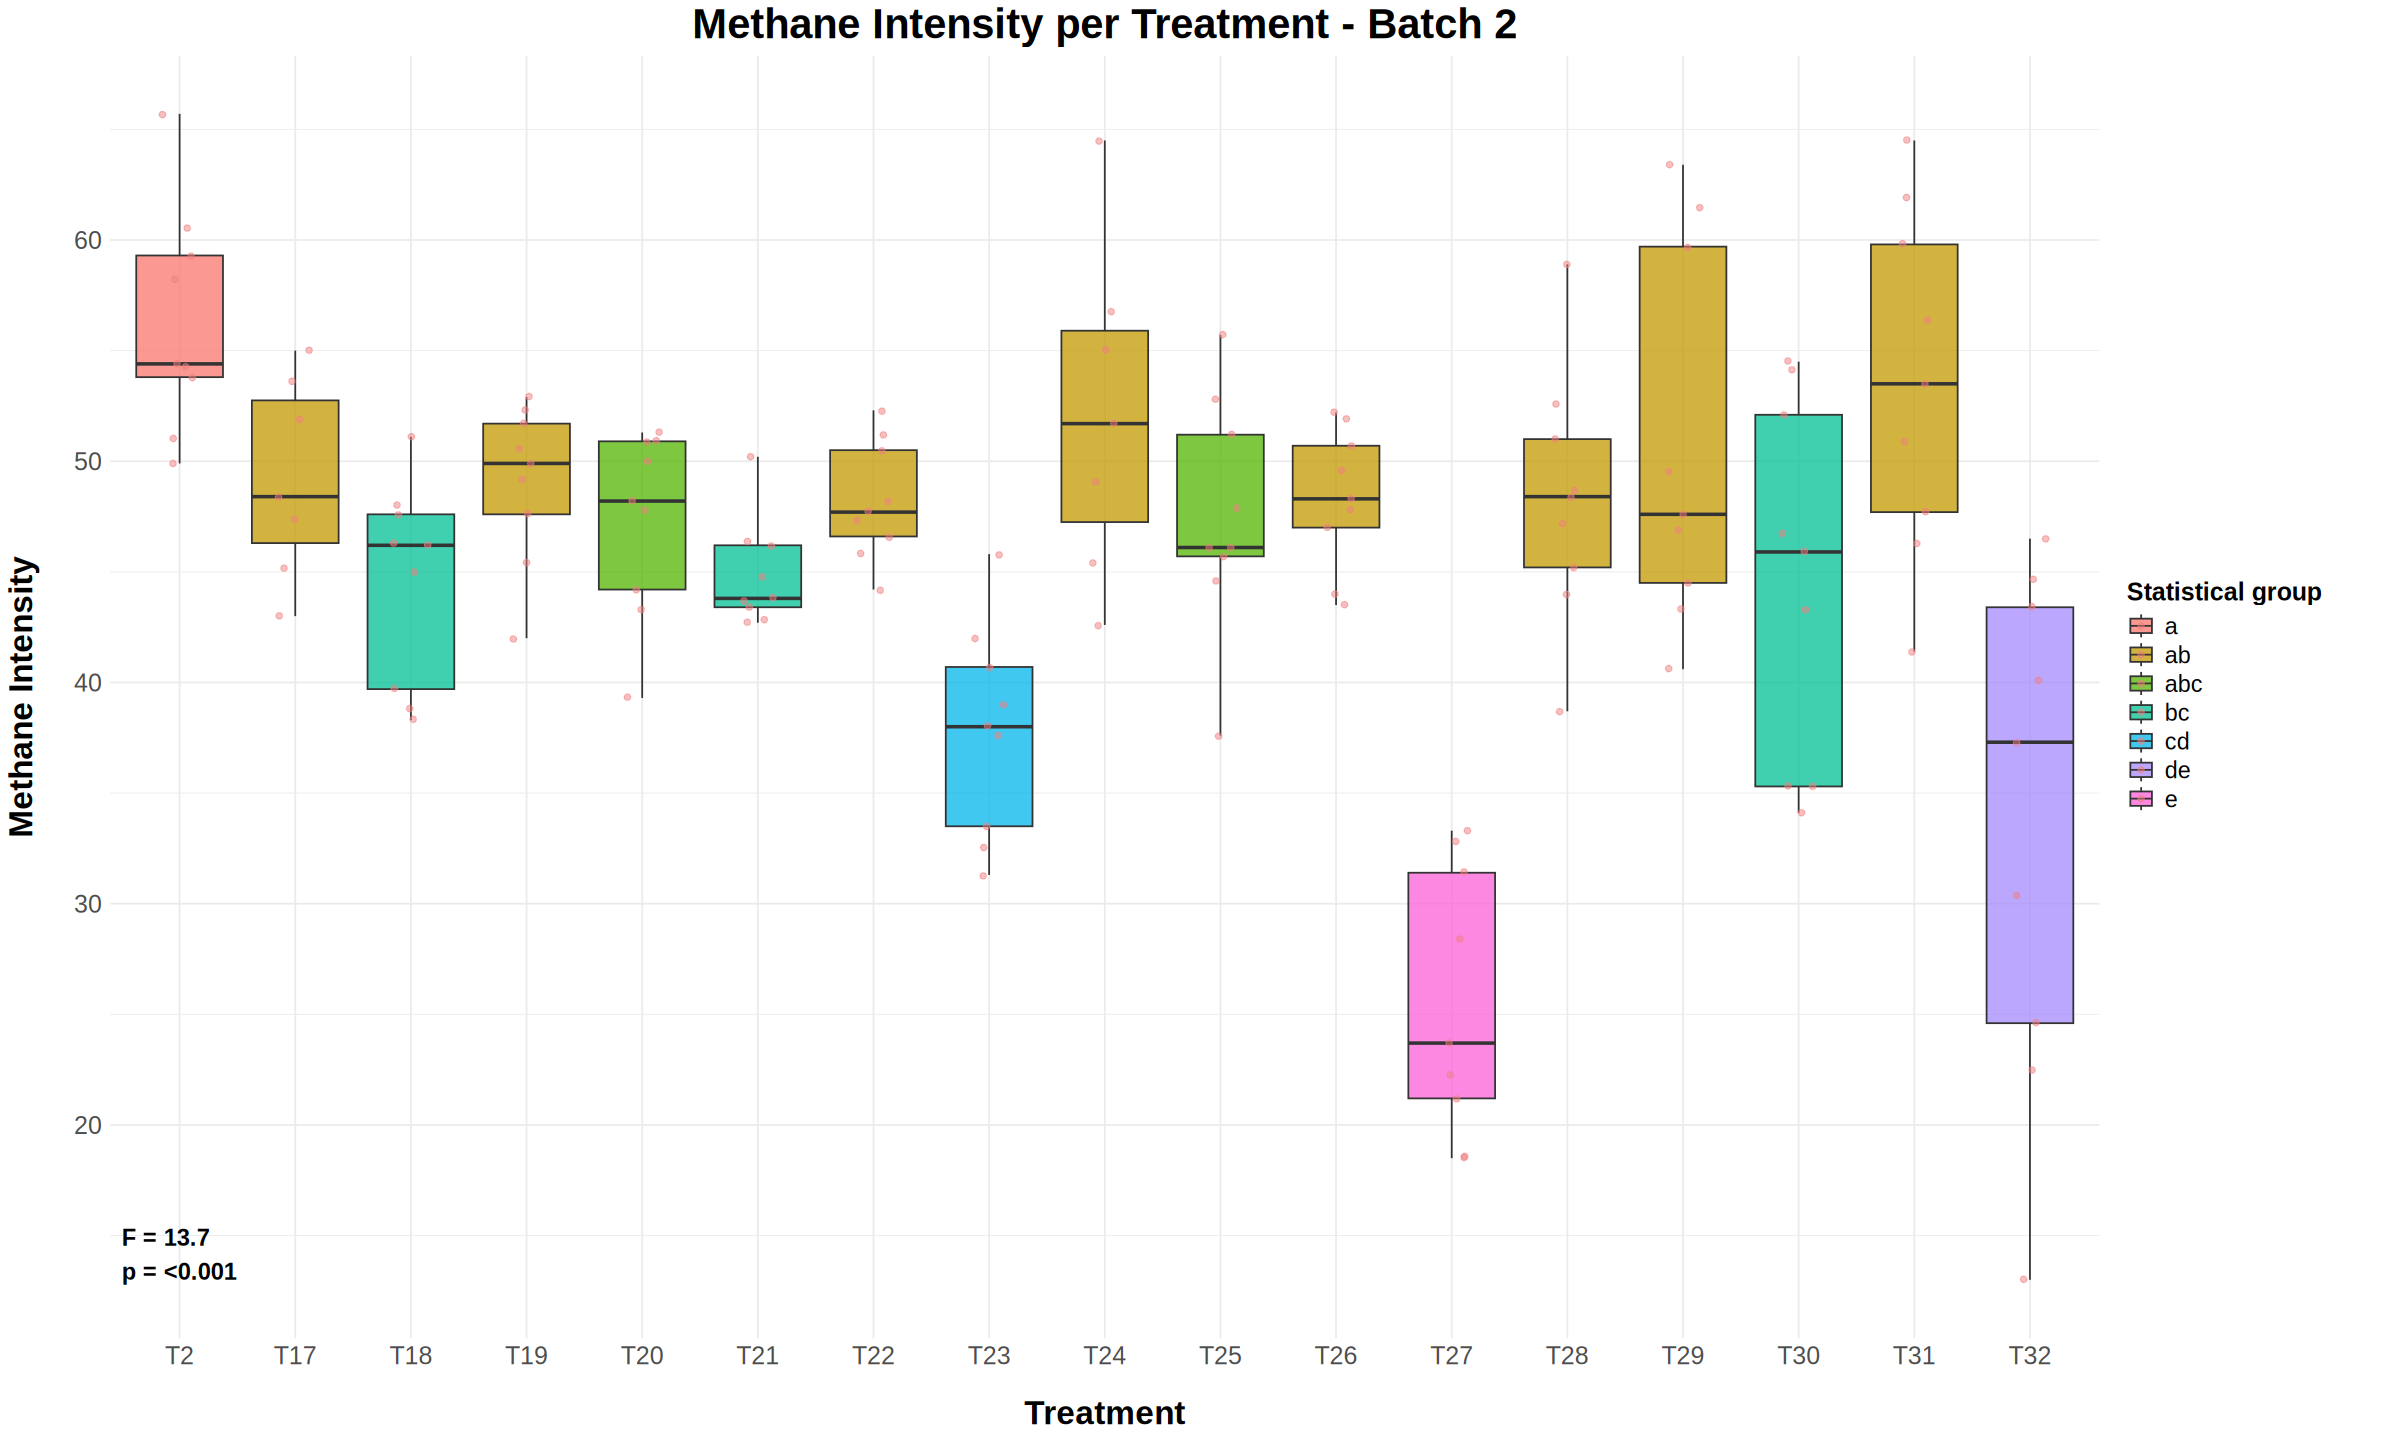

In [38]:
result_batch_2_methane_intensity <- plot_anova_treatment(
  data = batch_2,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Batch 2",
  y_label = "Methane Intensity"
)

### 5.2.3 Batch 3

In [68]:
list_batch_3

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25"


ANALYSIS: Methane Intensity per Treatment - Batch 3 

--- ANOVA ---
Analysis of Variance Table

Response: CH4_ml_g_DMD_24h
          Df Sum Sq Mean Sq F value    Pr(>F)    
Treatment  9 1885.1 209.455  10.199 3.944e-10 ***
Residuals 76 1560.8  20.536                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 10.19919

--- P VALUE ---
[1] 3.944405e-10

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.99187, p-value = 0.8753


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  CH4_ml_g_DMD_24h by Treatment
Bartlett's K-squared = 12.733, df = 9, p-value = 0.1751


--- TUKEY GROUPS ---
   Treatment     mean letter
1         T2 56.34444      a
2        T24 52.15714     ab
3        T17 49.21429    abc
4        T19 49.06667     bc
5        T22 48.20000     bc
6        T25 47.52222     bc
7        T20 47.32222     bc
8        T21 44.88889     bc
9        T18 44.55556     cd
10      

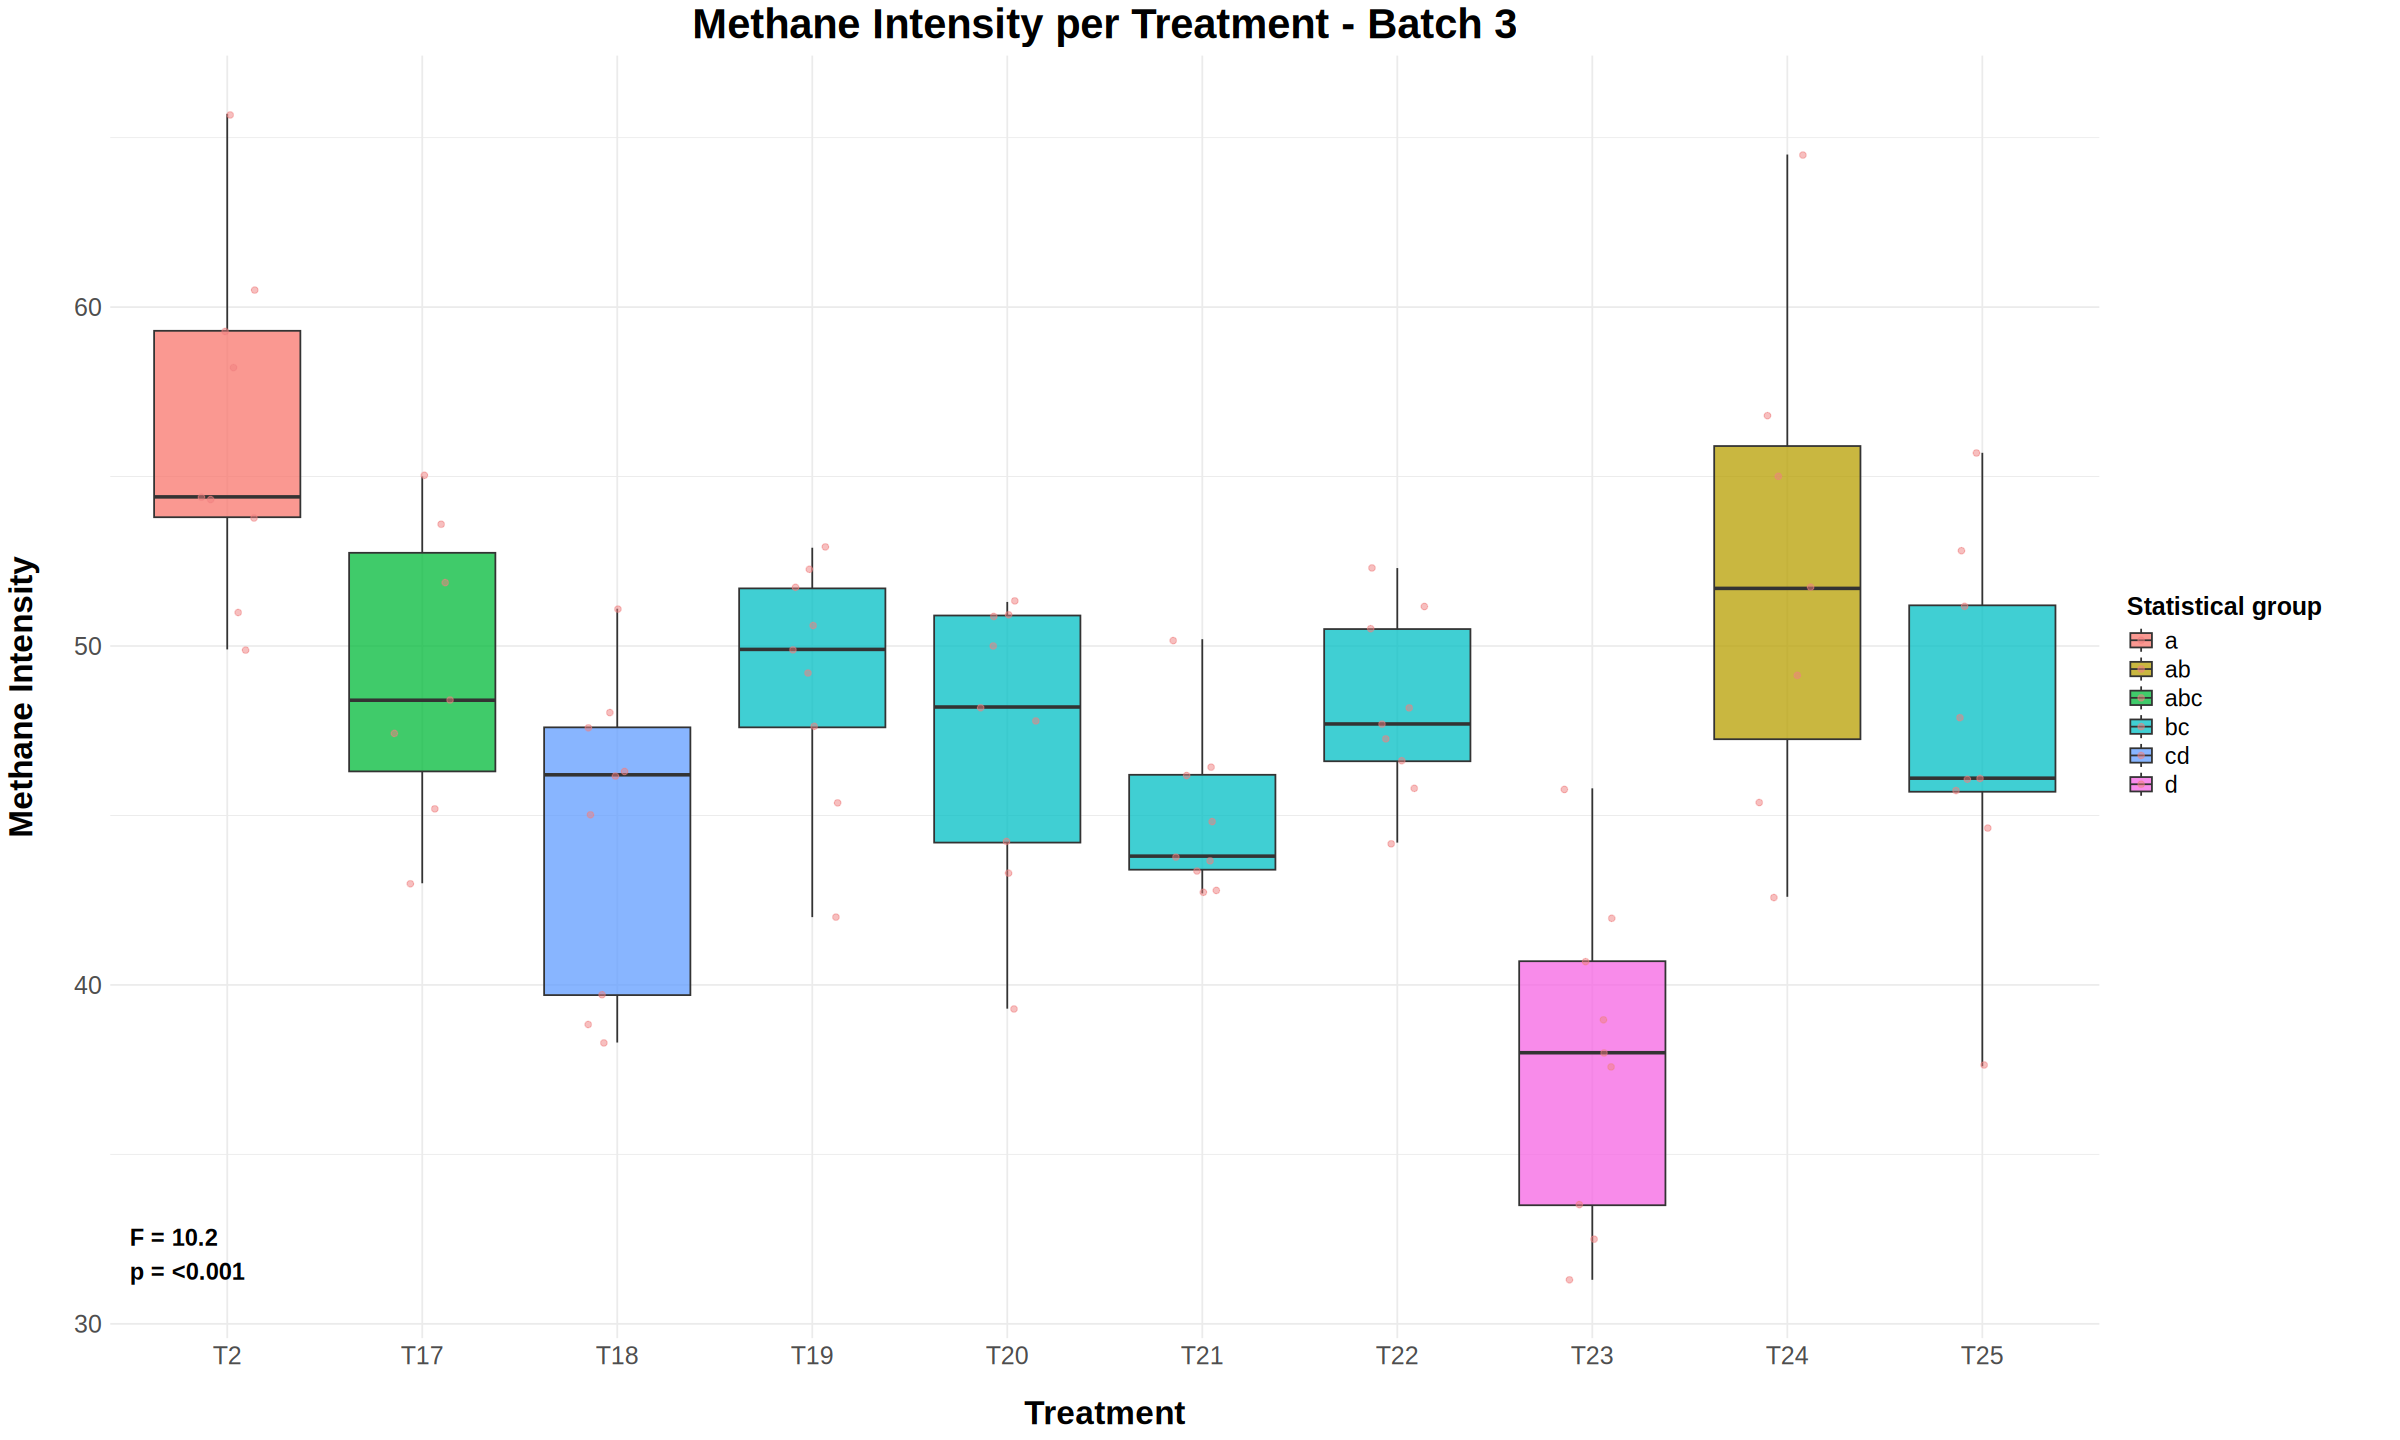

In [39]:
result_batch_3_methane_intensity <- plot_anova_treatment(
  data = batch_3,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Batch 3",
  y_label = "Methane Intensity"
)

### 5.2.4 Batch 4

In [67]:
list_batch_4

[1] "T2"  "T26" "T27" "T28" "T29" "T30" "T31" "T32"


ANALYSIS: Methane Intensity per Treatment - Batch 4 

--- ANOVA ---
Analysis of Variance Table

Response: CH4_ml_g_DMD_24h
          Df Sum Sq Mean Sq F value    Pr(>F)    
Treatment  7 6884.8  983.54  17.985 5.685e-13 ***
Residuals 64 3500.0   54.69                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 17.98494

--- P VALUE ---
[1] 5.685478e-13

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.97988, p-value = 0.303


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  CH4_ml_g_DMD_24h by Treatment
Bartlett's K-squared = 14.949, df = 7, p-value = 0.03666


--- TUKEY GROUPS ---
  Treatment     mean letter
1        T2 56.34444      a
2       T31 53.60000     ab
3       T29 50.77778     ab
4       T26 48.33333     ab
5       T28 48.30000     ab
6       T30 44.58889      b
7       T32 33.61111      c
8       T27 25.57778      c


--- BOXPLOT ---



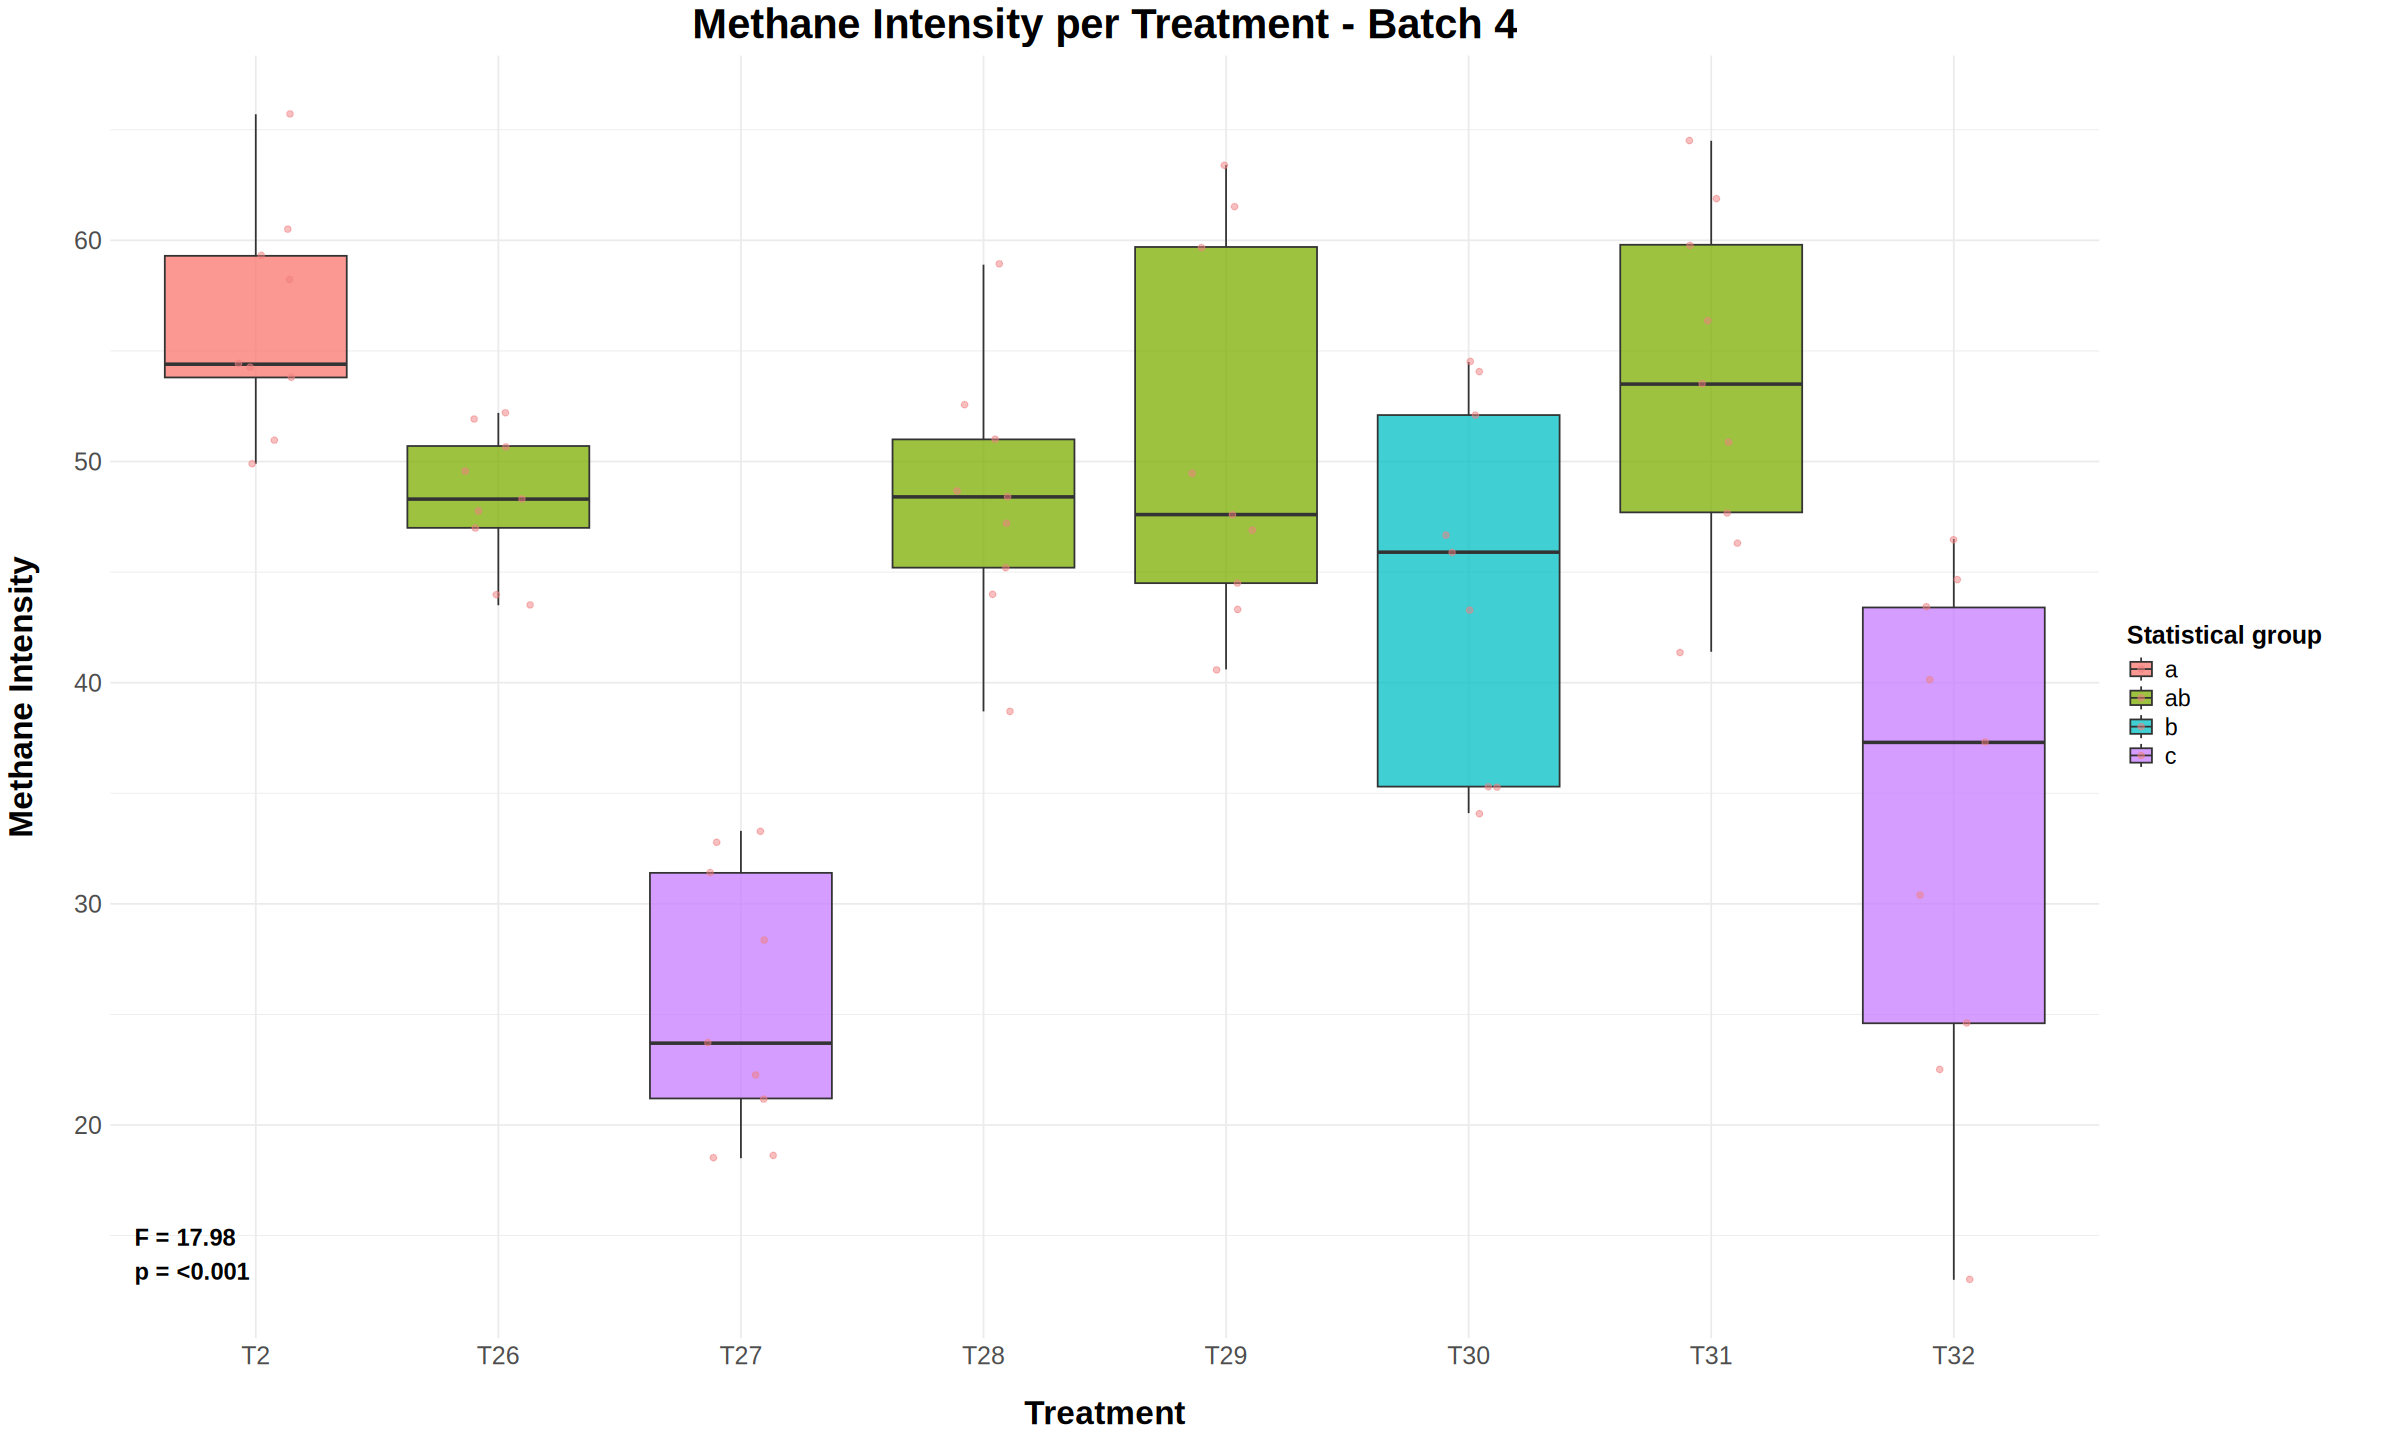

In [40]:
result_batch_4_methane_intensity <- plot_anova_treatment(
  data = batch_4,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Batch 4",
  y_label = "Methane Intensity"
)

## 5.3 Ammonium

### 5.3.1 Batch 1

In [66]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"


ANALYSIS: Ammonium per Treatment - Batch 1 

--- ANOVA ---
Analysis of Variance Table

Response: Amonio_corregido_ppm
           Df  Sum Sq Mean Sq F value Pr(>F)   
Treatment  14  335253   23947  2.2539 0.0093 **
Residuals 120 1274939   10624                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 2.253907

--- P VALUE ---
[1] 0.00929967

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.98603, p-value = 0.1862


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  Amonio_corregido_ppm by Treatment
Bartlett's K-squared = 22.976, df = 14, p-value = 0.06066


--- TUKEY GROUPS ---
   Treatment     mean letter
1         T3 288.4861      a
2         T9 233.1639     ab
3        T12 209.0861     ab
4        T11 204.1417     ab
5         T4 193.4972     ab
6         T8 190.8417     ab
7        T13 189.3750     ab
8        T10 175.0194     ab
9         T6 146.2194     ab
10       T14 13

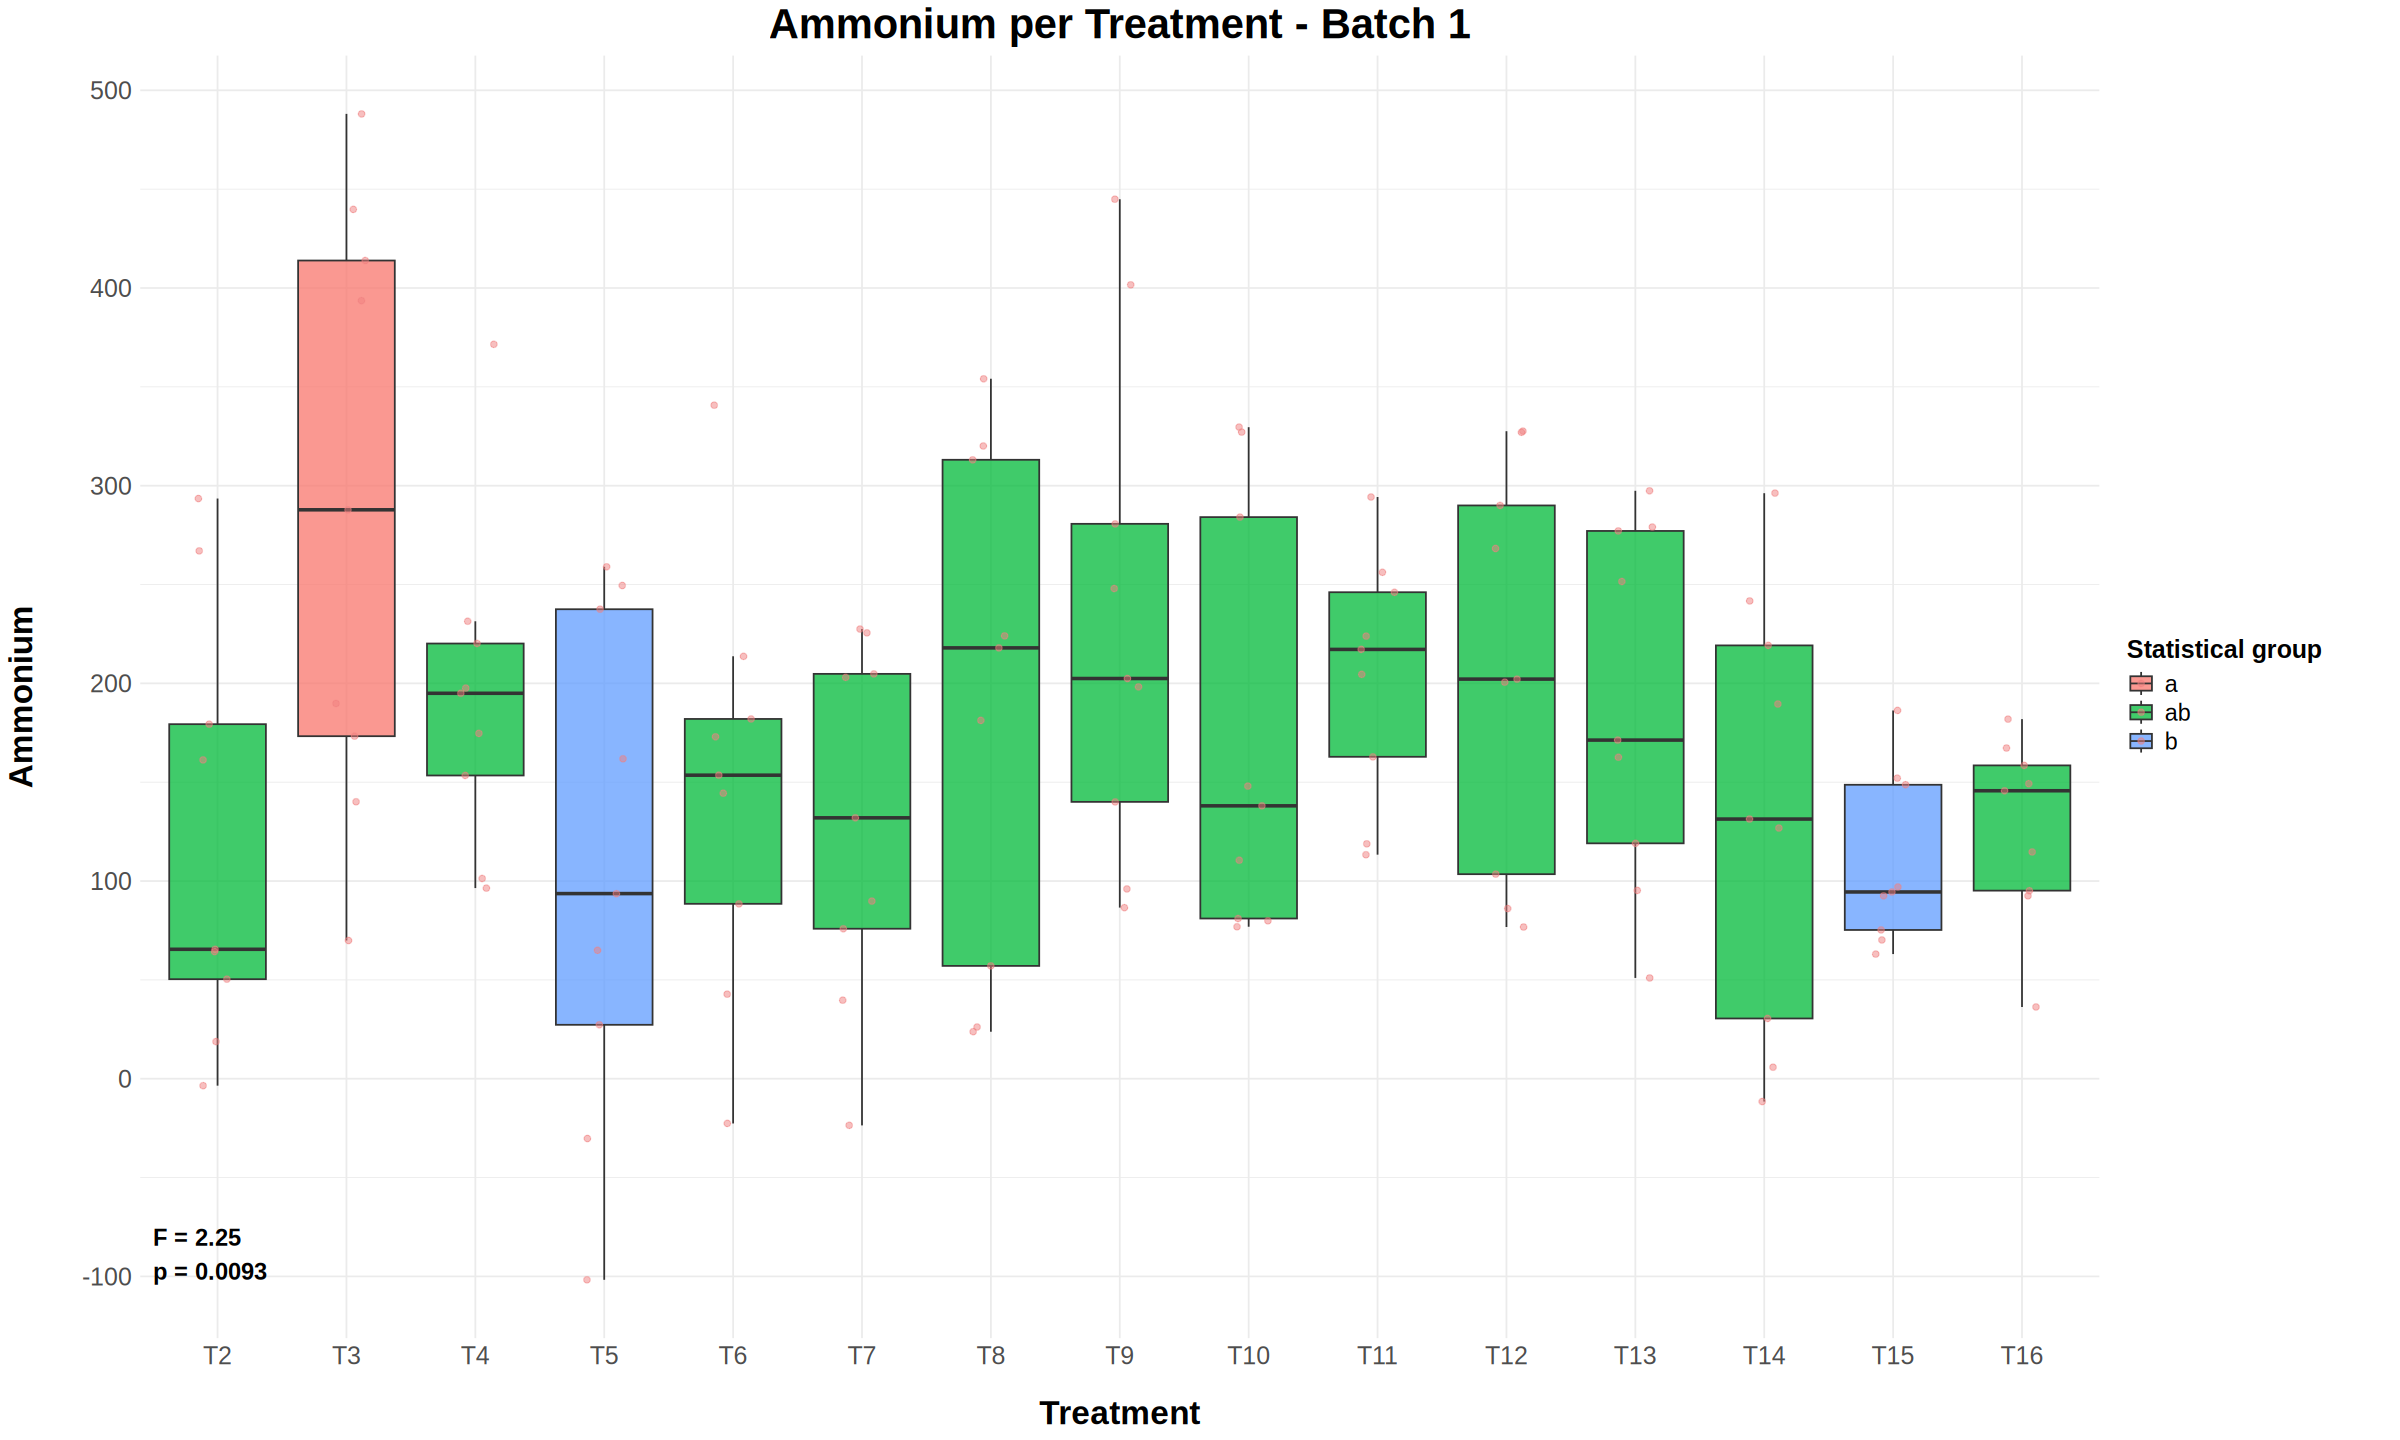

In [47]:
result_batch_1_ammonium <- plot_anova_treatment(
  data = batch_1,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Batch 1",
  y_label = "Ammonium"
)

### 5.3.2 Batch 2

In [65]:
list_batch_2

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25" "T26" "T27"
[13] "T28" "T29" "T30" "T31" "T32"


ANALYSIS: Ammonium per Treatment - Batch 2 

--- ANOVA ---
Analysis of Variance Table

Response: Amonio_corregido_ppm
           Df  Sum Sq Mean Sq F value Pr(>F)
Treatment  16  313838   19615  1.2646  0.229
Residuals 134 2078414   15511               

--- F VALUE ---
[1] 1.264616

--- P VALUE ---
[1] 0.2290463

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.95339, p-value = 5.97e-05


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  Amonio_corregido_ppm by Treatment
Bartlett's K-squared = 30.476, df = 16, p-value = 0.01568


--- TUKEY GROUPS ---
   Treatment      mean letter
1        T32 189.50833      a
2        T30 147.45278      a
3        T28 138.12500      a
4        T19 127.45278      a
5        T29 127.15278      a
6         T2 121.84167      a
7        T18 120.69722      a
8        T31 114.06389      a
9        T25 111.47500      a
10       T17 111.27500      a
11       T20 106.48611      a
12       T21  81.186

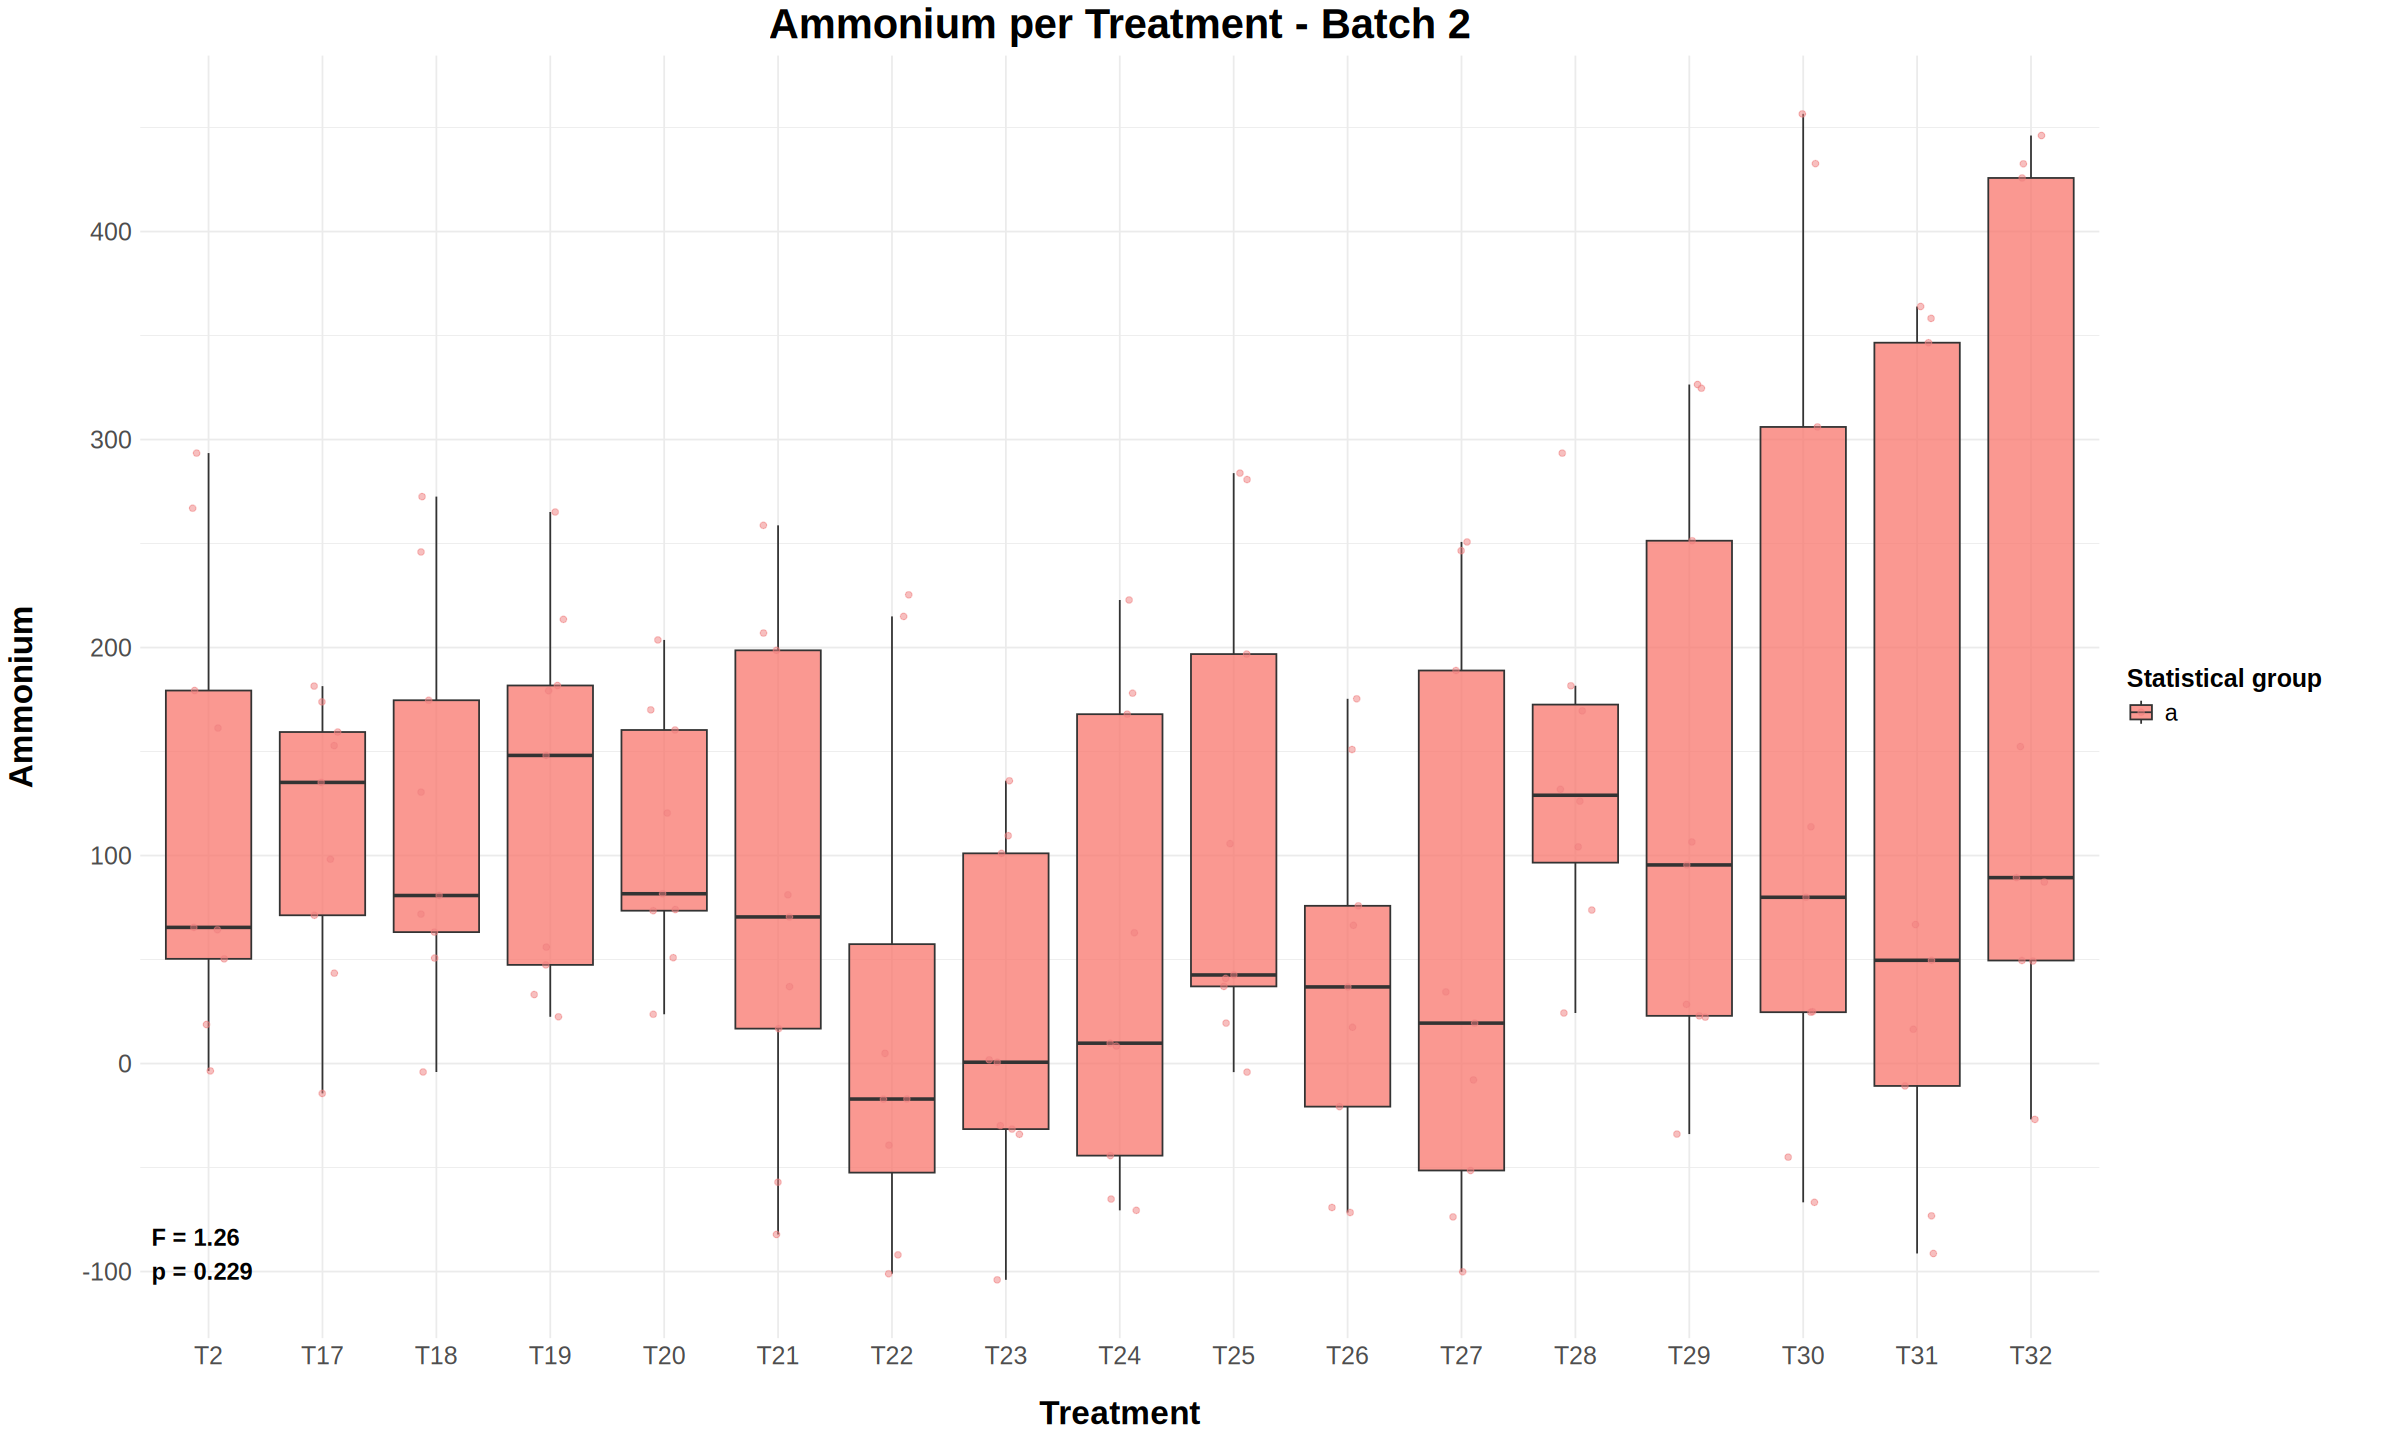

In [48]:
result_batch_2_ammonium <- plot_anova_treatment(
  data = batch_2,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Batch 2",
  y_label = "Ammonium"
)

### 5.3.3 Batch 3

In [64]:
list_batch_3

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25"


ANALYSIS: Ammonium per Treatment - Batch 3 

--- ANOVA ---
Analysis of Variance Table

Response: Amonio_corregido_ppm
          Df Sum Sq Mean Sq F value Pr(>F)
Treatment  9 139075 15452.8  1.5777 0.1364
Residuals 79 773789  9794.8               

--- F VALUE ---
[1] 1.577653

--- P VALUE ---
[1] 0.1364269

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.94764, p-value = 0.001292


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  Amonio_corregido_ppm by Treatment
Bartlett's K-squared = 7.6538, df = 9, p-value = 0.5694


--- TUKEY GROUPS ---
   Treatment      mean letter
1        T19 127.45278      a
2         T2 121.84167      a
3        T18 120.69722      a
4        T25 111.47500      a
5        T17 111.27500      a
6        T20 106.48611      a
7        T21  81.18611      a
8        T24  52.23056      a
9        T22  22.36250      a
10       T23  16.64167      a


--- BOXPLOT ---



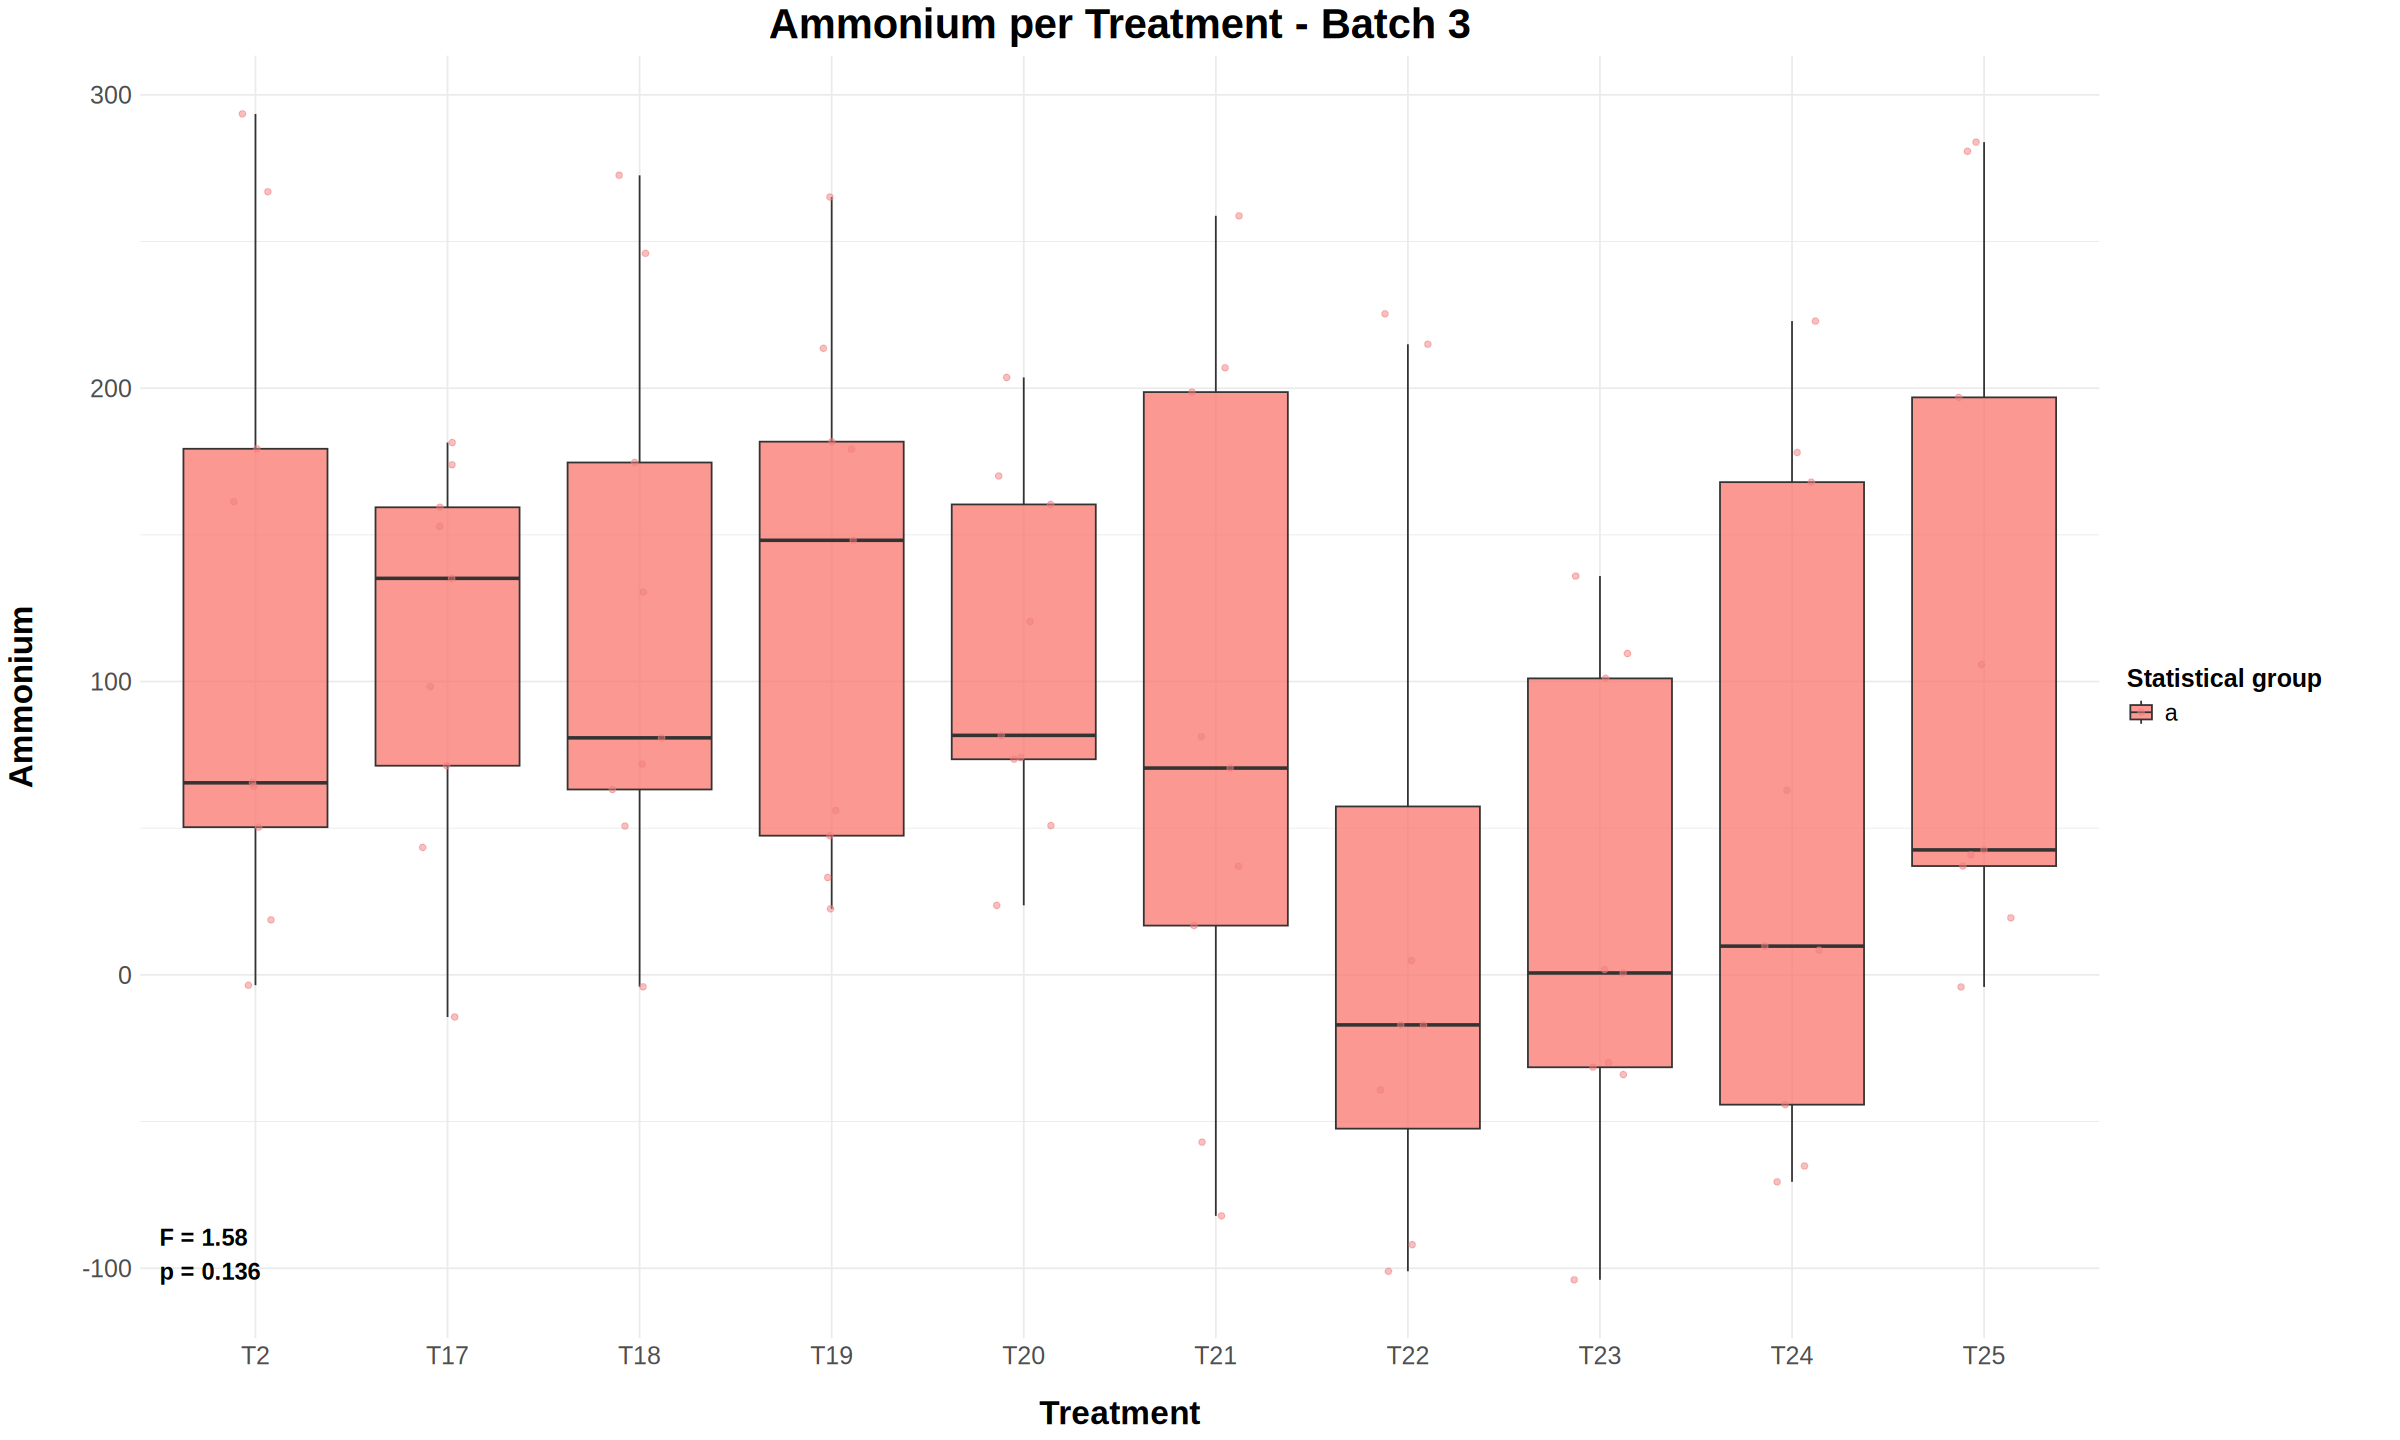

In [49]:
result_batch_3_ammonium <- plot_anova_treatment(
  data = batch_3,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Batch 3",
  y_label = "Ammonium"
)

### 5.3.4 Batch 4

In [63]:
list_batch_4

[1] "T2"  "T26" "T27" "T28" "T29" "T30" "T31" "T32"


ANALYSIS: Ammonium per Treatment - Batch 4 

--- ANOVA ---
Analysis of Variance Table

Response: Amonio_corregido_ppm
          Df  Sum Sq Mean Sq F value Pr(>F)
Treatment  7  146671   20953  0.9443 0.4794
Residuals 63 1397960   22190               

--- F VALUE ---
[1] 0.9442624

--- P VALUE ---
[1] 0.4793876

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.92377, p-value = 0.00035


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  Amonio_corregido_ppm by Treatment
Bartlett's K-squared = 11.796, df = 7, p-value = 0.1075


--- TUKEY GROUPS ---
  Treatment      mean letter
1       T32 189.50833      a
2       T30 147.45278      a
3       T28 138.12500      a
4       T29 127.15278      a
5        T2 121.84167      a
6       T31 114.06389      a
7       T27  56.35278      a
8       T26  40.16389      a


--- BOXPLOT ---



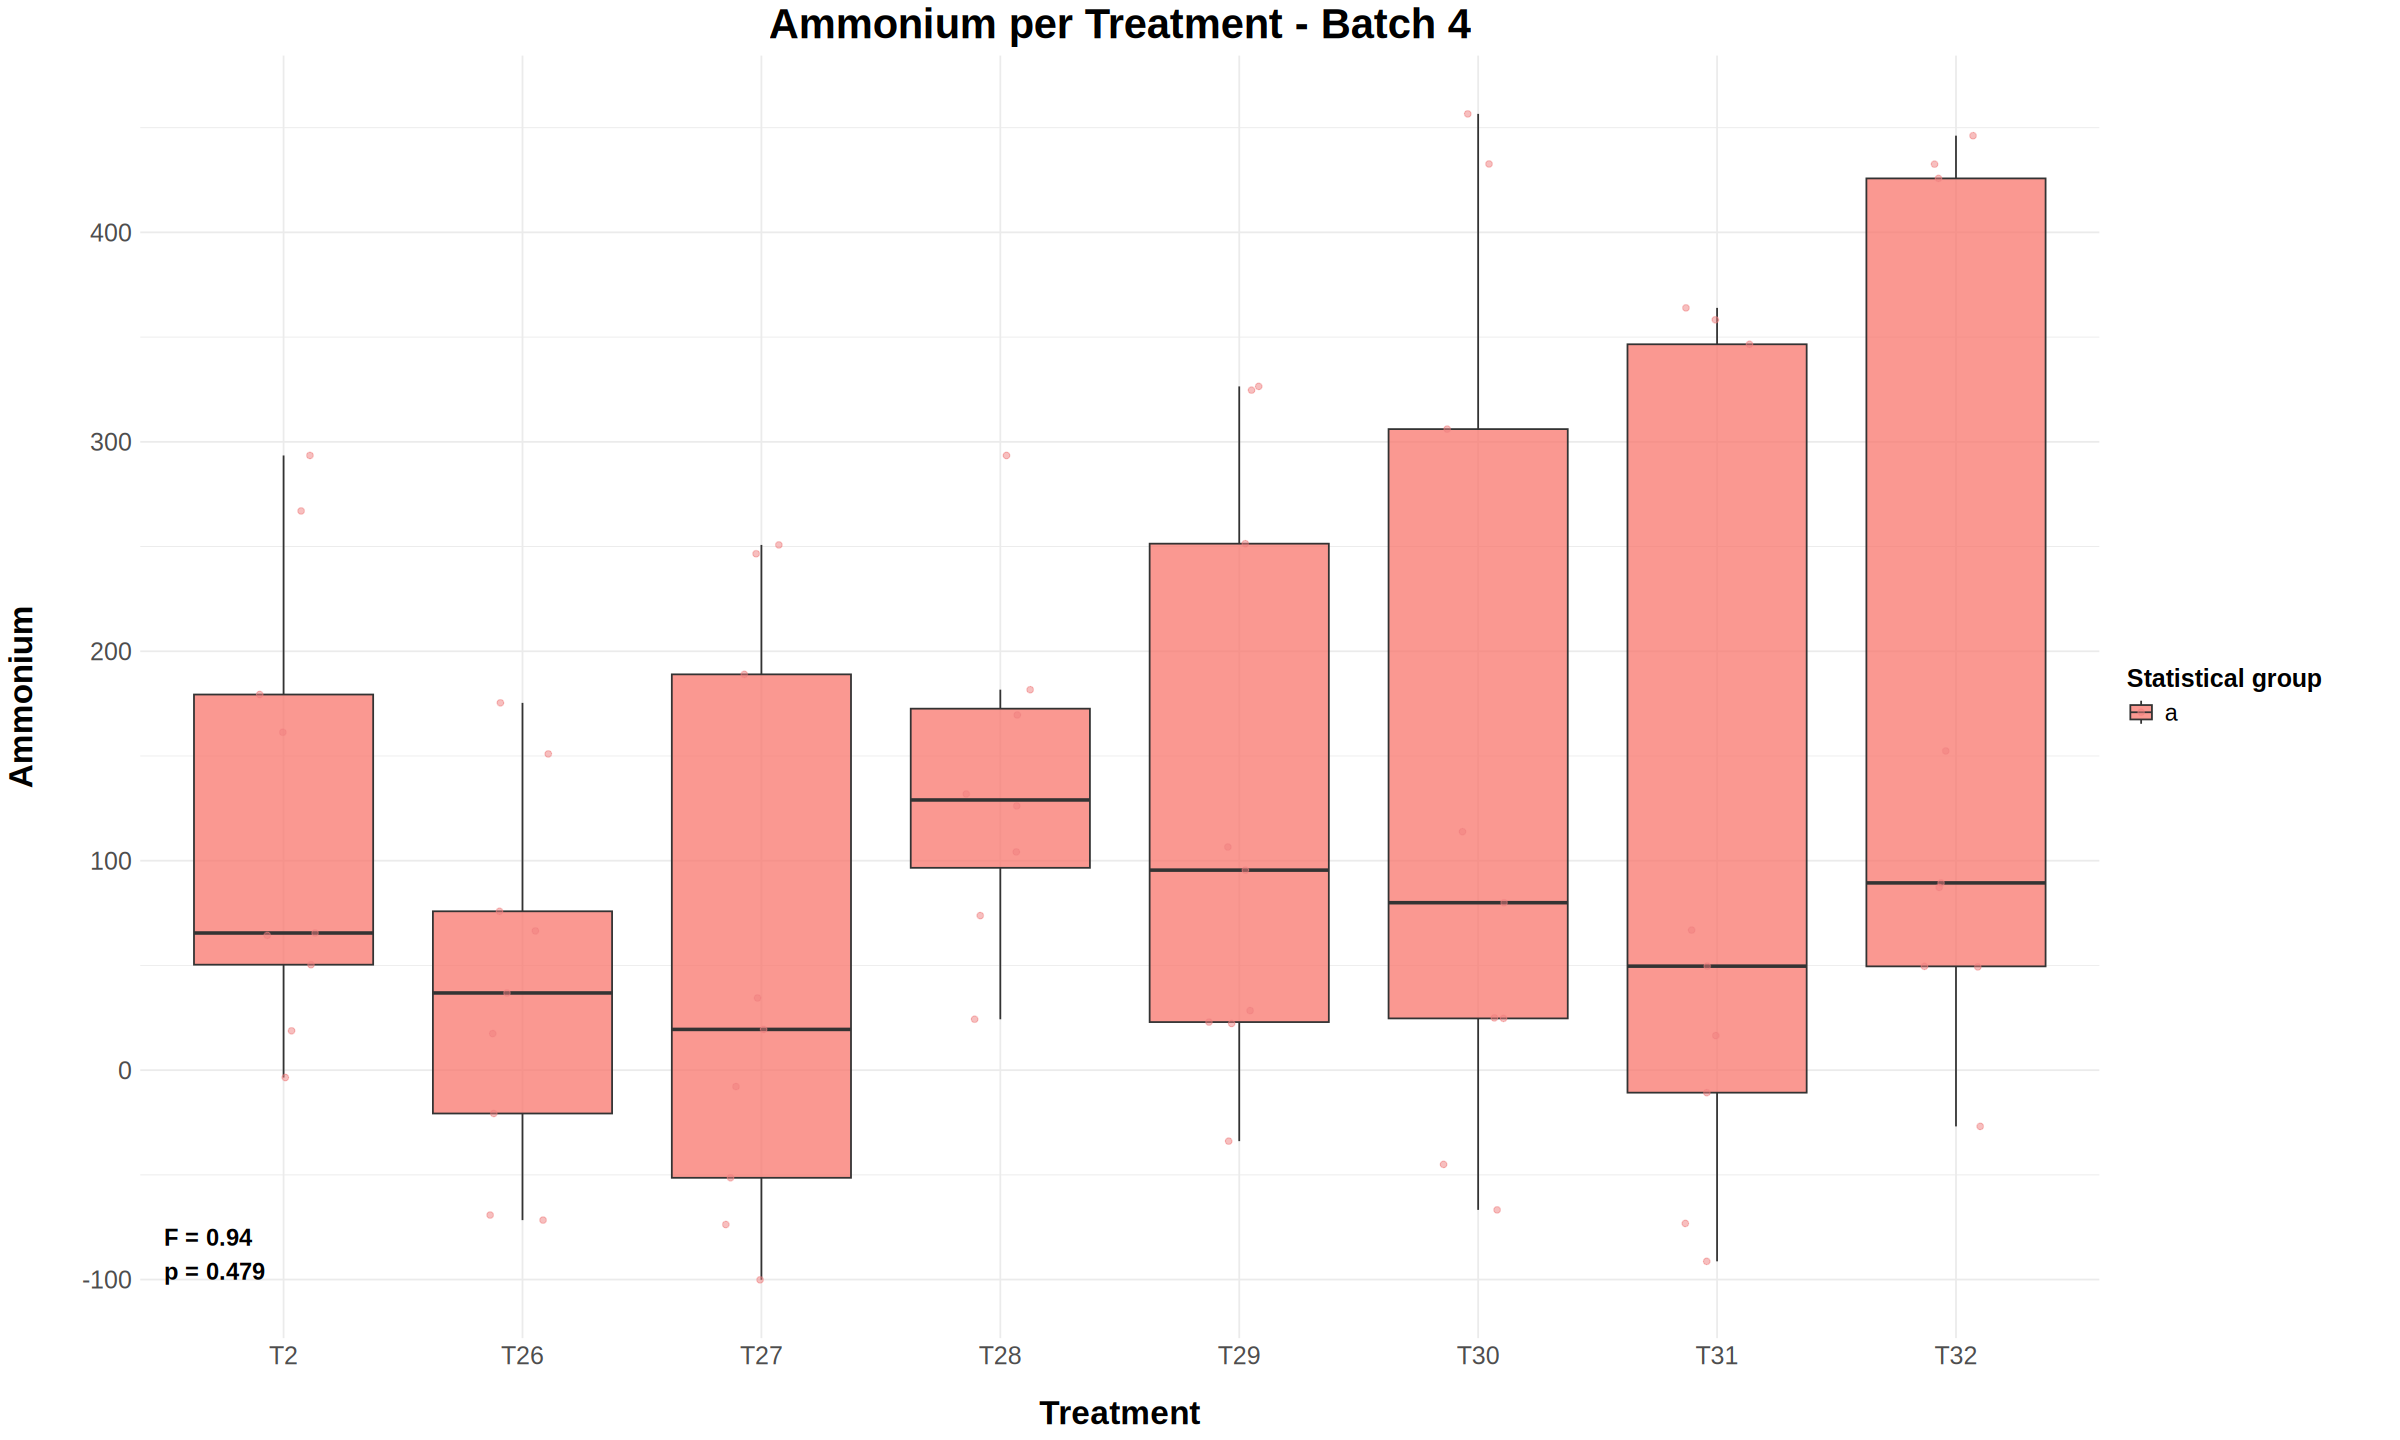

In [50]:
result_batch_4_ammonium <- plot_anova_treatment(
  data = batch_4,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Batch 4",
  y_label = "Ammonium"
)

## 5.4 pH

### 5.4.1 Batch 1

In [62]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"


ANALYSIS: pH per Treatment - Batch 1 

--- ANOVA ---
Analysis of Variance Table

Response: pH
           Df  Sum Sq   Mean Sq F value Pr(>F)
Treatment  14 0.05711 0.0040792  0.4145 0.9678
Residuals 120 1.18104 0.0098420               

--- F VALUE ---
[1] 0.4144623

--- P VALUE ---
[1] 0.96784

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.9879, p-value = 0.2851


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  pH by Treatment
Bartlett's K-squared = 9.5703, df = 14, p-value = 0.7929


--- TUKEY GROUPS ---
   Treatment     mean letter
1         T7 7.294444      a
2         T3 7.292222      a
3         T5 7.282222      a
4         T6 7.280000      a
5         T9 7.277778      a
6         T2 7.276667      a
7        T15 7.273333      a
8        T14 7.268889      a
9        T10 7.264444      a
10        T4 7.258889      a
11       T16 7.252222      a
12        T8 7.247778      a
13       T13 7.245556      a
14       T11 7.

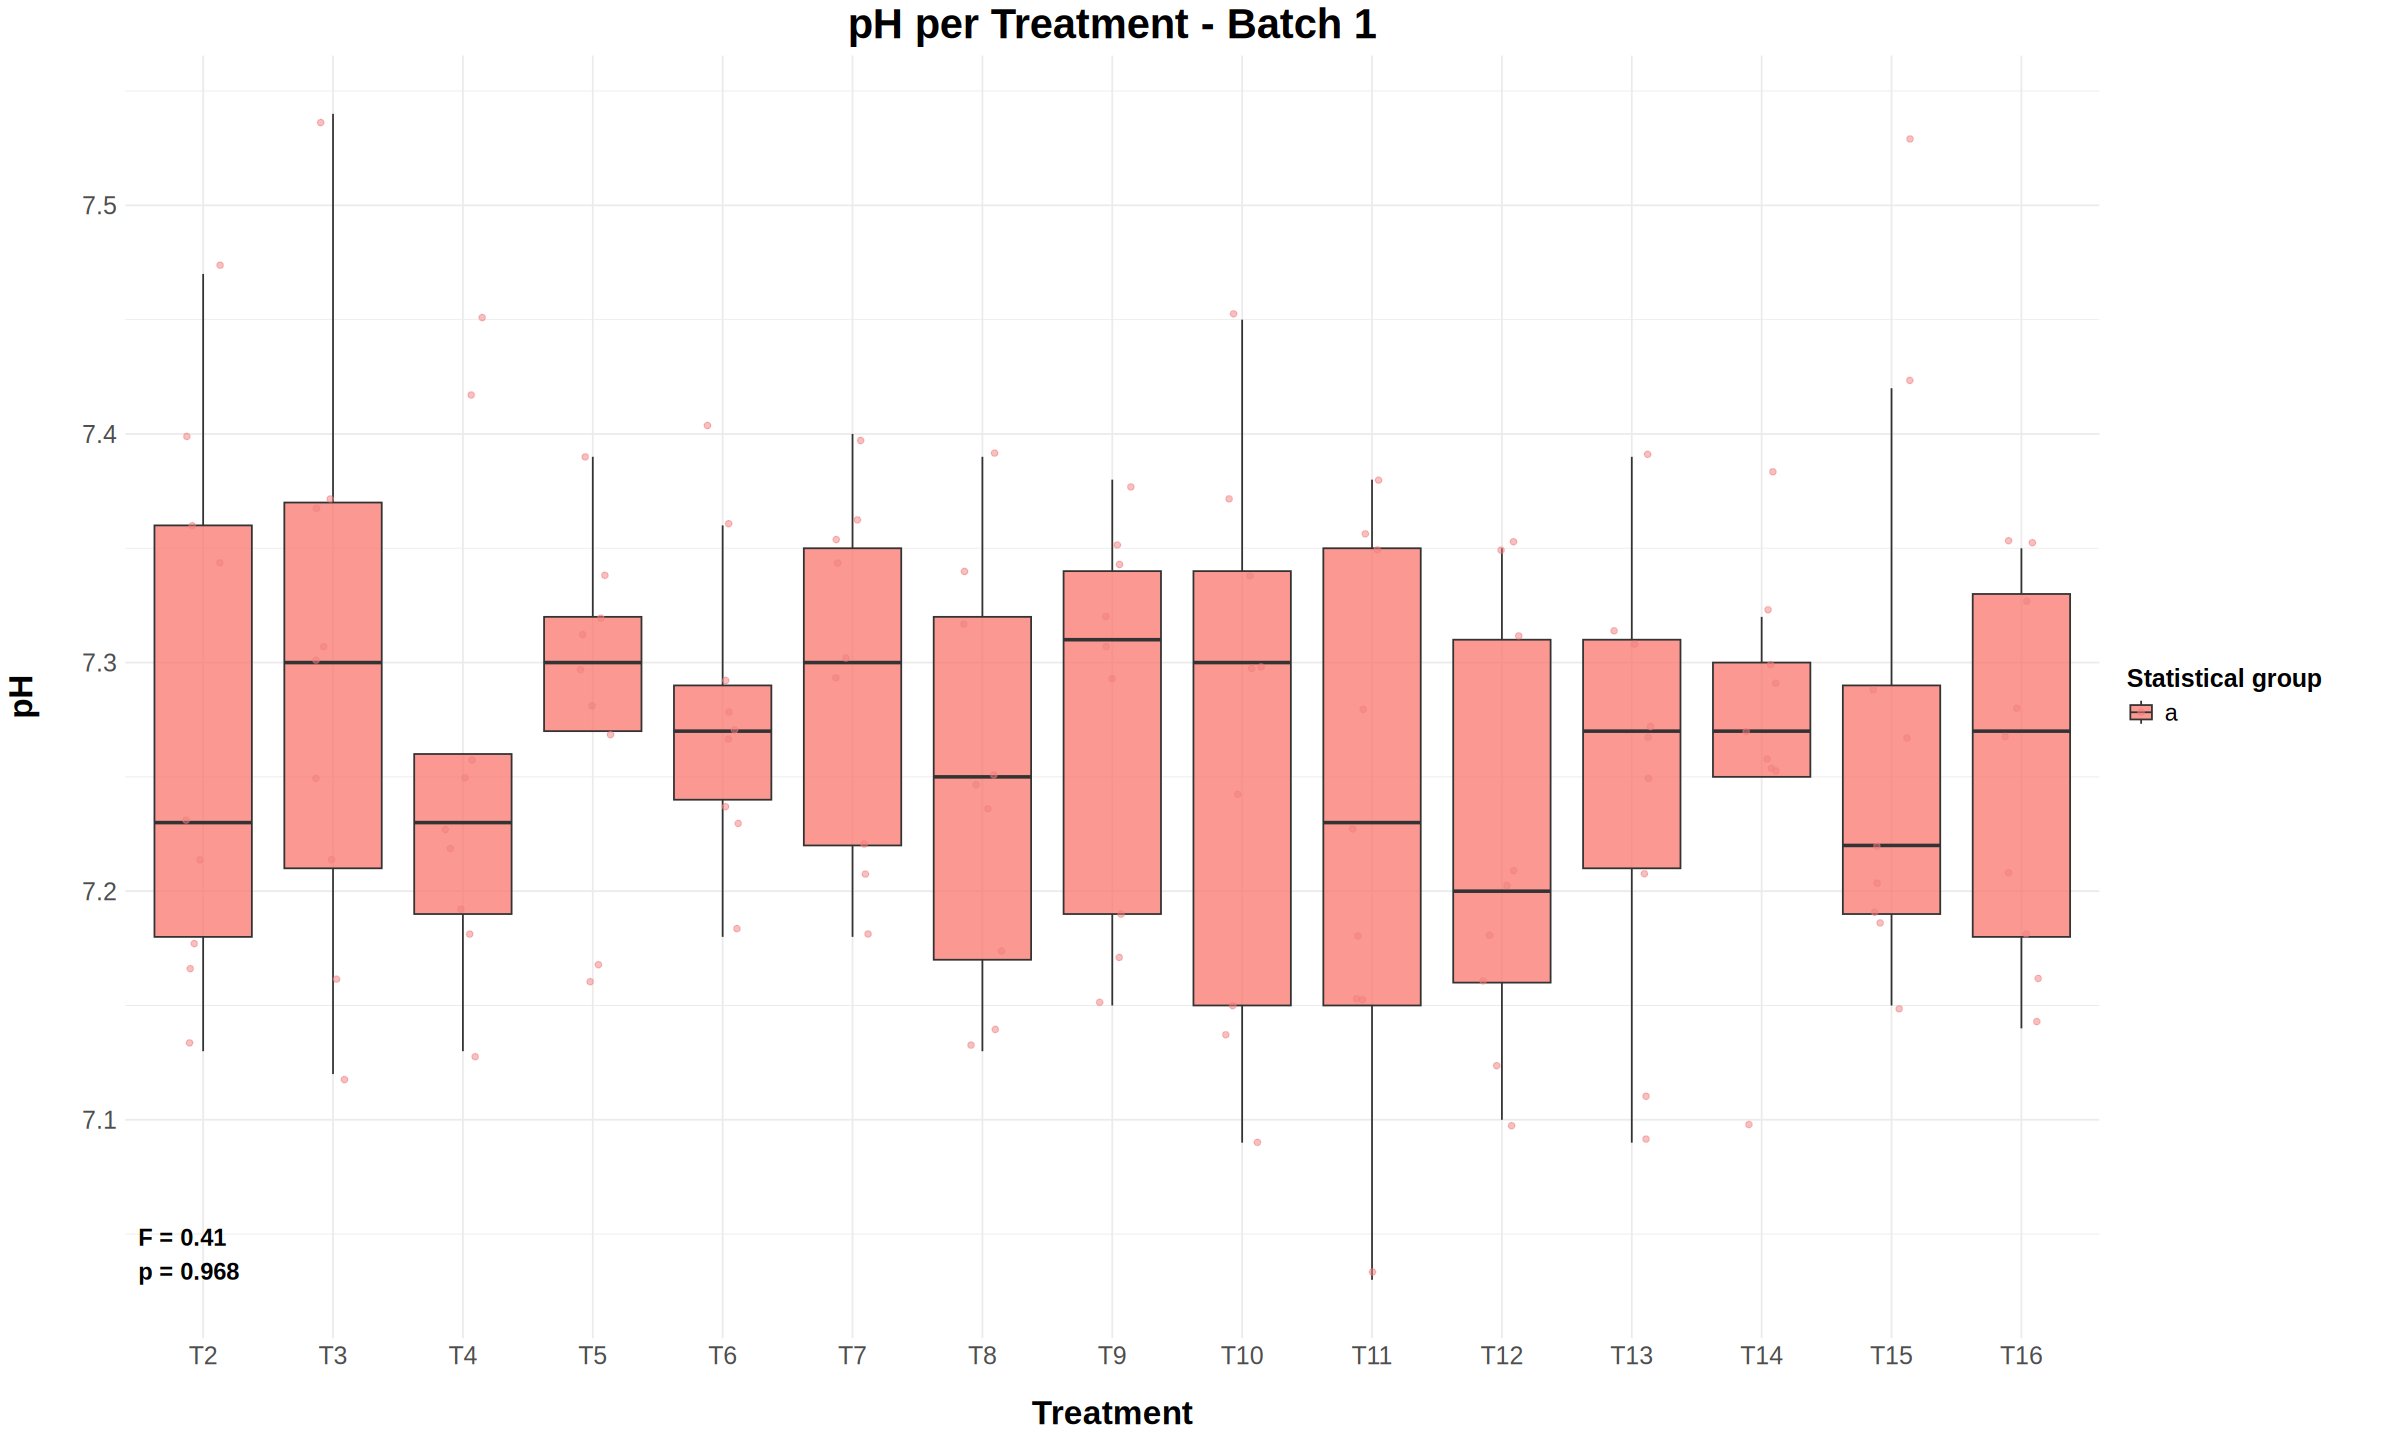

In [51]:
result_batch_1_pH <- plot_anova_treatment(
  data = batch_1,
  variable = "pH",
  title = "pH per Treatment - Batch 1",
  y_label = "pH"
)

### 5.4.2 Batch 2

In [61]:
list_batch_2

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25" "T26" "T27"
[13] "T28" "T29" "T30" "T31" "T32"


ANALYSIS: pH per Treatment - Batch 2 

--- ANOVA ---
Analysis of Variance Table

Response: pH
           Df  Sum Sq  Mean Sq F value Pr(>F)
Treatment  16 0.31817 0.019886  1.1886 0.2847
Residuals 136 2.27524 0.016730               

--- F VALUE ---
[1] 1.188629

--- P VALUE ---
[1] 0.2846774

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.99362, p-value = 0.7381


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  pH by Treatment
Bartlett's K-squared = 30.549, df = 16, p-value = 0.01535


--- TUKEY GROUPS ---
   Treatment     mean letter
1        T25 7.371111      a
2        T27 7.328889      a
3        T32 7.324444      a
4        T29 7.323333      a
5        T24 7.321111      a
6        T22 7.316667      a
7        T26 7.295556      a
8        T28 7.295556      a
9        T17 7.284444      a
10        T2 7.276667      a
11       T23 7.276667      a
12       T21 7.268889      a
13       T18 7.263333      a
14       T30 7.

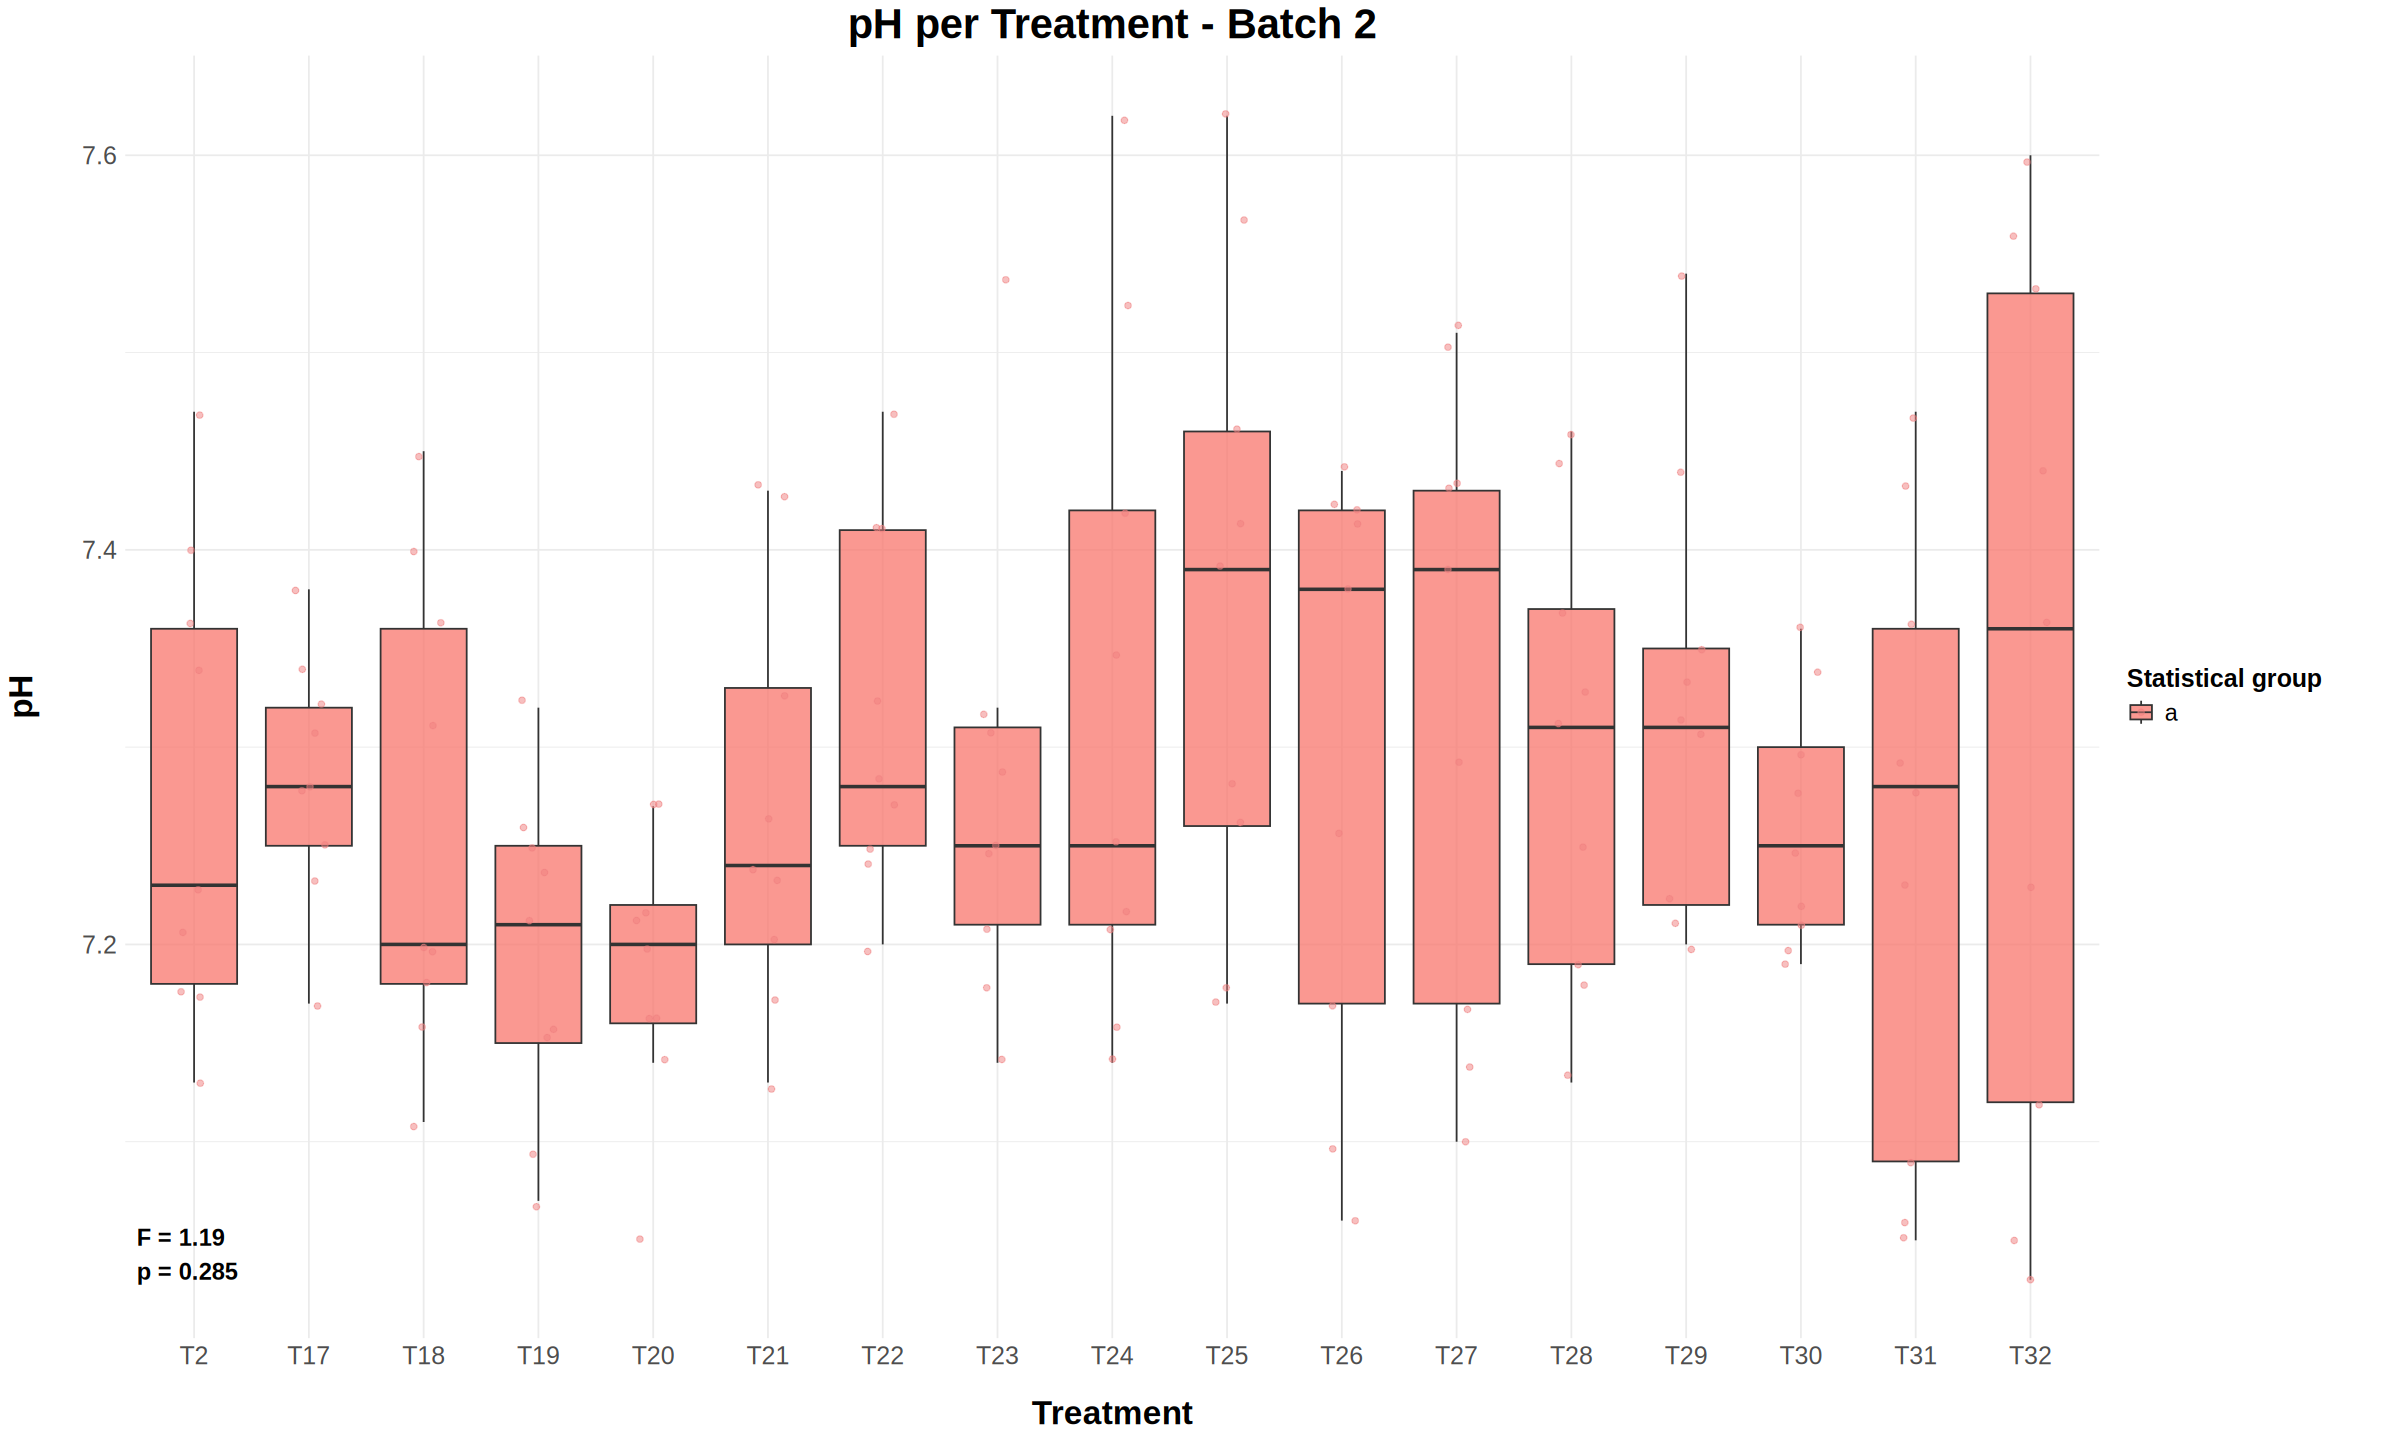

In [52]:
result_batch_2_pH <- plot_anova_treatment(
  data = batch_2,
  variable = "pH",
  title = "pH per Treatment - Batch 2",
  y_label = "pH"
)

### 5.4.3 Batch 3

In [60]:
list_batch_3

[1] "T2"  "T17" "T18" "T19" "T20" "T21" "T22" "T23" "T24" "T25"


ANALYSIS: pH per Treatment - Batch 3 

--- ANOVA ---
Analysis of Variance Table

Response: pH
          Df  Sum Sq  Mean Sq F value  Pr(>F)  
Treatment  9 0.24885 0.027650  2.1016 0.03882 *
Residuals 80 1.05251 0.013156                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 2.101631

--- P VALUE ---
[1] 0.03881794

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.97544, p-value = 0.08603


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  pH by Treatment
Bartlett's K-squared = 14.041, df = 9, p-value = 0.1209


--- TUKEY GROUPS ---
   Treatment     mean letter
1        T25 7.371111      a
2        T24 7.321111     ab
3        T22 7.316667     ab
4        T17 7.284444     ab
5         T2 7.276667     ab
6        T23 7.276667     ab
7        T21 7.268889     ab
8        T18 7.263333     ab
9        T19 7.194444      b
10       T20 7.186667      b


--- BOXPLOT ---



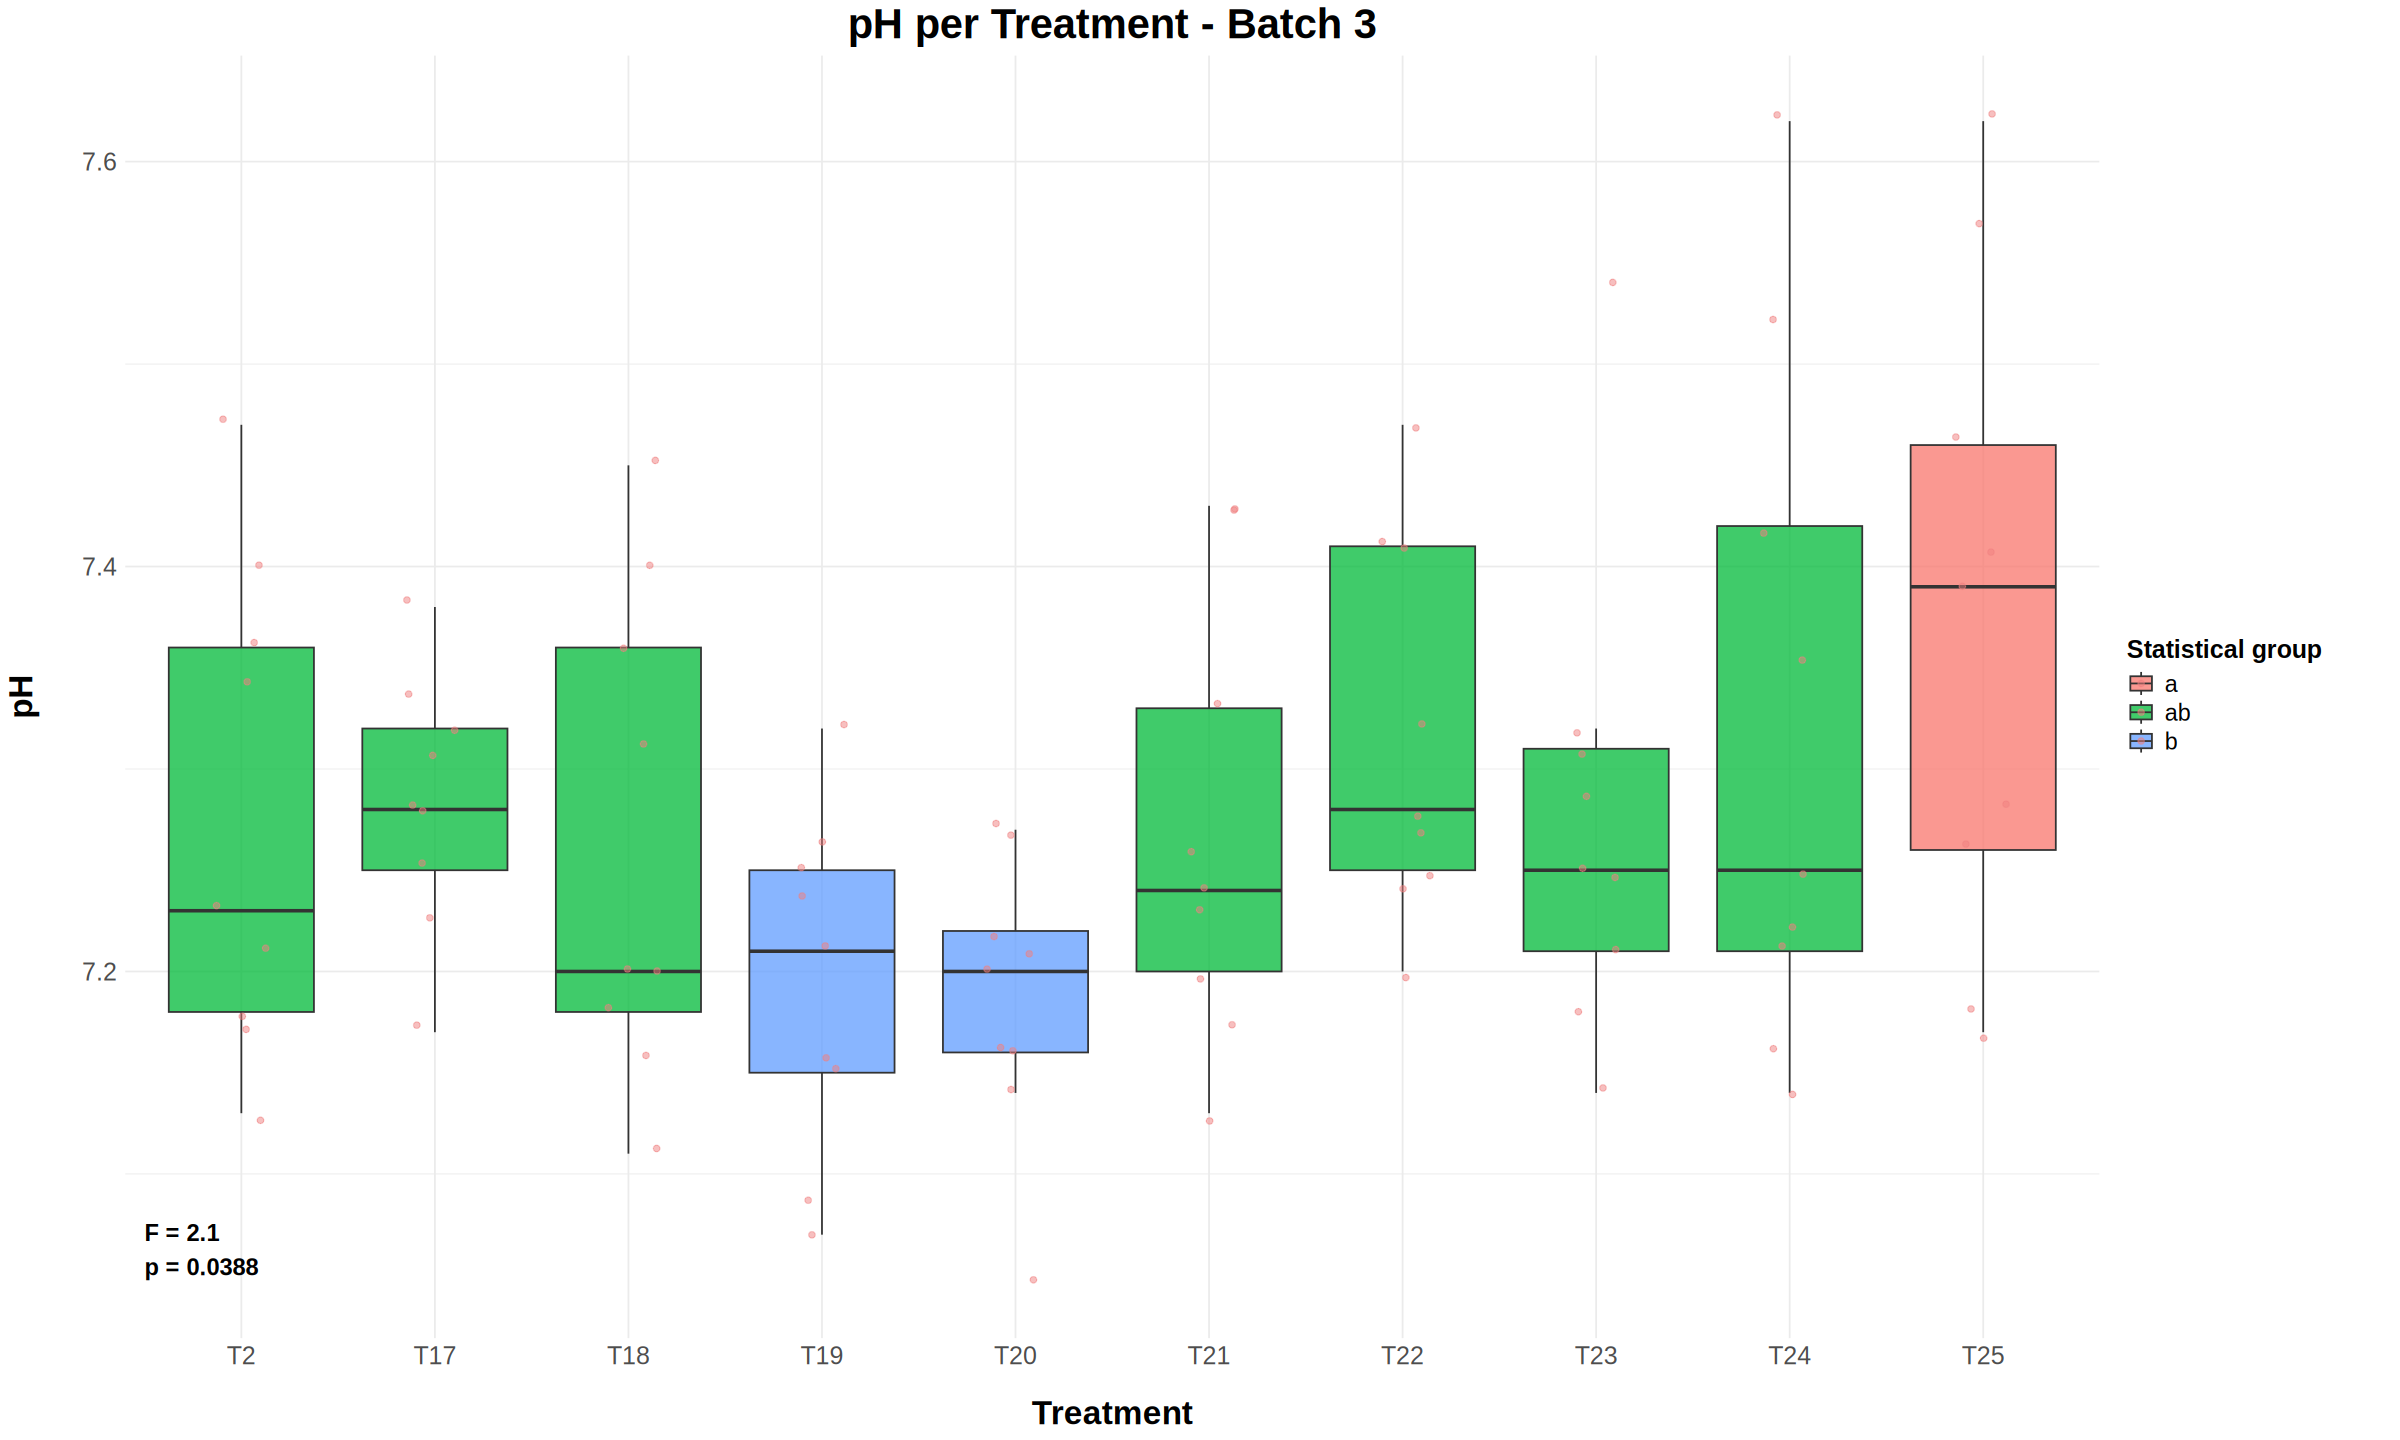

In [53]:
result_batch_3_pH <- plot_anova_treatment(
  data = batch_3,
  variable = "pH",
  title = "pH per Treatment - Batch 3",
  y_label = "pH"
)

### 5.3.4  Batch 4

In [59]:
list_batch_4

[1] "T2"  "T26" "T27" "T28" "T29" "T30" "T31" "T32"


ANALYSIS: pH per Treatment - Batch 4 

--- ANOVA ---
Analysis of Variance Table

Response: pH
          Df  Sum Sq   Mean Sq F value Pr(>F)
Treatment  7 0.05605 0.0080077  0.3839 0.9085
Residuals 64 1.33513 0.0208615               

--- F VALUE ---
[1] 0.3838532

--- P VALUE ---
[1] 0.9085214

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.98141, p-value = 0.3658


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  pH by Treatment
Bartlett's K-squared = 12.907, df = 7, p-value = 0.07441


--- TUKEY GROUPS ---
  Treatment     mean letter
1       T27 7.328889      a
2       T32 7.324444      a
3       T29 7.323333      a
4       T26 7.295556      a
5       T28 7.295556      a
6        T2 7.276667      a
7       T30 7.261111      a
8       T31 7.251111      a


--- BOXPLOT ---



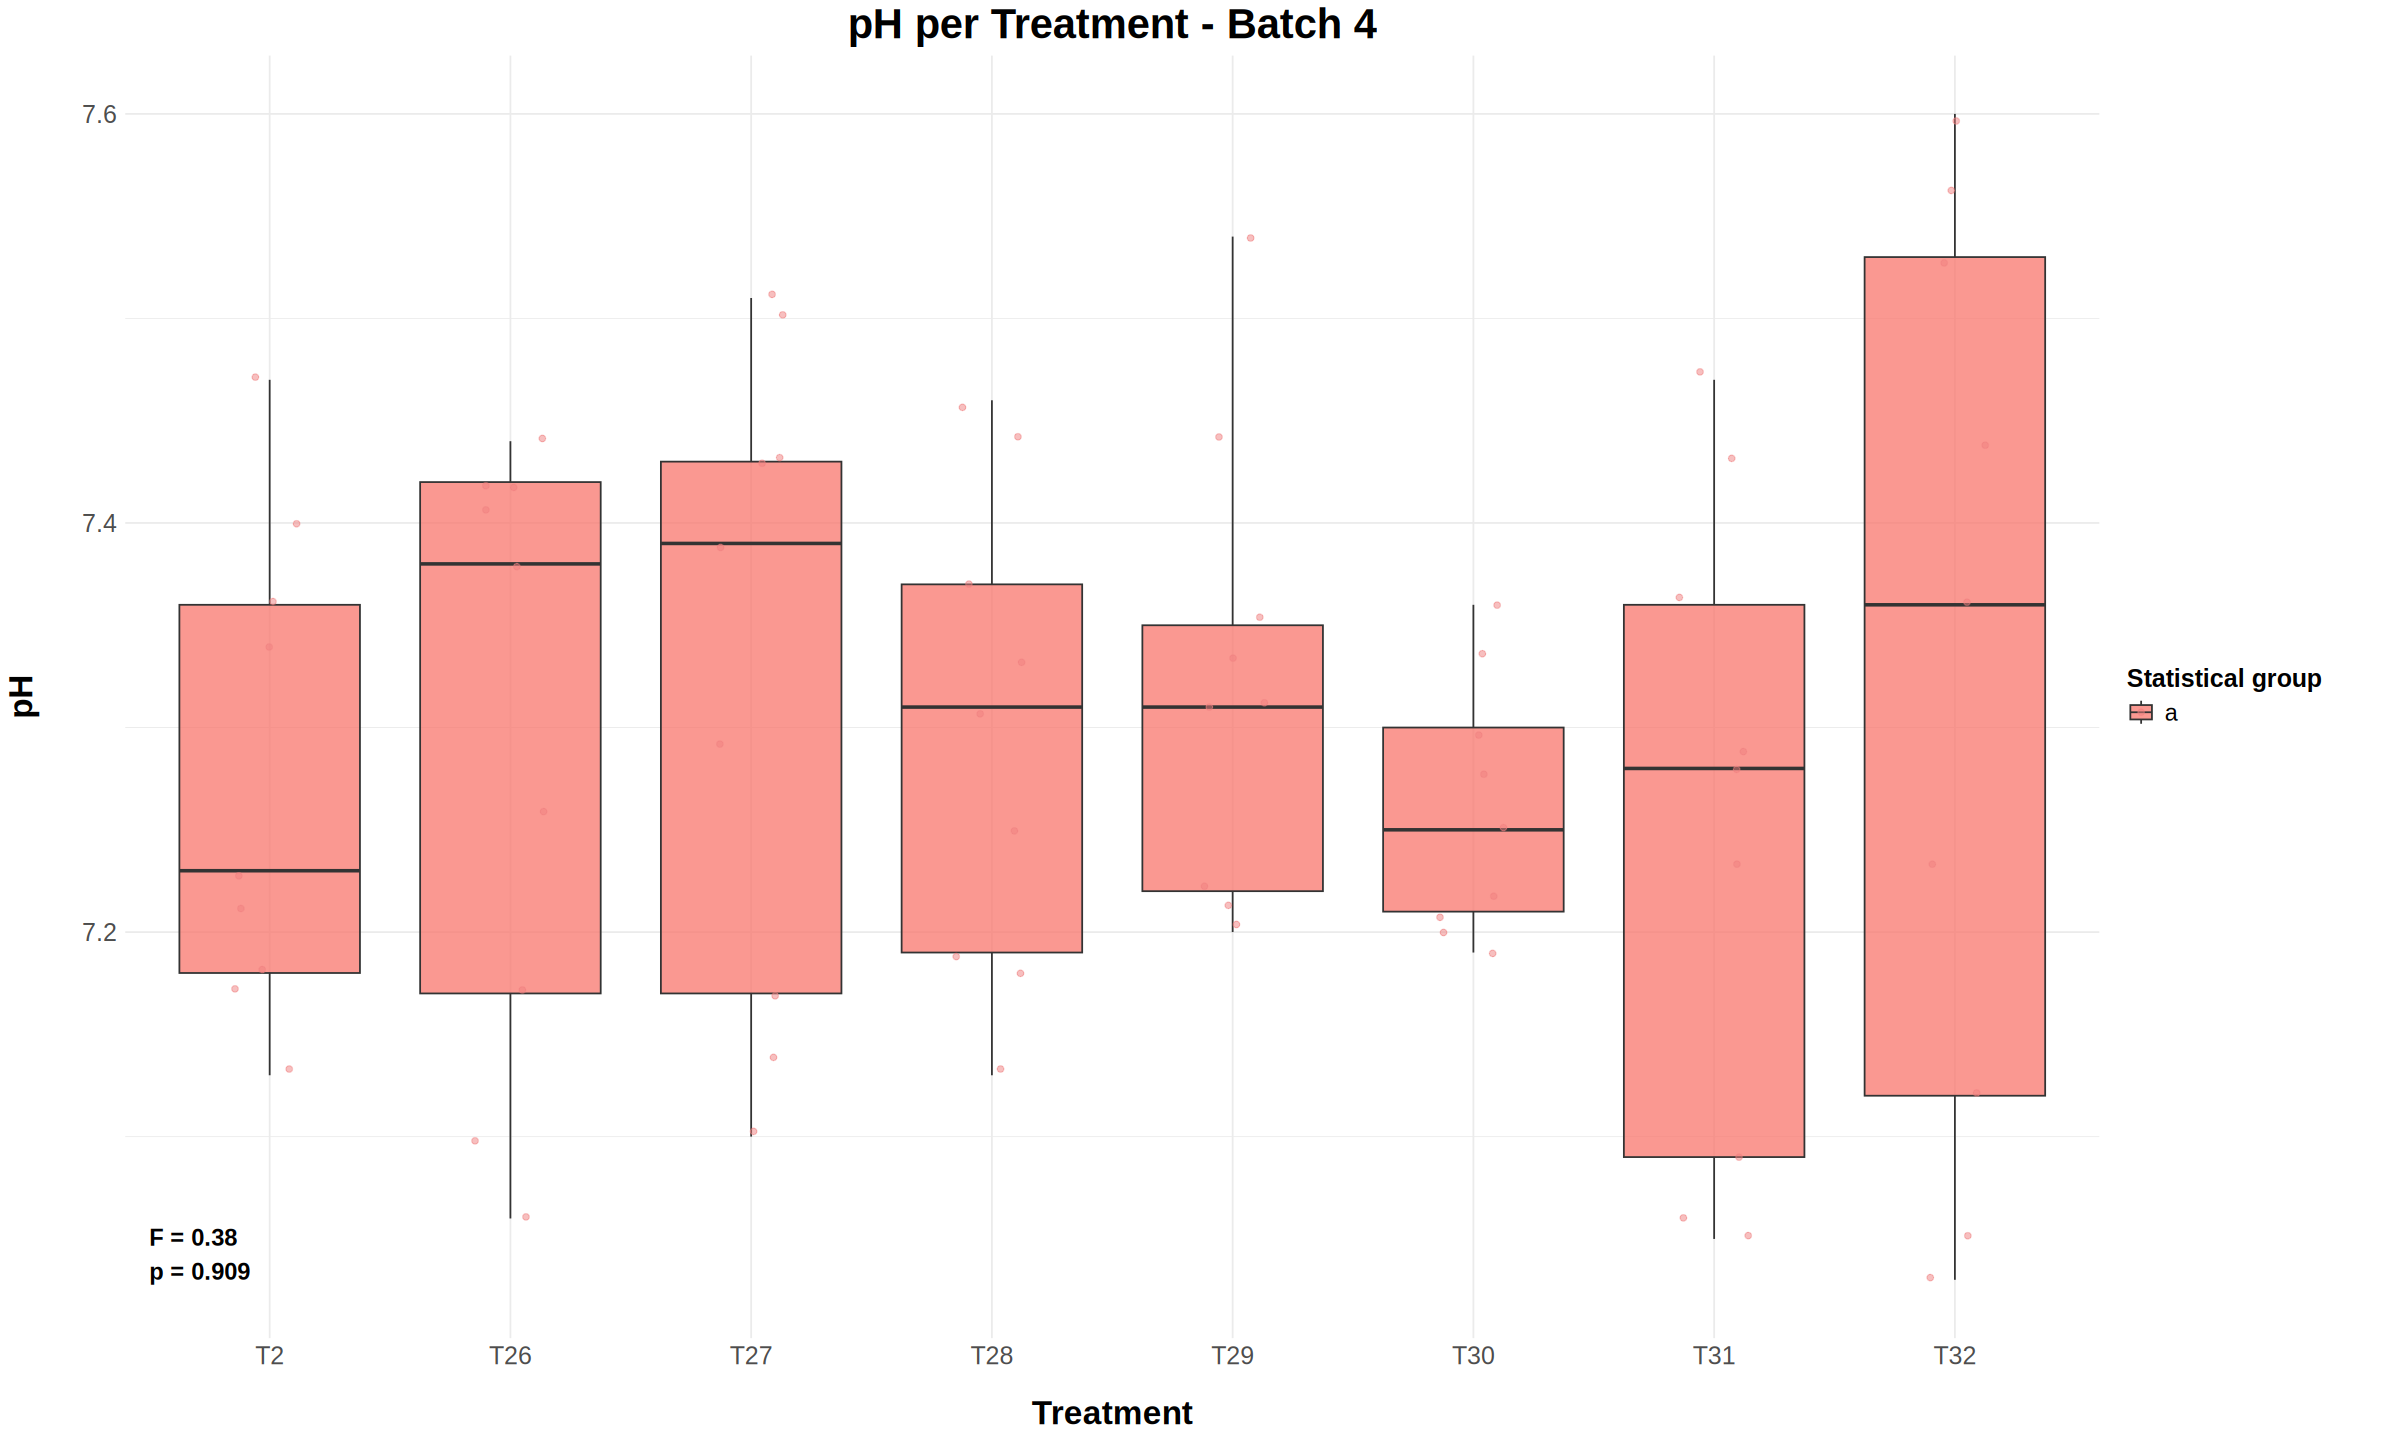

In [54]:
result_batch_4_pH <- plot_anova_treatment(
  data = batch_4,
  variable = "pH",
  title = "pH per Treatment - Batch 4",
  y_label = "pH"
)

# 6.0 Averaged data

## 6.1 Batch 1

In [58]:
list_batch_1

[1] "T2"  "T3"  "T4"  "T5"  "T6"  "T7"  "T8"  "T9"  "T10" "T11" "T12" "T13"
[13] "T14" "T15" "T16"

In [80]:
batch_1_table <- batch_1 %>% group_by(Treatment) %>%
  summarise(
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
batch_1_table

Treatment,Methane_intensity_average,TDDM_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T2,56.34,66.82,121.84,7.28
T3,56.66,64.78,288.49,7.29
T4,51.32,68.29,193.50,7.26
T5,55.33,67.10,106.86,7.28
T6,58.67,63.98,146.22,7.28
T7,57.77,64.22,130.52,7.29
T8,54.86,65.67,190.84,7.25
T9,54.62,64.02,233.16,7.28
T10,54.59,66.14,175.02,7.26


## 6.2 Batch 2

In [81]:
batch_2_table <- batch_2 %>% group_by(Treatment) %>%
  summarise(
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
batch_2_table

Treatment,Methane_intensity_average,TDDM_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T2,56.34,66.82,121.84,7.28
T17,49.21,68.63,111.28,7.28
T18,44.56,68.52,120.70,7.26
T19,49.07,69.28,127.45,7.19
T20,47.32,69.99,106.49,7.19
T21,44.89,66.23,81.19,7.27
T22,48.20,68.97,22.36,7.32
T23,37.82,66.42,16.64,7.28
T24,52.16,69.80,52.23,7.32


## 6.3 Batch 3

In [82]:
batch_3_table <- batch_3 %>% group_by(Treatment) %>%
  summarise(
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
batch_3_table

Treatment,Methane_intensity_average,TDDM_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T2,56.34,66.82,121.84,7.28
T17,49.21,68.63,111.28,7.28
T18,44.56,68.52,120.70,7.26
T19,49.07,69.28,127.45,7.19
T20,47.32,69.99,106.49,7.19
T21,44.89,66.23,81.19,7.27
T22,48.20,68.97,22.36,7.32
T23,37.82,66.42,16.64,7.28
T24,52.16,69.80,52.23,7.32


## 6.4 Batch 4

In [83]:
batch_4_table <- batch_4 %>% group_by(Treatment) %>%
  summarise(
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
batch_4_table

Treatment,Methane_intensity_average,TDDM_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T2,56.34,66.82,121.84,7.28
T26,48.33,69.66,40.16,7.30
T27,25.58,67.89,56.35,7.33
T28,48.30,68.30,138.12,7.30
T29,50.78,66.76,127.15,7.32
T30,44.59,65.46,147.45,7.26
T31,53.60,64.20,114.06,7.25
T32,33.61,65.04,189.51,7.32


# 7.0 Best treatments comparison

In [100]:
list_best_treatments  <- c("T2", "T4", "T11", "T9", "T16")
best_treatments <- df %>% dplyr::filter(Treatment %in% list_best_treatments)
best_treatments$Treatment <- factor(best_treatments$Treatment, levels = list_best_treatments)

## 7.1 TDDM %


ANALYSIS: TDDM (%) per Treatment - Best Treatments 

--- ANOVA ---
Analysis of Variance Table

Response: TDDM_percentage
          Df Sum Sq Mean Sq F value  Pr(>F)  
Treatment  4 115.83  28.958  2.3535 0.07021 .
Residuals 40 492.18  12.304                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 2.353459

--- P VALUE ---
[1] 0.07020888

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.97061, p-value = 0.3047


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  TDDM_percentage by Treatment
Bartlett's K-squared = 0.74324, df = 4, p-value = 0.9459


--- TUKEY GROUPS ---
  Treatment     mean letter
1       T11 68.32222      a
2        T4 68.28889      a
3       T16 67.75556      a
4        T2 66.82222      a
5        T9 64.02222      a


--- BOXPLOT ---



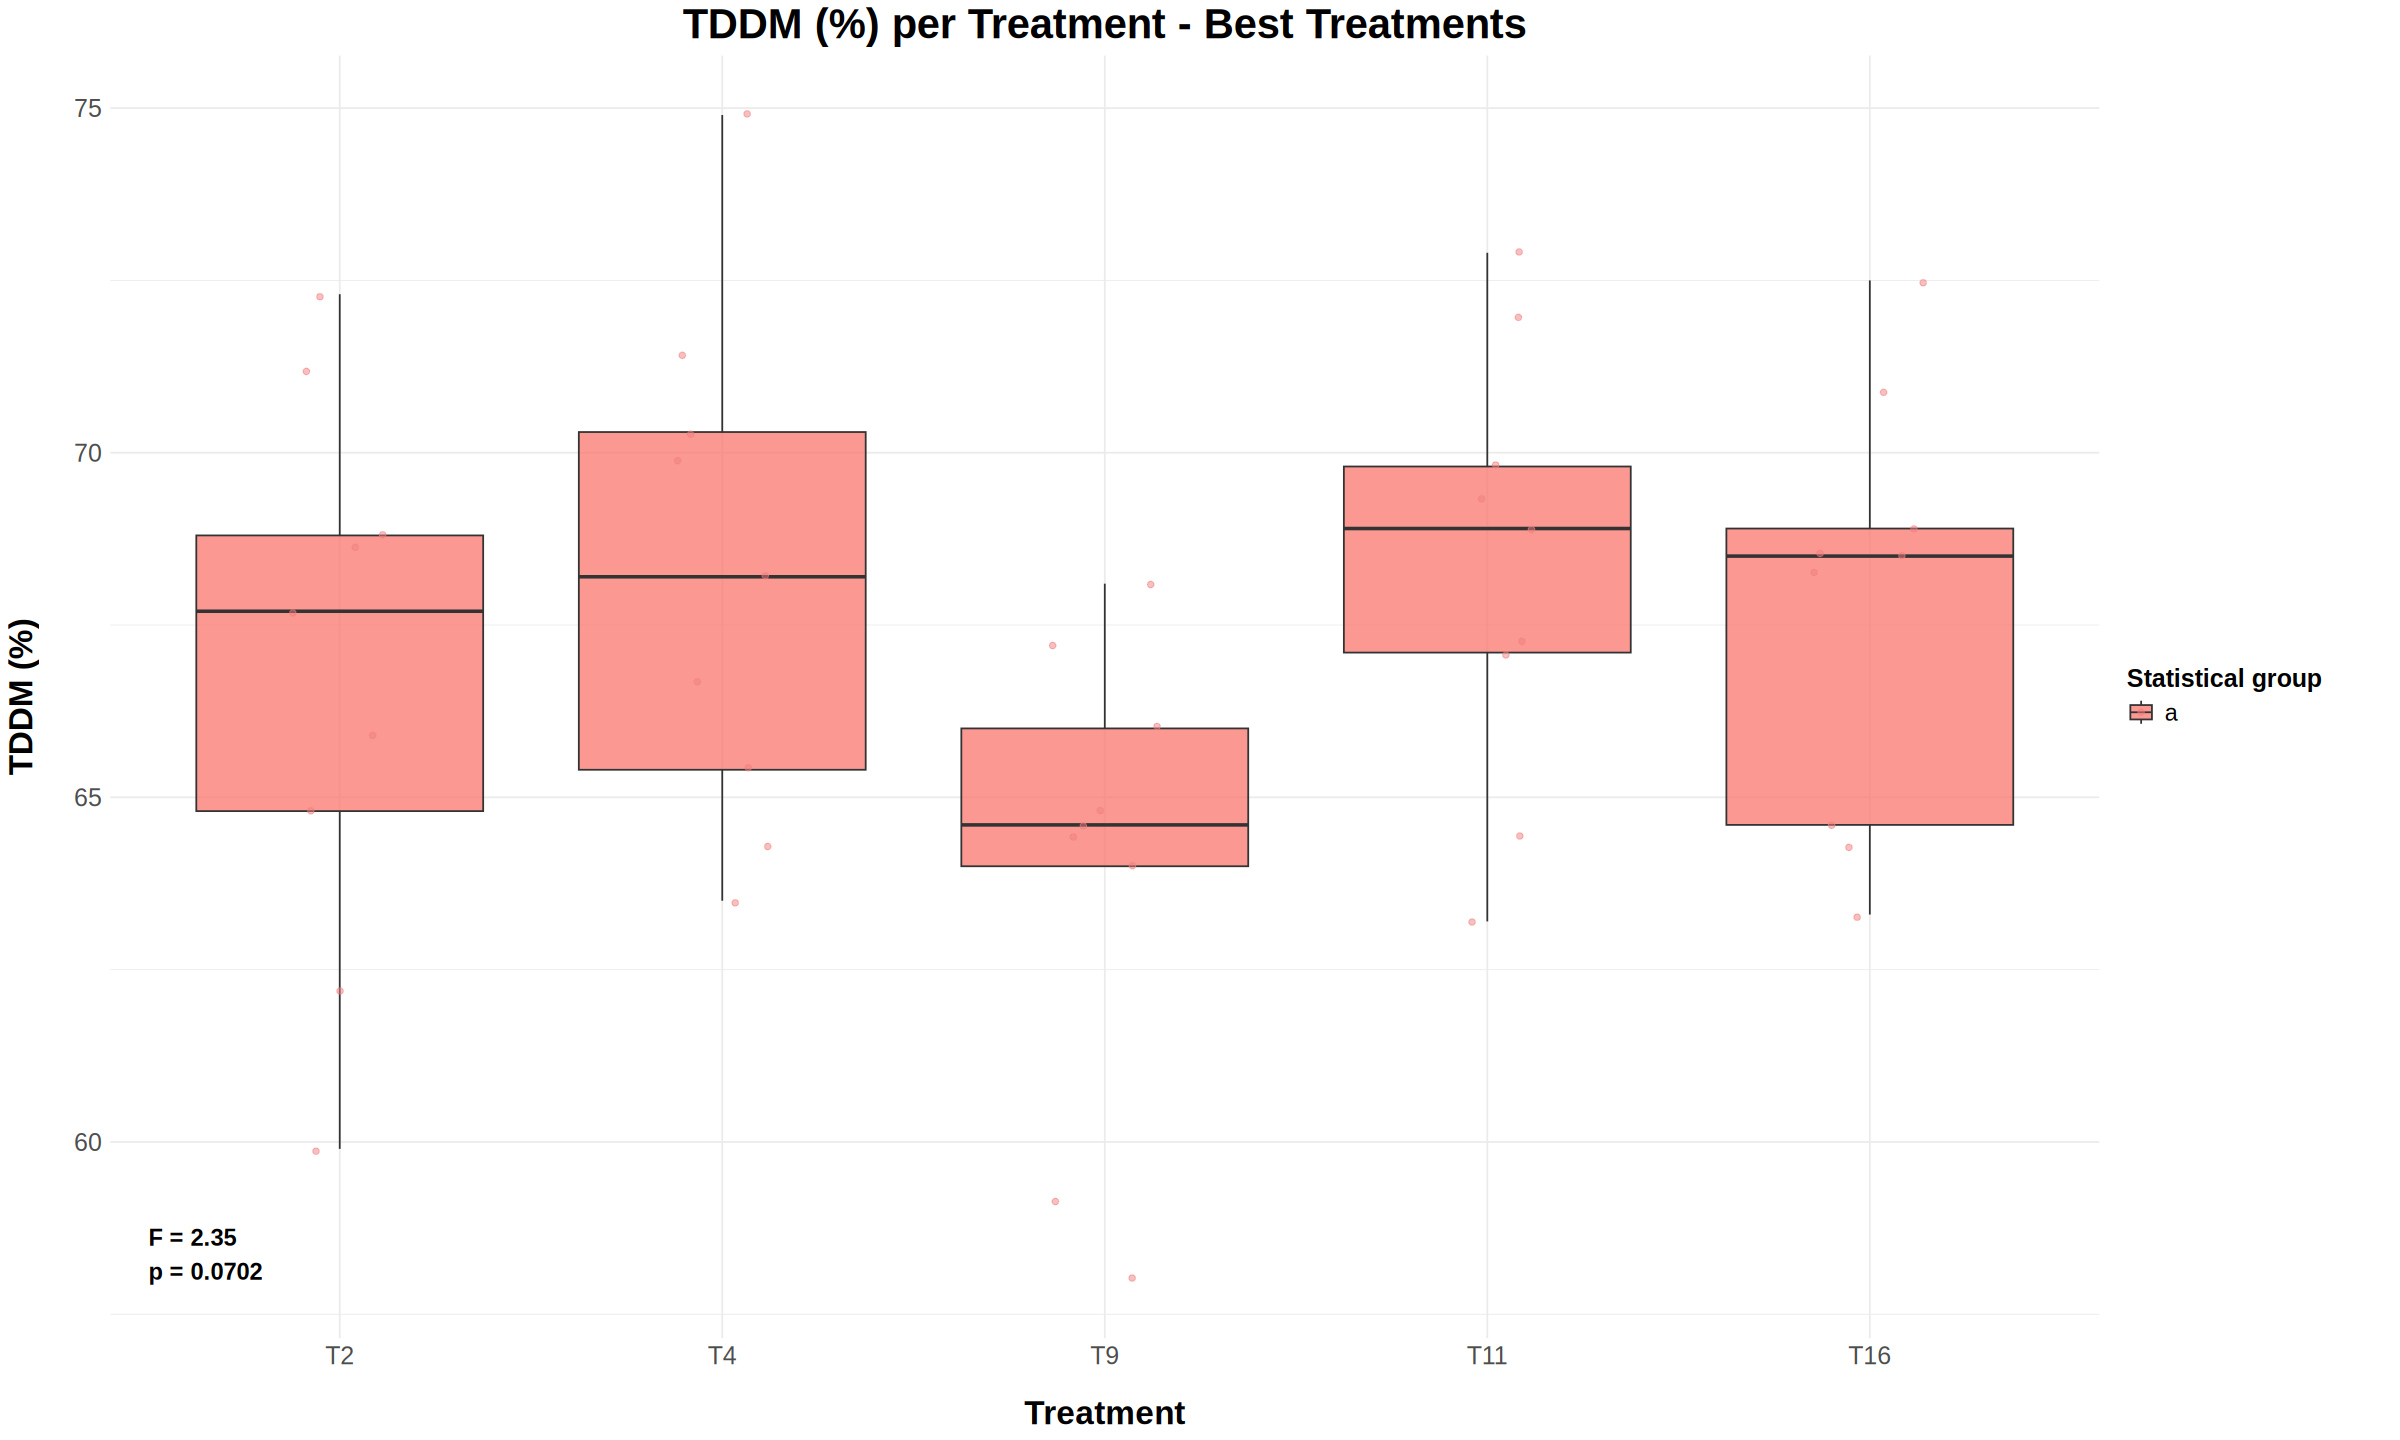

In [101]:
result_best_treatments_tddm <- plot_anova_treatment(
  data = best_treatments,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Best Treatments",
  y_label = "TDDM (%)"
)

## 7.2 Methane Intensity


ANALYSIS: Methane Intensity per Treatment - Best Treatments 

--- ANOVA ---
Analysis of Variance Table

Response: CH4_ml_g_DMD_24h
          Df  Sum Sq Mean Sq F value    Pr(>F)    
Treatment  4 1242.90 310.726  18.475 1.138e-08 ***
Residuals 40  672.75  16.819                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 18.475

--- P VALUE ---
[1] 1.137935e-08

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.98443, p-value = 0.7983


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  CH4_ml_g_DMD_24h by Treatment
Bartlett's K-squared = 5.735, df = 4, p-value = 0.2198


--- TUKEY GROUPS ---
  Treatment     mean letter
1        T2 56.34444      a
2        T9 54.62222      a
3        T4 51.32222      a
4       T11 44.63333      b
5       T16 43.22222      b


--- BOXPLOT ---



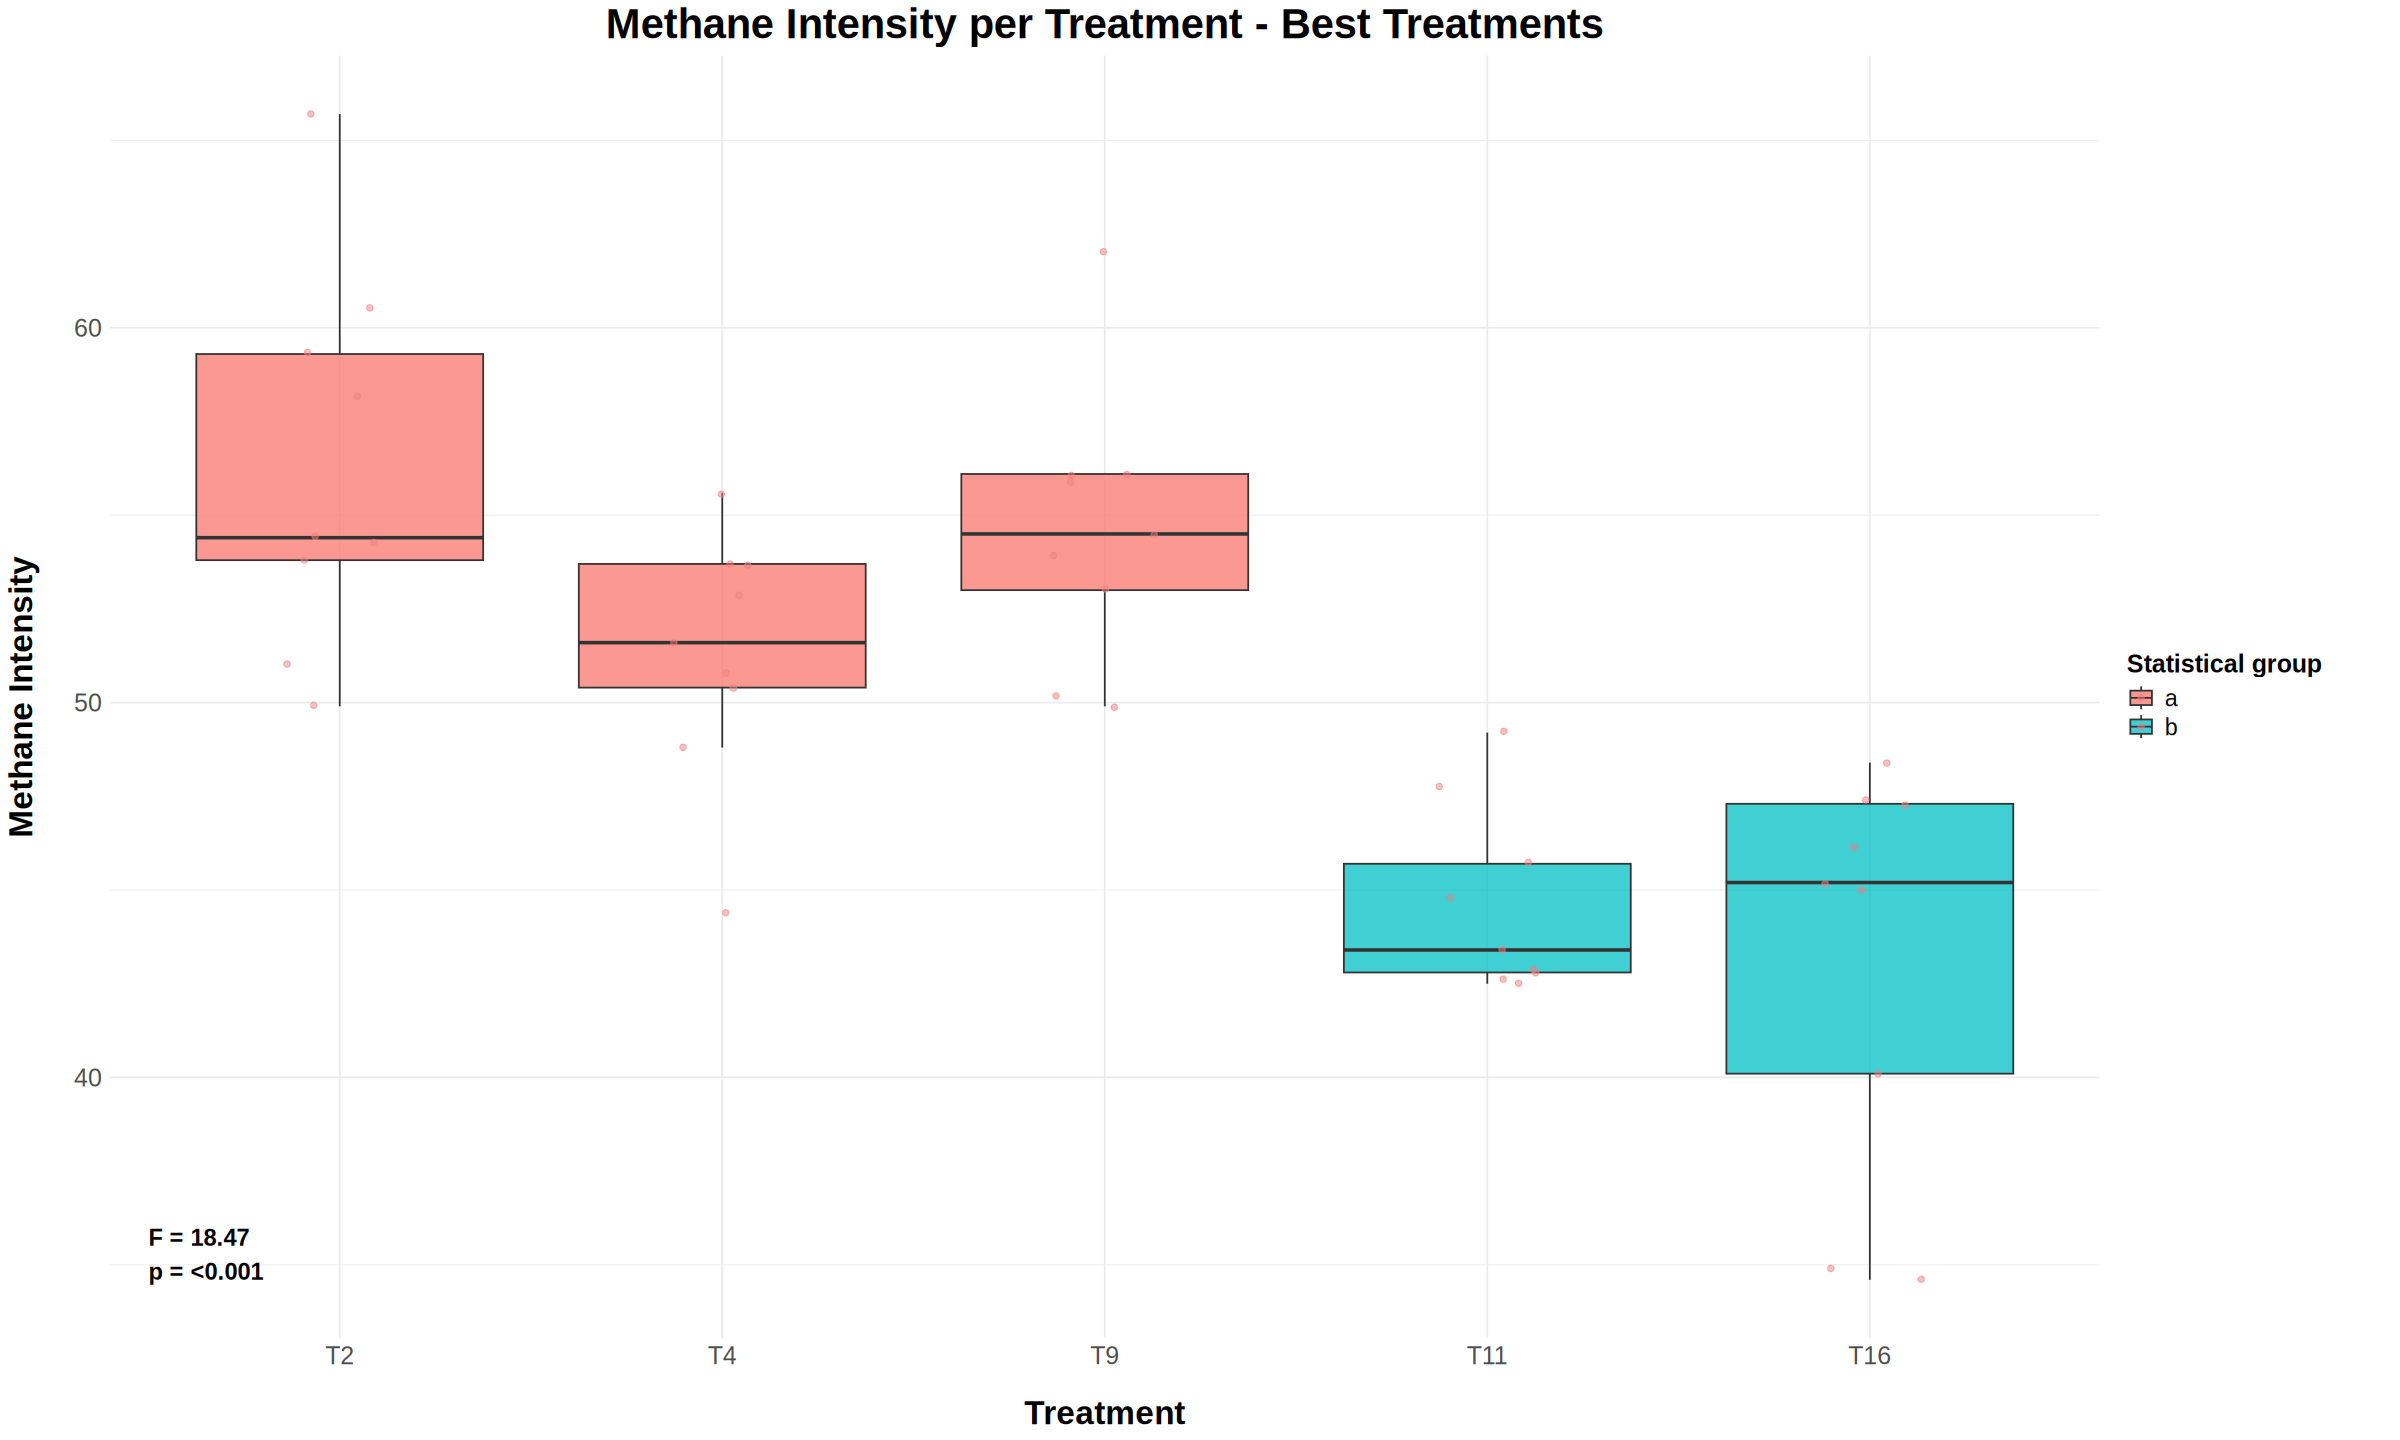

In [102]:
result_best_treatments_methane_intensity <- plot_anova_treatment(
  data = best_treatments,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Best Treatments",
  y_label = "Methane Intensity"
)

## 7.3 Ammonium


ANALYSIS: Ammonium per Treatment - Best Treatments 

--- ANOVA ---
Analysis of Variance Table

Response: Amonio_corregido_ppm
          Df Sum Sq Mean Sq F value  Pr(>F)  
Treatment  4  87468 21867.1  2.7222 0.04279 *
Residuals 40 321315  8032.9                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 2.722201

--- P VALUE ---
[1] 0.04279012

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.95425, p-value = 0.07366


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  Amonio_corregido_ppm by Treatment
Bartlett's K-squared = 9.1568, df = 4, p-value = 0.0573


--- TUKEY GROUPS ---
  Treatment     mean letter
1        T9 233.1639      a
2       T11 204.1417      a
3        T4 193.4972      a
4       T16 126.8083      a
5        T2 121.8417      a


--- BOXPLOT ---



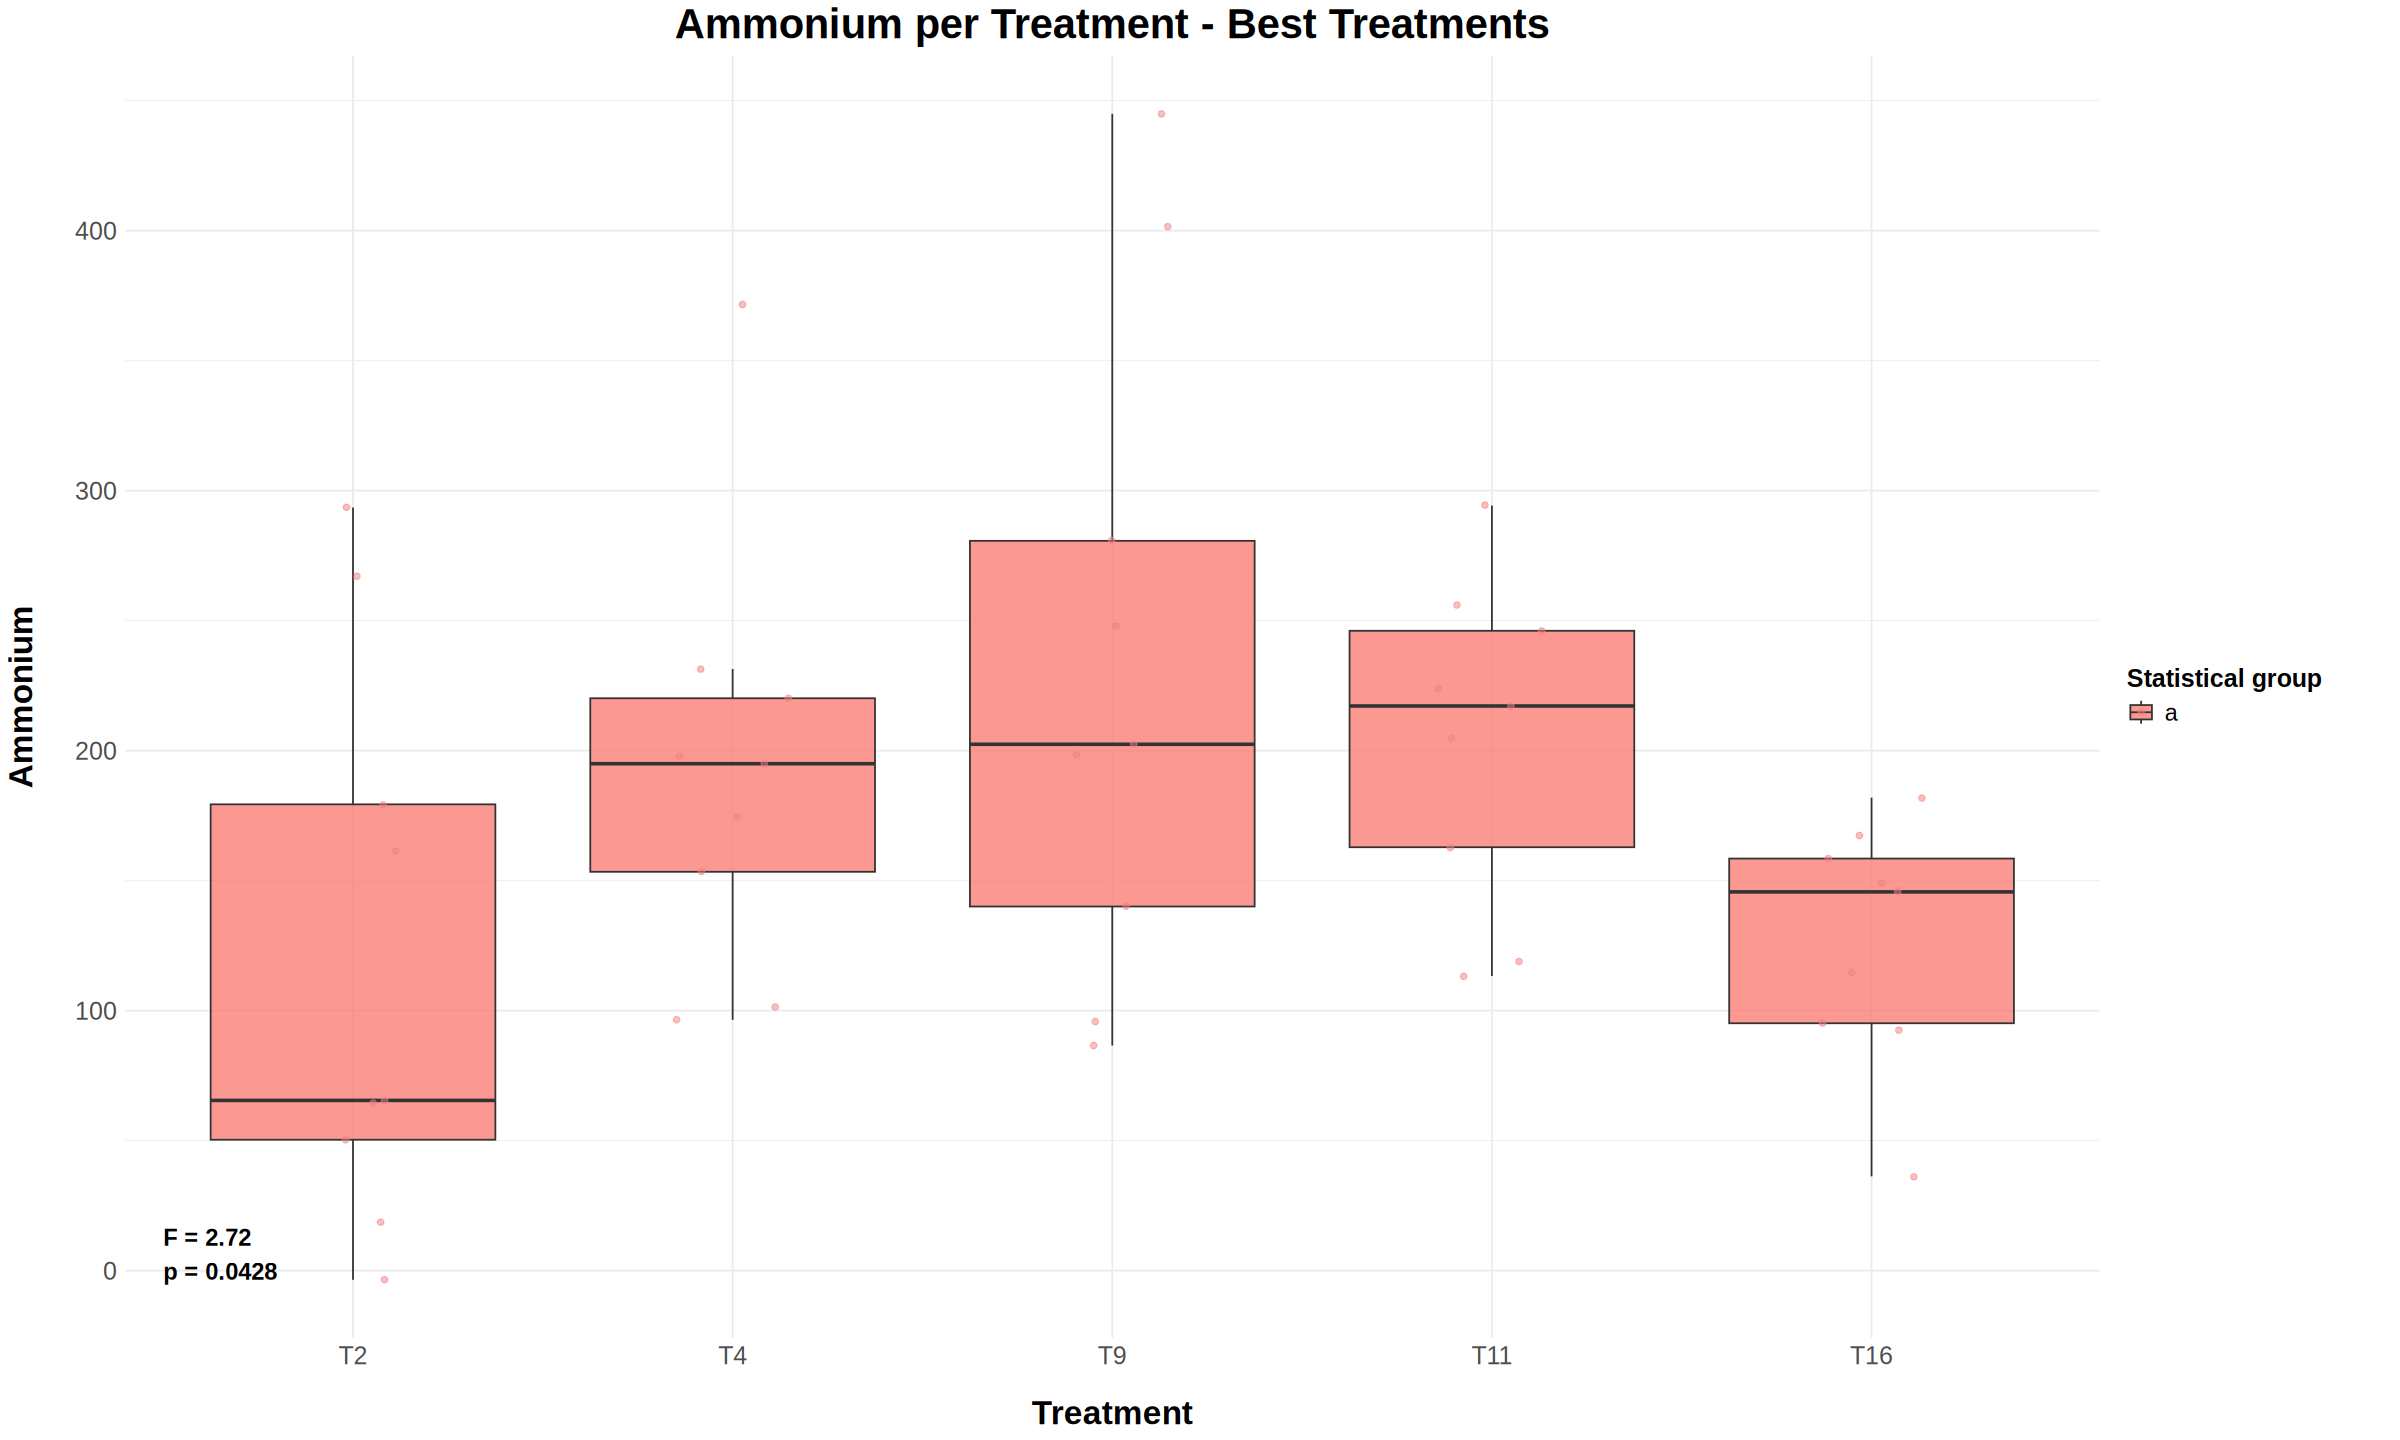

In [103]:
result_best_treatments_ammonium <- plot_anova_treatment(
  data = best_treatments,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Best Treatments",
  y_label = "Ammonium"
)

## 7.4 pH


ANALYSIS: pH per Treatment - Best Treatments 

--- ANOVA ---
Analysis of Variance Table

Response: pH
          Df  Sum Sq   Mean Sq F value Pr(>F)
Treatment  4 0.01178 0.0029444  0.2747 0.8926
Residuals 40 0.42882 0.0107206               

--- F VALUE ---
[1] 0.2746541

--- P VALUE ---
[1] 0.8926022

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.97112, p-value = 0.3177


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  pH by Treatment
Bartlett's K-squared = 1.8048, df = 4, p-value = 0.7716


--- TUKEY GROUPS ---
  Treatment     mean letter
1        T9 7.277778      a
2        T2 7.276667      a
3        T4 7.258889      a
4       T16 7.252222      a
5       T11 7.234444      a


--- BOXPLOT ---



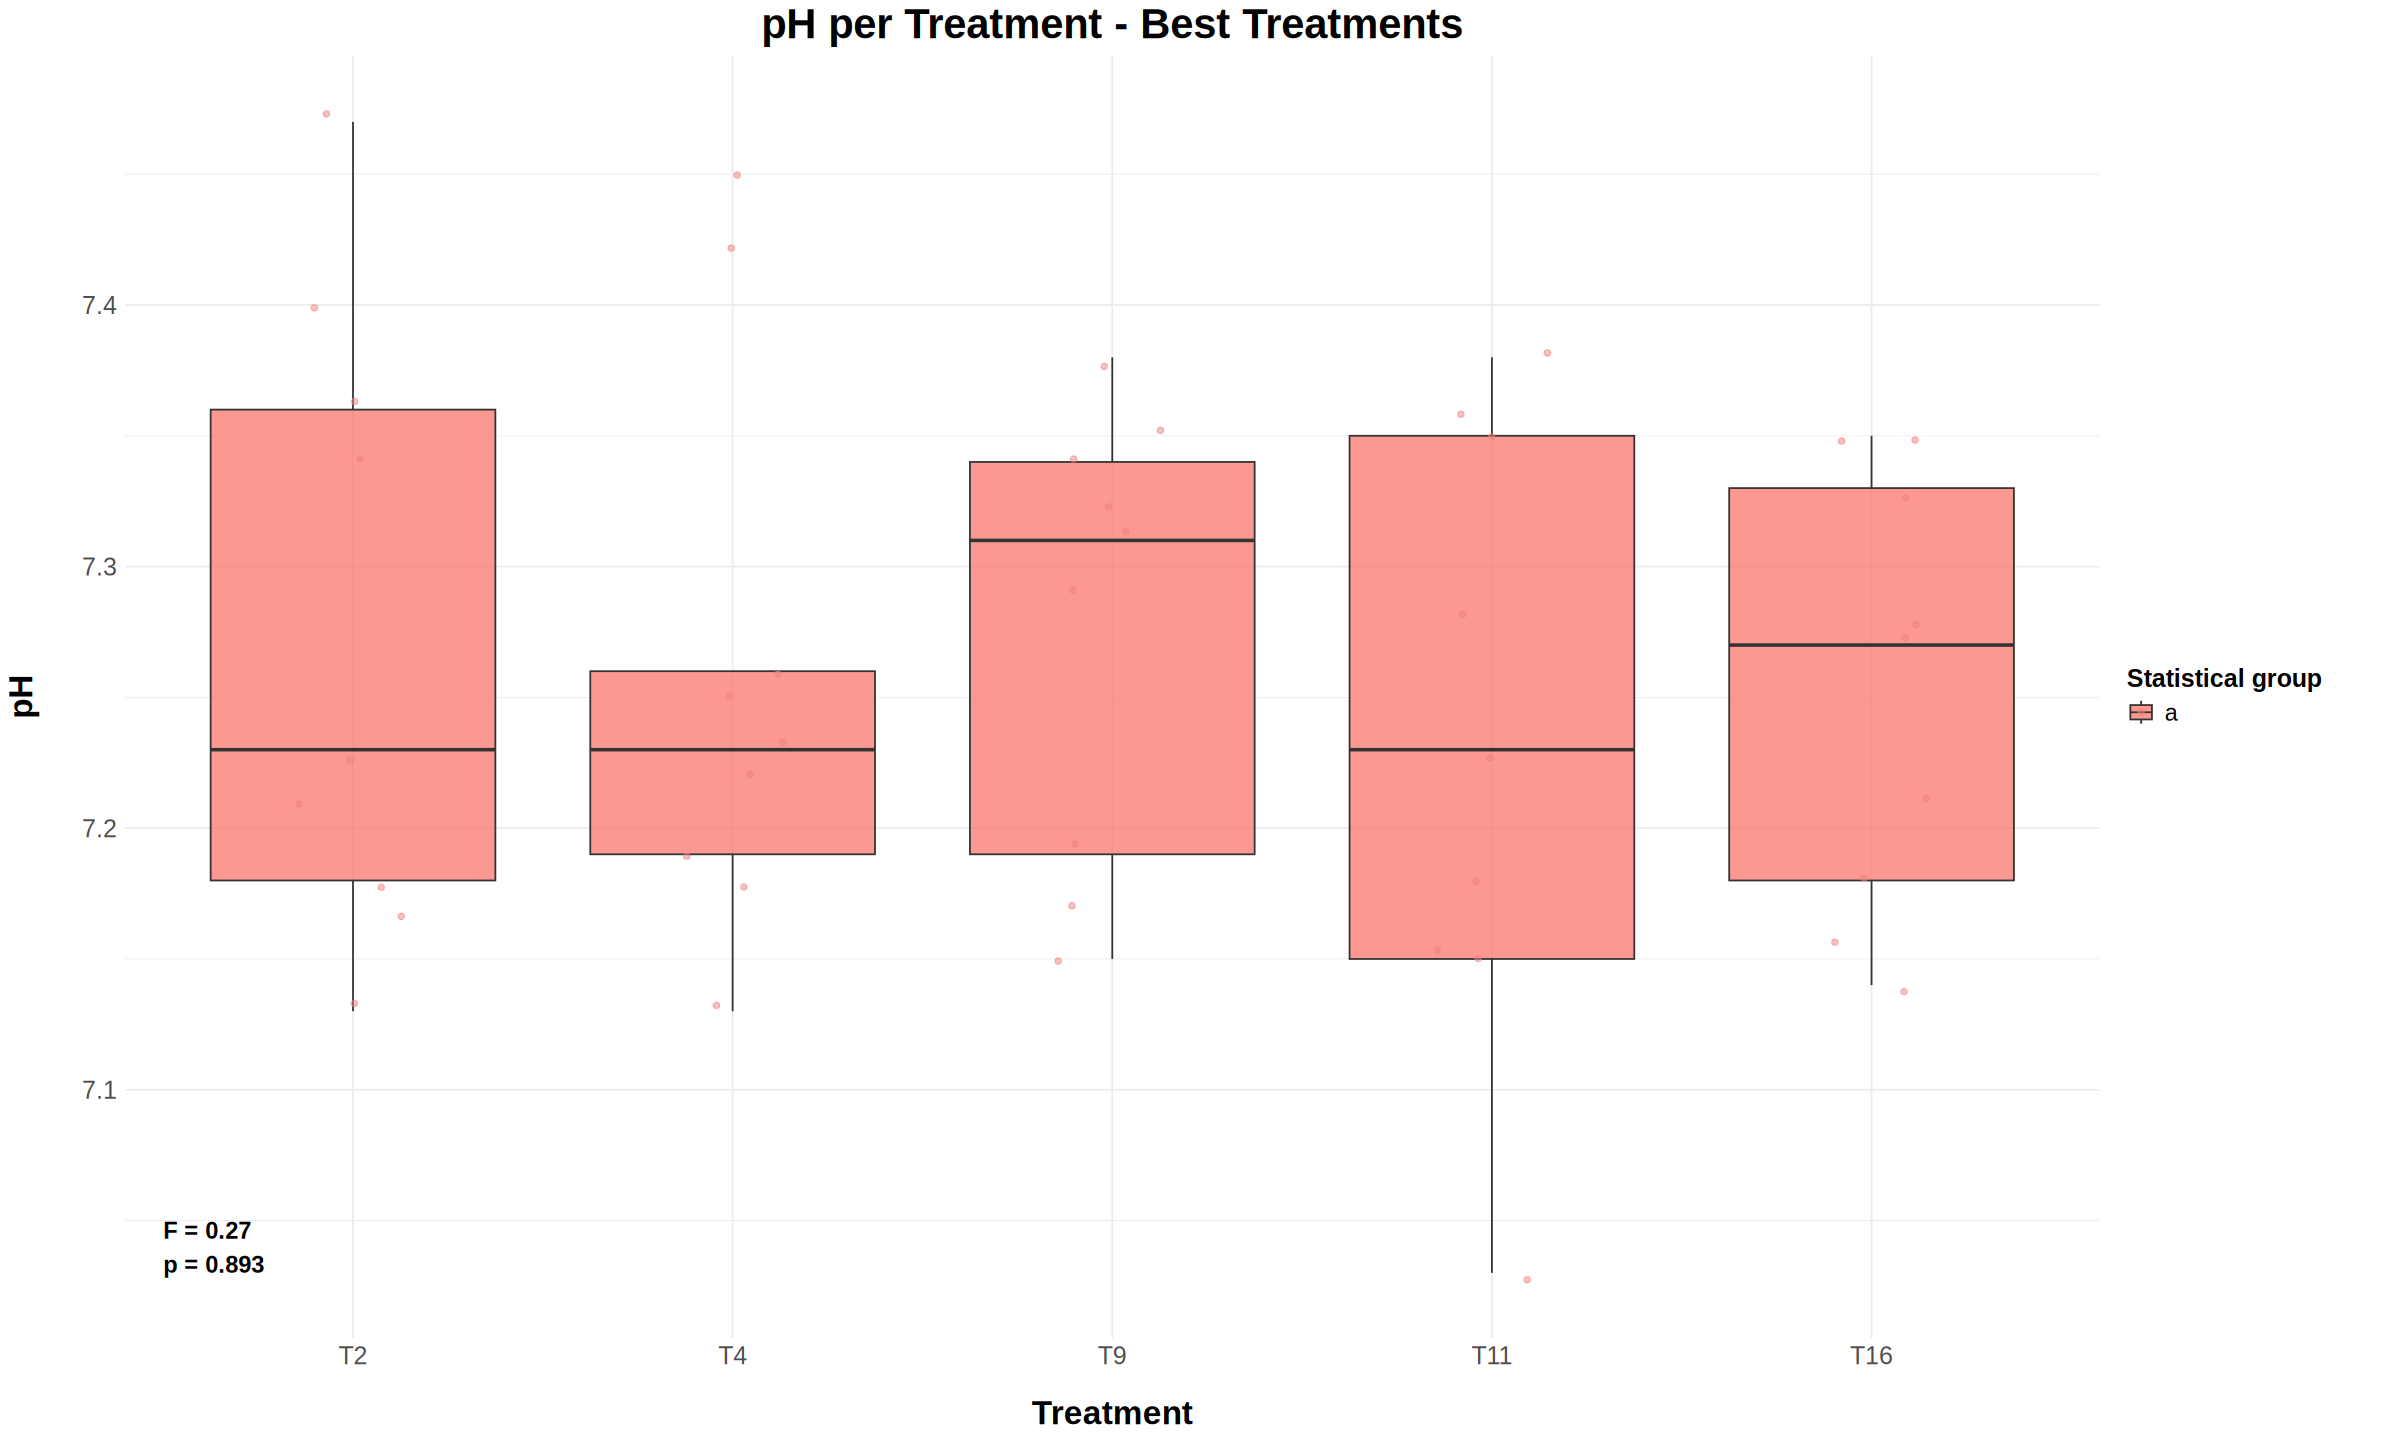

In [104]:
result_best_treatments_pH <- plot_anova_treatment(
  data = best_treatments,
  variable = "pH",
  title = "pH per Treatment - Best Treatments",
  y_label = "pH"
)

## 7.5 Averages

In [107]:
batch_best_treatments <- best_treatments %>% group_by(Treatment) %>%
  summarise(
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
batch_best_treatments

Treatment,TDDM_average,Methane_intensity_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T2,66.82,56.34,121.84,7.28
T4,68.29,51.32,193.50,7.26
T11,68.32,44.63,204.14,7.23
T9,64.02,54.62,233.16,7.28
T16,67.76,43.22,126.81,7.25


# 8.0 All treatments comparison

In [114]:
df2 <- df %>% filter(!Treatment %in% c("T34", "T35", "T36"))

## 8.1 TDDM %


ANALYSIS: TDDM (%) per Treatment - Best Treatments 

--- ANOVA ---
Analysis of Variance Table

Response: TDDM_percentage
           Df Sum Sq Mean Sq F value    Pr(>F)    
Treatment  33 2384.3  72.252  5.9152 < 2.2e-16 ***
Residuals 267 3261.3  12.215                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 5.915235

--- P VALUE ---
[1] 1.216981e-17

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.97286, p-value = 1.842e-05


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  TDDM_percentage by Treatment
Bartlett's K-squared = 46.569, df = 33, p-value = 0.05892


--- TUKEY GROUPS ---
   Treatment     mean letter
1         T0 77.90000      a
2        T20 69.98889      b
3        T24 69.80000      b
4        T26 69.65556      b
5        T19 69.27778      b
6        T25 69.12222      b
7        T22 68.96667      b
8        T33 68.87778      b
9        T13 68.71111      b
10 

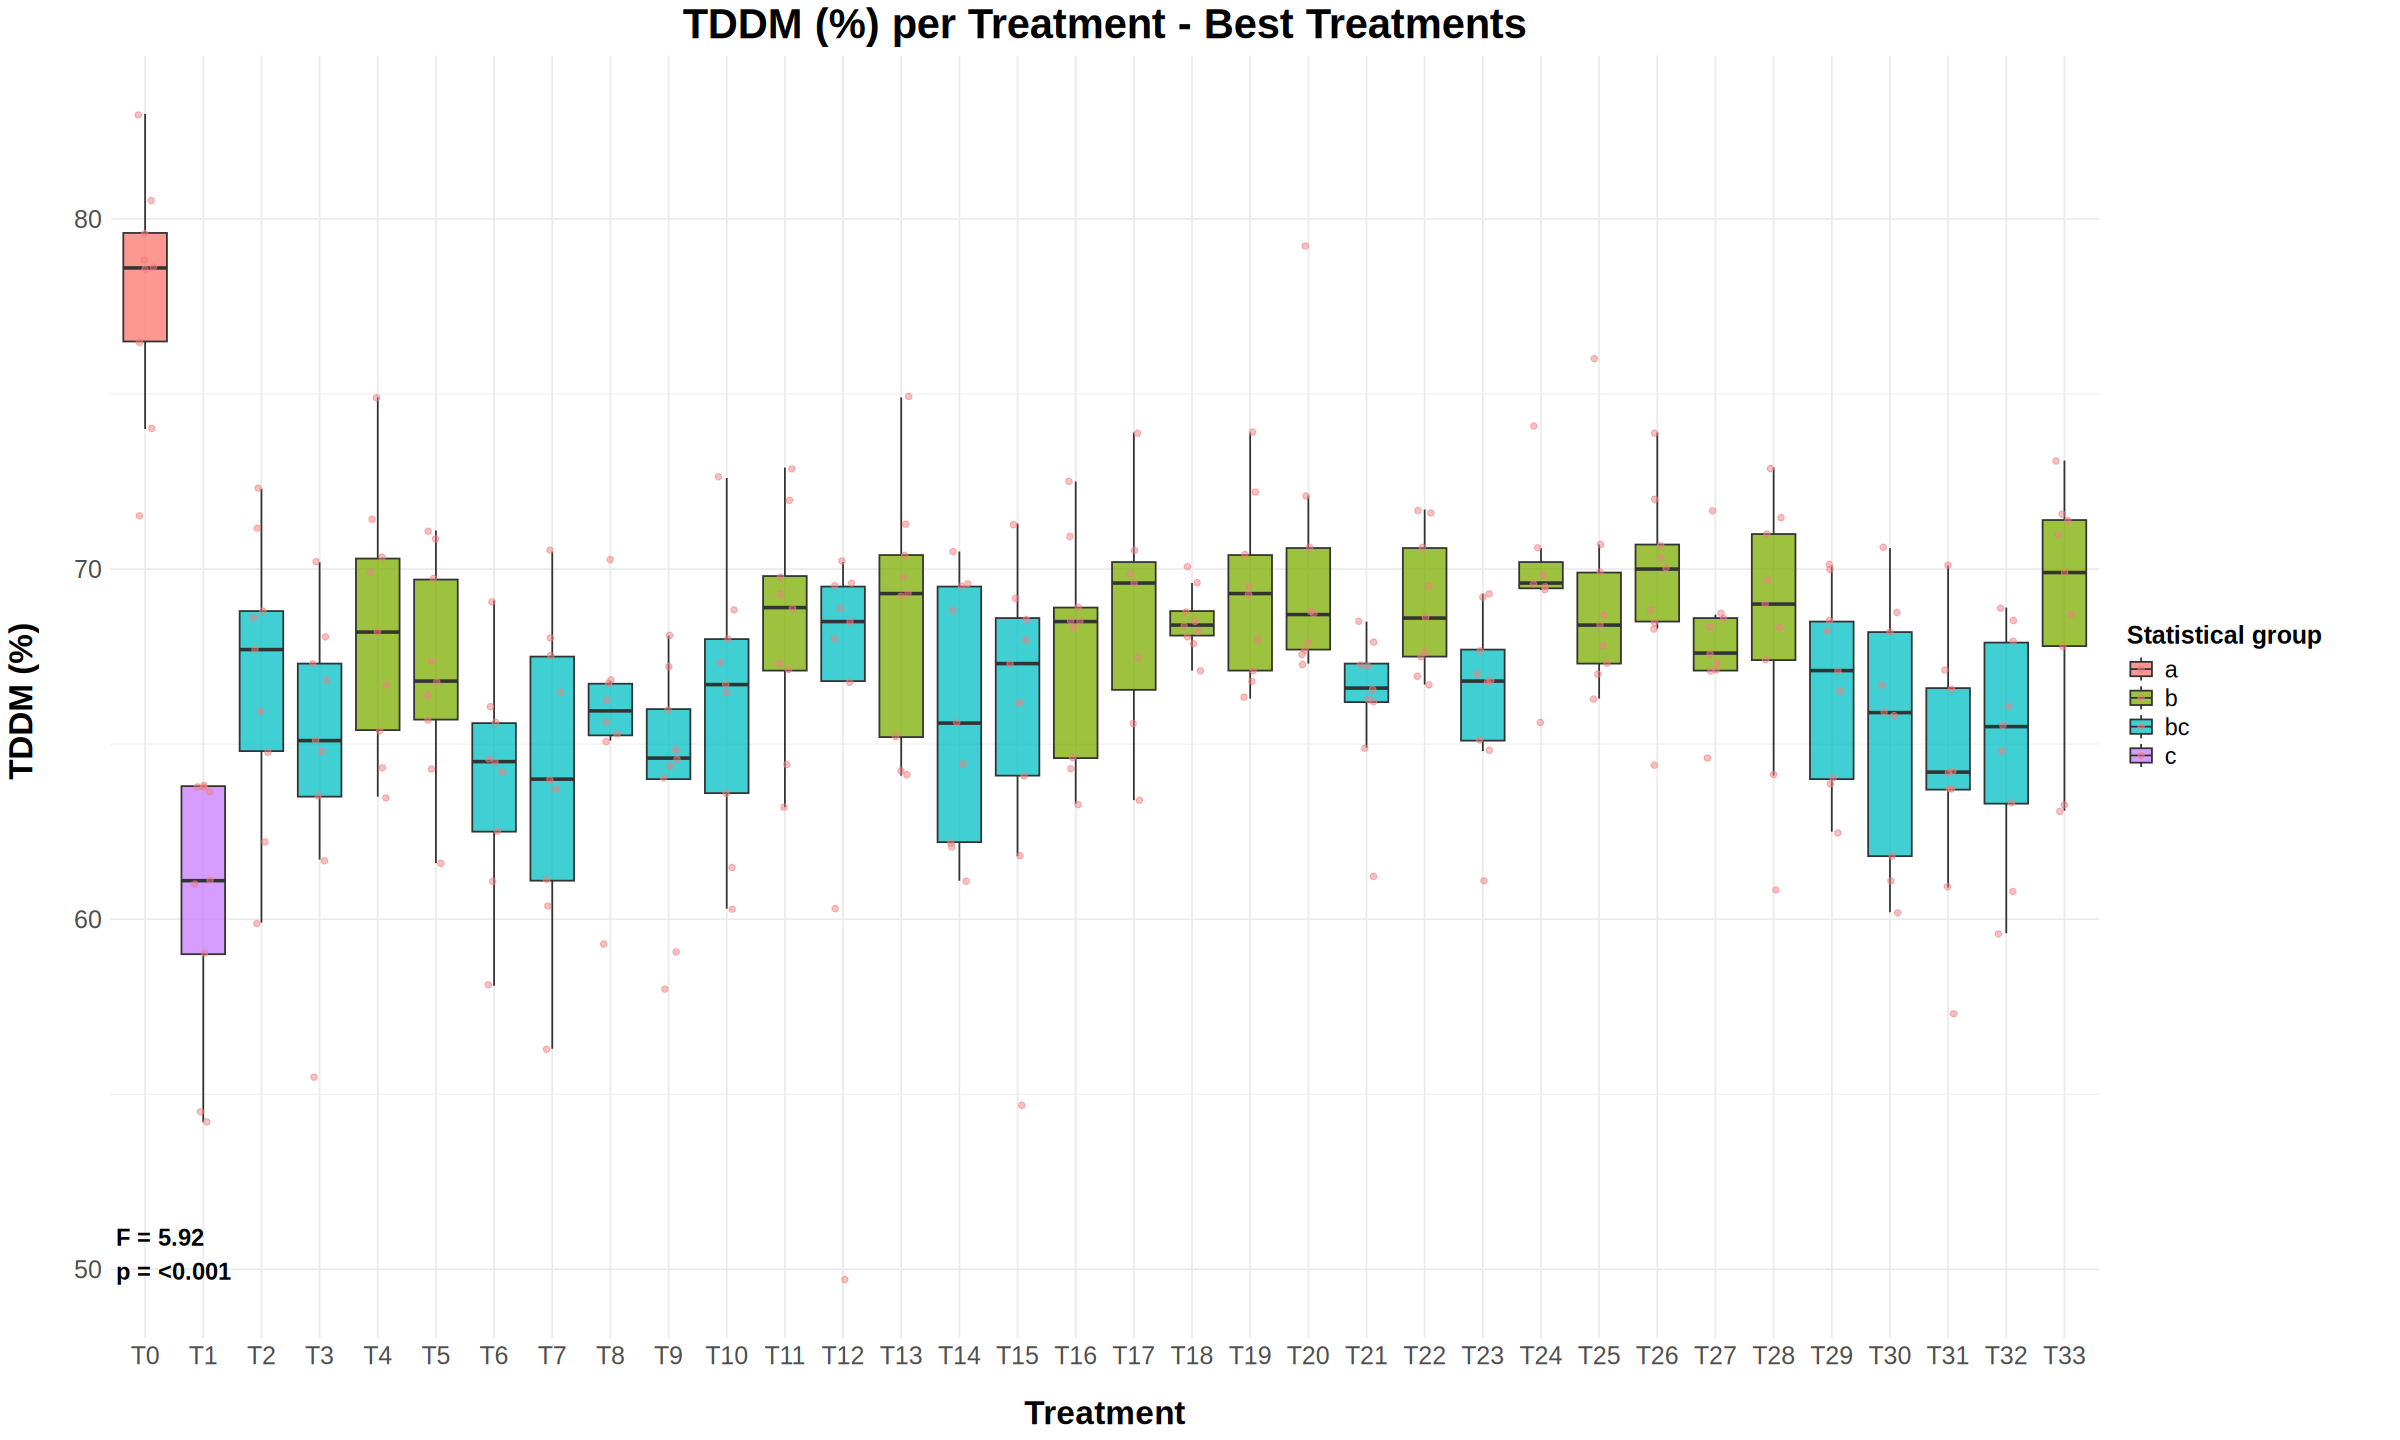

In [115]:
result_all_tddm <- plot_anova_treatment(
  data = df2,
  variable = "TDDM_percentage",
  title = "TDDM (%) per Treatment - Best Treatments",
  y_label = "TDDM (%) "
)

## 8.2 Methane intensity


ANALYSIS: Methane Intensity per Treatment - Best Treatments 

--- ANOVA ---
Analysis of Variance Table

Response: CH4_ml_g_DMD_24h
           Df  Sum Sq Mean Sq F value    Pr(>F)    
Treatment  33 15116.3  458.07  14.277 < 2.2e-16 ***
Residuals 267  8566.3   32.08                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 14.27747

--- P VALUE ---
[1] 4.769581e-42

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.99066, p-value = 0.05225


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  CH4_ml_g_DMD_24h by Treatment
Bartlett's K-squared = 74.335, df = 33, p-value = 5.043e-05


--- TUKEY GROUPS ---
   Treatment     mean letter
1         T6 58.66667      a
2         T7 57.76667     ab
3         T0 57.35556    abc
4         T3 56.65556   abcd
5         T2 56.34444   abcd
6        T12 56.24444   abcd
7        T15 55.58889   abcd
8         T5 55.33333   abcd
9         T8 54.86

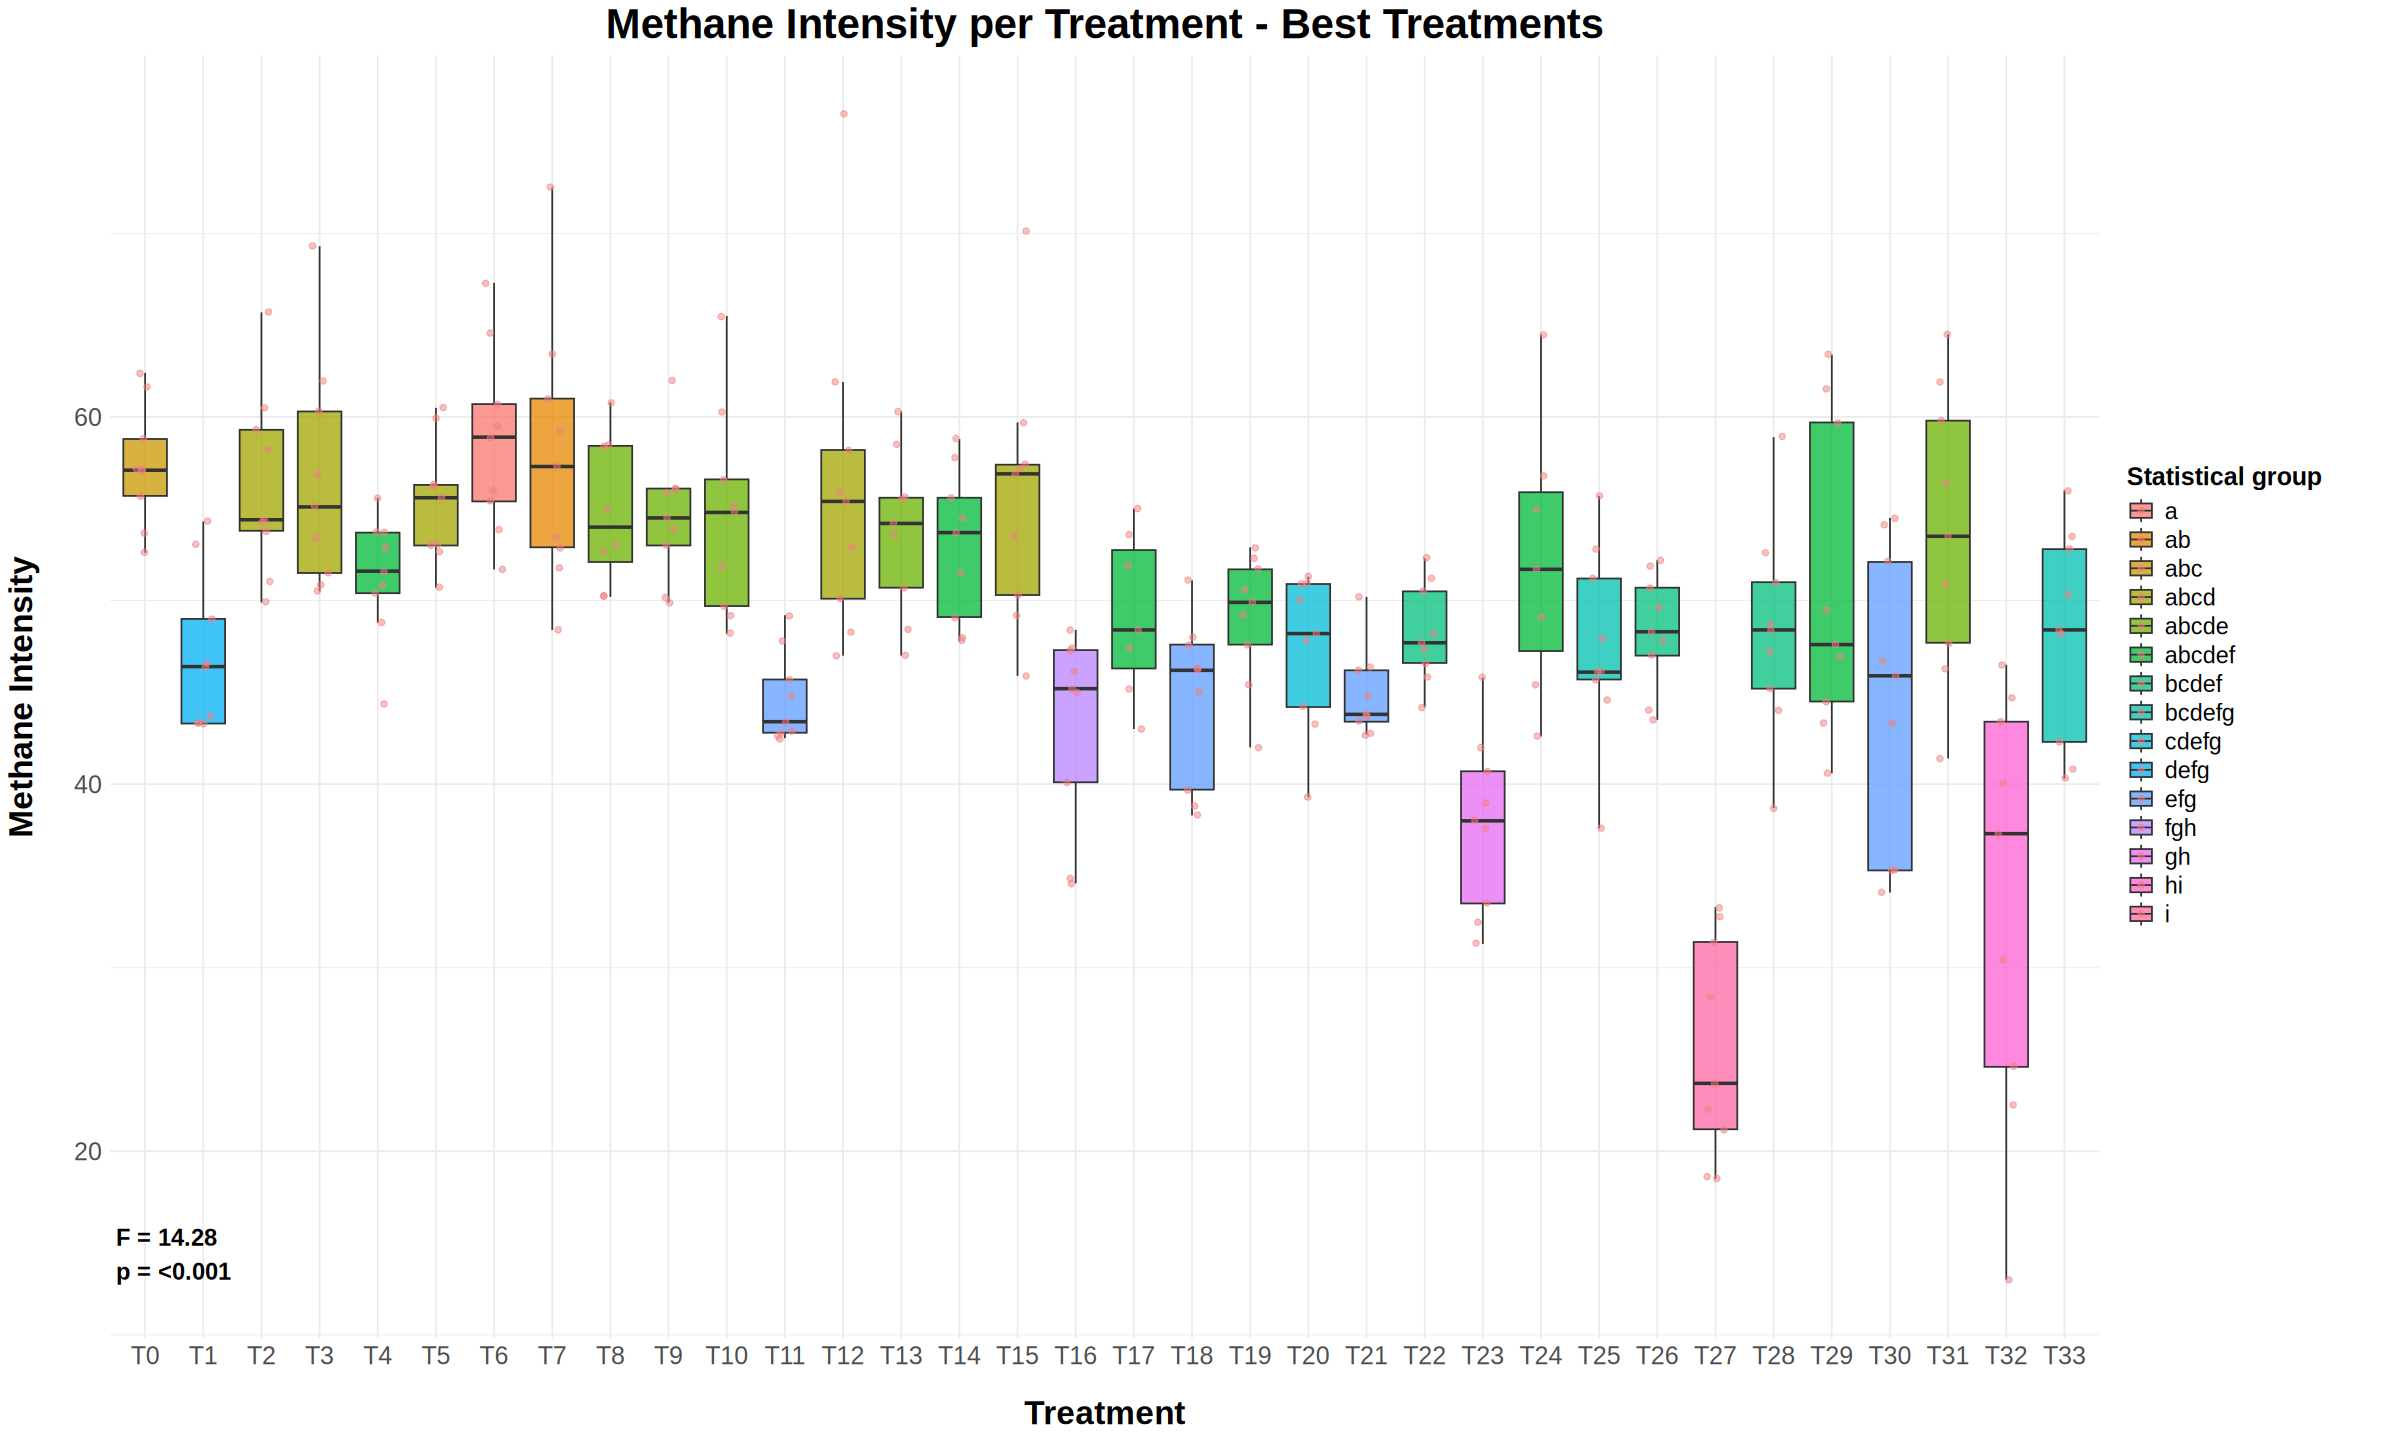

In [116]:
result_all_methane_intensity <- plot_anova_treatment(
  data = df2,
  variable = "CH4_ml_g_DMD_24h",
  title = "Methane Intensity per Treatment - Best Treatments",
  y_label = "Methane Intensity"
)

## 8.3 Ammonium


ANALYSIS: Ammonium per Treatment - Best Treatments 

--- ANOVA ---
Analysis of Variance Table

Response: Amonio_corregido_ppm
           Df  Sum Sq Mean Sq F value    Pr(>F)    
Treatment  33 1097673   33263  2.4778 3.663e-05 ***
Residuals 270 3624556   13424                      
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 2.477811

--- P VALUE ---
[1] 3.662855e-05

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.97618, p-value = 6.088e-05


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  Amonio_corregido_ppm by Treatment
Bartlett's K-squared = 73.621, df = 33, p-value = 6.243e-05


--- TUKEY GROUPS ---
   Treatment      mean letter
1         T3 288.48611      a
2         T9 233.16389     ab
3        T12 209.08611    abc
4        T11 204.14167    abc
5         T4 193.49722    abc
6         T8 190.84167    abc
7        T32 189.50833    abc
8        T13 189.37500    abc
9       

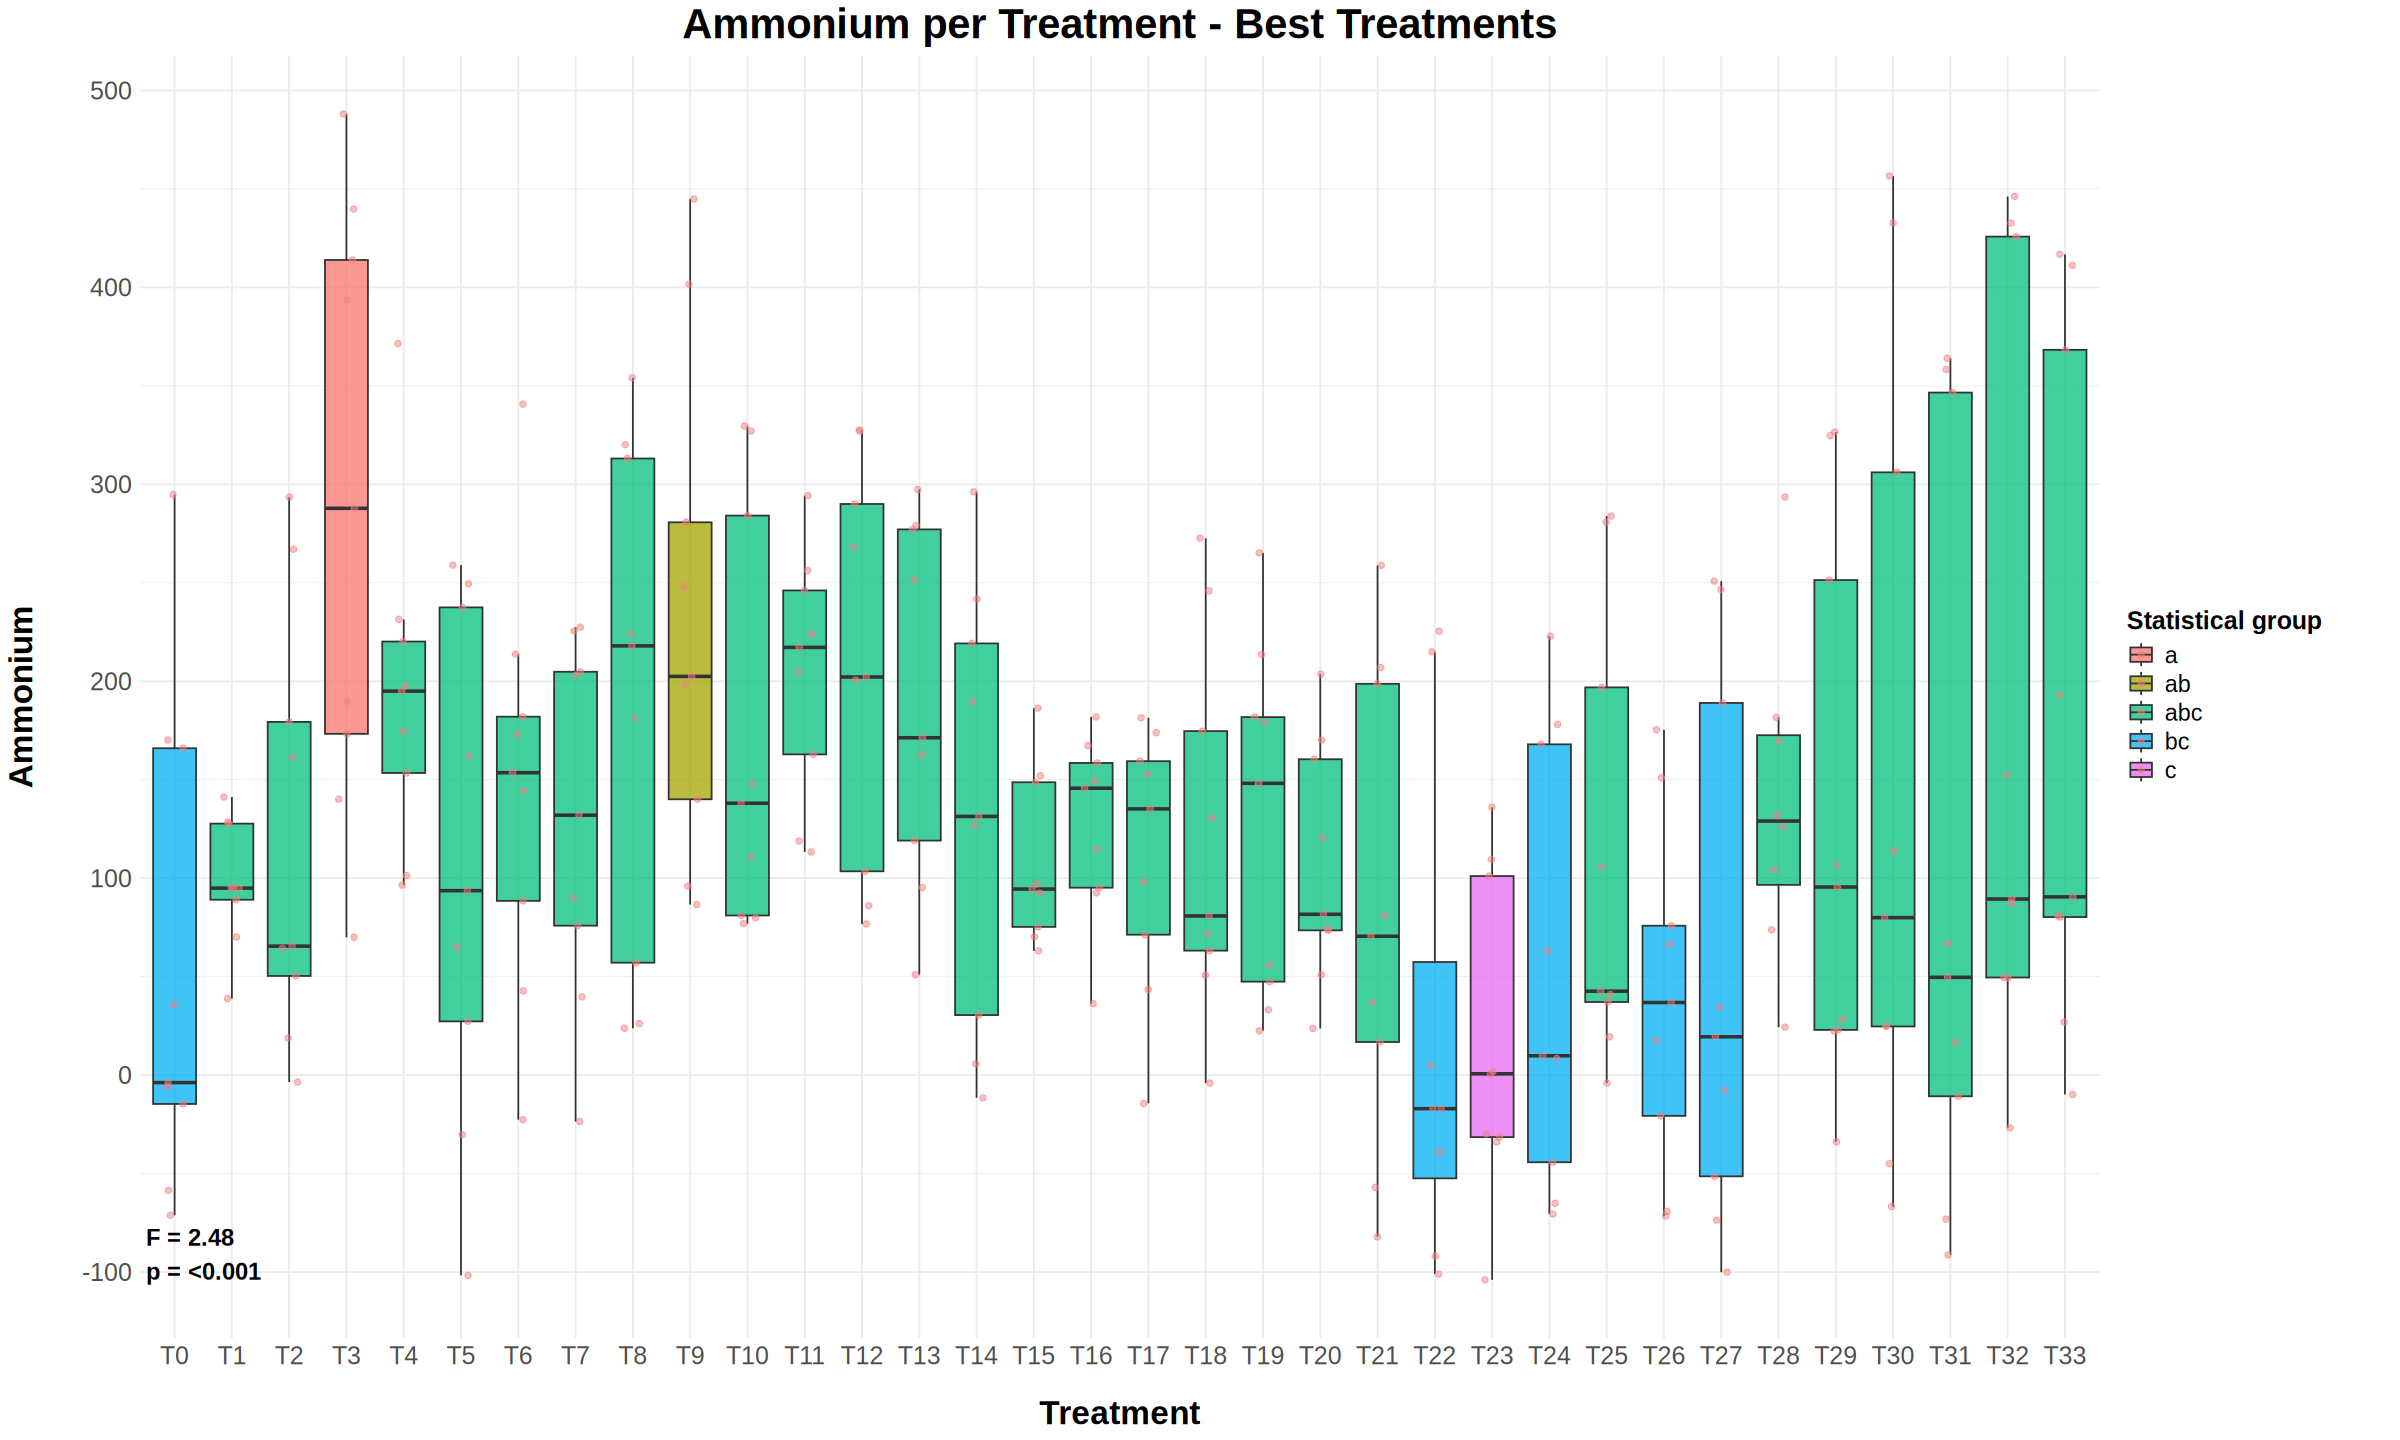

In [117]:
result_all_ammonium <- plot_anova_treatment(
  data = df2,
  variable = "Amonio_corregido_ppm",
  title = "Ammonium per Treatment - Best Treatments",
  y_label = "Ammonium"
)

## 8.4 pH


ANALYSIS: pH per Treatment - Best Treatments 

--- ANOVA ---
Analysis of Variance Table

Response: pH
           Df Sum Sq  Mean Sq F value  Pr(>F)  
Treatment  33 0.6731 0.020396  1.4055 0.07643 .
Residuals 272 3.9471 0.014511                  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

--- F VALUE ---
[1] 1.405531

--- P VALUE ---
[1] 0.07643045

--- SHAPIRO-WILK TEST ---

	Shapiro-Wilk normality test

data:  residuals(model)
W = 0.99361, p-value = 0.2223


--- BARTLETT TEST ---

	Bartlett test of homogeneity of variances

data:  pH by Treatment
Bartlett's K-squared = 53.447, df = 33, p-value = 0.01362


--- TUKEY GROUPS ---
   Treatment     mean letter
1         T1 7.440000      a
2        T25 7.371111     ab
3        T33 7.340000     ab
4        T27 7.328889     ab
5        T32 7.324444     ab
6        T29 7.323333     ab
7        T24 7.321111     ab
8        T22 7.316667     ab
9        T26 7.295556     ab
10       T28 7.295556     ab
11        T7 7.29444

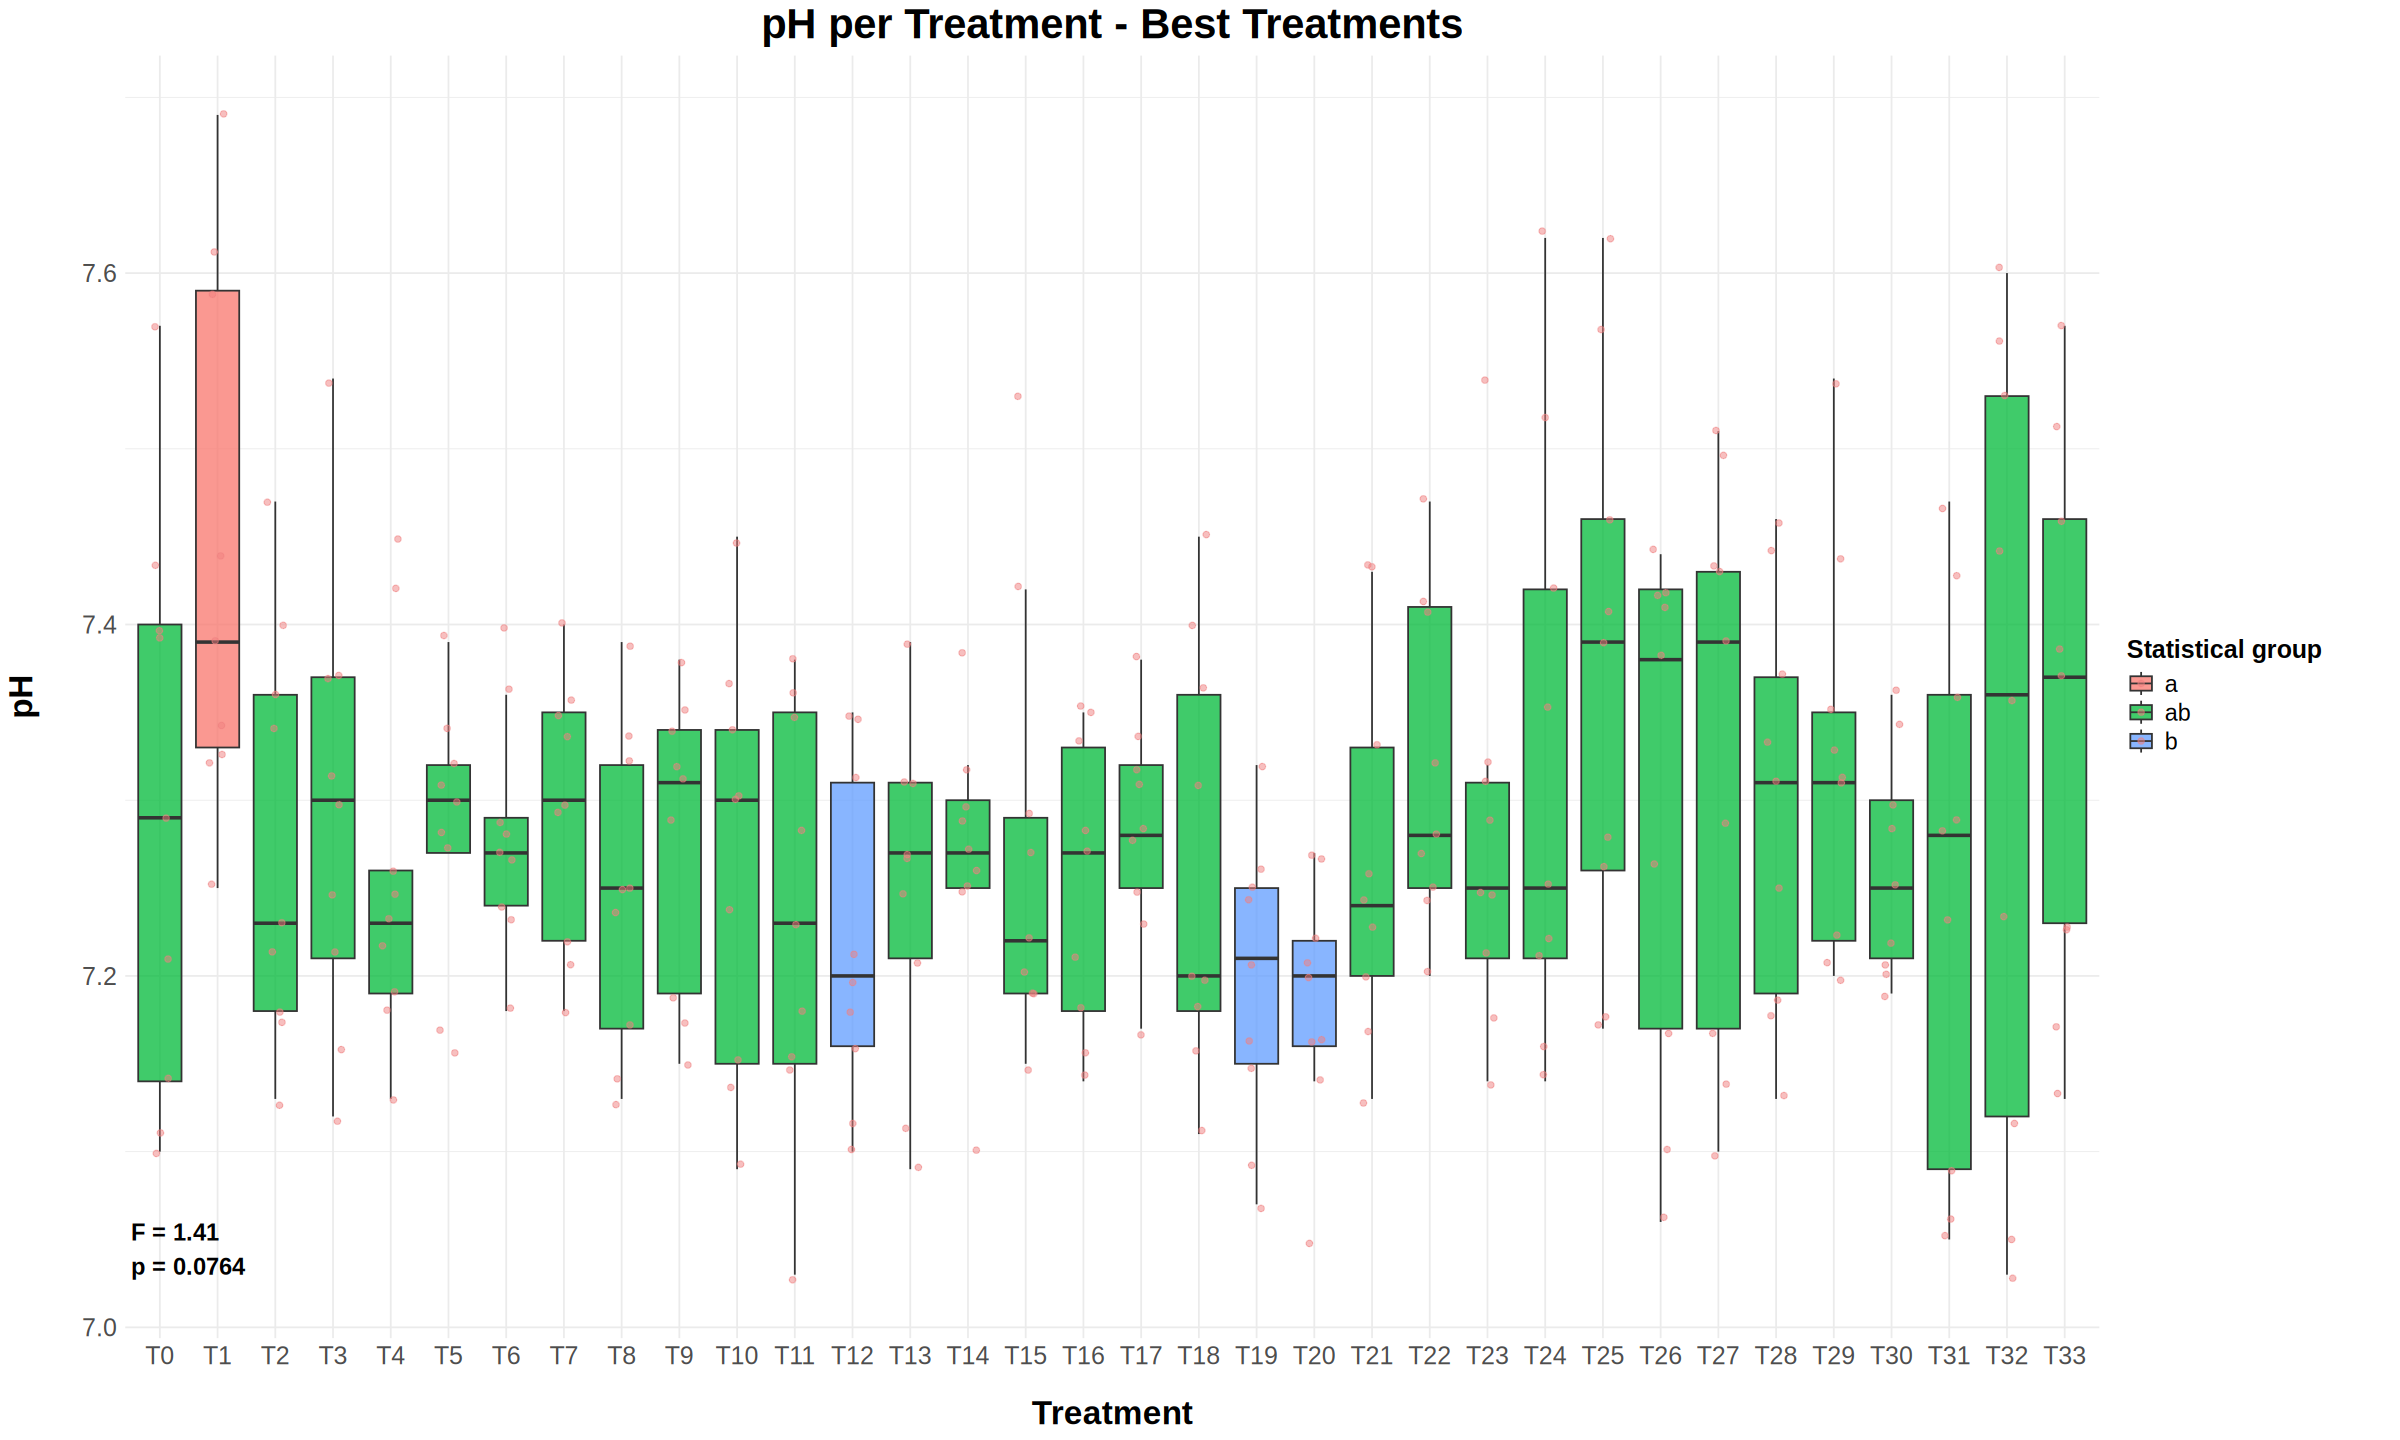

In [118]:
result_all_pH <- plot_anova_treatment(
  data = df2,
  variable = "pH",
  title = "pH per Treatment - Best Treatments",
  y_label = "pH"
)

## 8.5 Averages

In [119]:
all_treatments <- df2 %>% group_by(Treatment) %>%
  summarise(
    TDDM_average = round(mean(TDDM_percentage, na.rm = TRUE),2),
    Methane_intensity_average = round(mean(CH4_ml_g_DMD_24h, na.rm = TRUE),2),
    Ammonium_average = round(mean(Amonio_corregido_ppm, na.rm = TRUE),2),
    pH_average = round(mean(pH, na.rm = TRUE),2)
  )
all_treatments

Treatment,TDDM_average,Methane_intensity_average,Ammonium_average,pH_average
<fct>,<dbl>,<dbl>,<dbl>,<dbl>
T0,77.90,57.36,56.98,7.29
T1,60.53,47.00,97.86,7.44
T2,66.82,56.34,121.84,7.28
T3,64.78,56.66,288.49,7.29
T4,68.29,51.32,193.50,7.26
T5,67.10,55.33,106.86,7.28
T6,63.98,58.67,146.22,7.28
T7,64.22,57.77,130.52,7.29
T8,65.67,54.86,190.84,7.25
